=== Original instance summary ===


,num_times,feature_dim,num_actions_min,num_actions_max,num_actions_mean,reward_mode,oracle_reward_mean,oracle_reward_std,linearized_reward_mean,linearized_reward_std,misspec_mae,misspec_rmse,misspec_abs_p95,misspec_abs_p99,misspec_abs_max
0,7473,25,129,129,129.0,linearized,0.489381,0.180569,0.488149,0.178997,0.021245,0.032377,0.065718,0.123106,0.31604


=== 5s cyclic instance summary ===


,num_times,feature_dim,num_actions_min,num_actions_max,num_actions_mean,reward_mode,oracle_reward_mean,oracle_reward_std,linearized_reward_mean,linearized_reward_std,misspec_mae,misspec_rmse,misspec_abs_p95,misspec_abs_p99,misspec_abs_max
0,500000,25,129,129,129.0,linearized,0.492812,0.180846,0.491592,0.179292,0.021608,0.032836,0.066794,0.124736,0.31604


=== K=20 finite-state mixing proxy ===


...

=== Algorithm 1 delay candidates ===


,c_tau,tau,tau_over_T
0,0.10,7,0.000014
1,0.25,18,0.000036
2,0.50,35,0.000070
3,0.75,52,0.000104
4,1.00,69,0.000138


=== Offline baseline sanity check ===


,method,avg_chosen_reward,avg_oracle_reward,avg_regret,avg_norm_regret,mean_chosen_rank,median_chosen_rank,cumulative_regret,top1_rate,top3_rate,top5_rate
0,oracle,0.739230,0.73923,0.000000,0.000000,1.000000,1.0,0.000000,1.00000,1.000000,1.00000
1,linearized_greedy,0.739230,0.73923,0.000000,0.000000,1.000000,1.0,0.000000,1.00000,1.000000,1.00000
2,random_mean_20,0.491647,0.73923,0.247583,0.429482,64.981572,65.0,123791.430565,0.00775,0.023283,0.03883


=== Created objects ===
original_instance.num_times = 7473
cyclic_instance_5s.num_times = 500000
X[0].shape = (129, 25)
X_base[0].shape = (129, 24)
theta_star.shape = (25,)
reward_mode = linearized
beta_hat = 0.807548
saved config: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\cyclic_replay_5s_config_with_beta.json
saved replay indices: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\cyclic_replay_5s_indices.npy
saved state labels: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\cyclic_replay_5s_K20_state_labels_one_period.npy


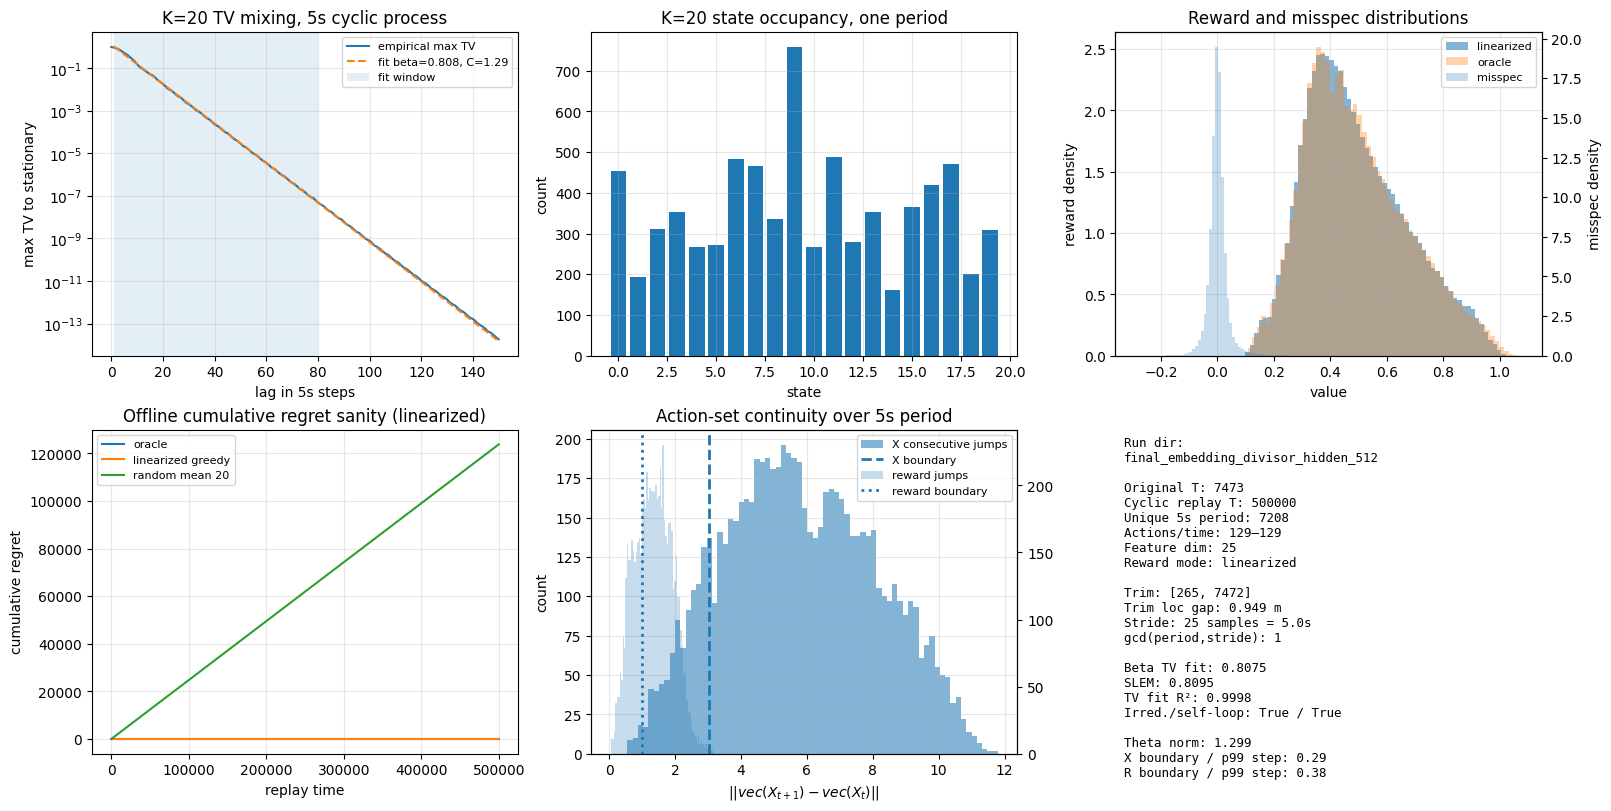

In [2]:
# ============================================================
# Vehicle Bandit Instance: original + 5s cyclic replay + beta diagnostics
# ============================================================

import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# ============================================================
# 0. Repo paths / imports
# ============================================================

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
SCRIPTS_DIR = REPO_ROOT / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

from bandit_instance import (
    BanditInstance,
    build_bandit_instance_from_run,
    summarize_instance,
)

from bandit_eval import (
    oracle_action_indices,
    random_action_indices,
    greedy_action_indices_from_reward_source,
    evaluate_action_indices,
    cumulative_sum,
)


# ============================================================
# 1. Config
# ============================================================

RUN_DIR = REPO_ROOT / "results" / "final_embedding_divisor_hidden_512"

# For the exact linear bandit simulations.
REWARD_MODE = "linearized"

# Native processing was 200ms; stride 25 gives 5 seconds.
SAMPLE_MS = 200
TARGET_SECONDS = 5.0
STRIDE = int(round(TARGET_SECONDS * 1000 / SAMPLE_MS))

# Long replay horizon for OFUL/LinUCB/Algorithm 1 experiments.
T_REPLAY = 500_000

# Saved from the trimming diagnostic.
TRIM_PATH = REPO_ROOT / "results" / "cyclic_replay_trim_points.json"

# K=20 finite-state proxy for beta.
K_STATES = 20
PCA_DIM = 10
RANDOM_STATE = 0
MAX_TV_LAG = 150
TV_FIT_MIN_LAG = 1
TV_FIT_MAX_LAG = 80
SMOOTHING = 0.0

RANDOM_BASELINE_TRIALS = 20
RANDOM_BASELINE_SEED0 = 123


# ============================================================
# 2. Build original frozen-embedding BanditInstance
# ============================================================

original_instance = build_bandit_instance_from_run(
    RUN_DIR,
    reward_mode=REWARD_MODE,
    include_intercept=True,
    sort_rows=True,
)

original_summary = summarize_instance(original_instance)


# ============================================================
# 3. Build 5-second cyclic replay indices
# ============================================================

with open(TRIM_PATH, "r") as f:
    trim_config = json.load(f)

cycle_start_idx = int(trim_config["cycle_start_idx"])
cycle_end_idx = int(trim_config["cycle_end_idx"])

base_cycle_indices = np.arange(cycle_start_idx, cycle_end_idx + 1, dtype=int)
base_cycle_len = int(len(base_cycle_indices))

g = int(np.gcd(base_cycle_len, STRIDE))
period_len = int(base_cycle_len // g)

positions = (np.arange(period_len, dtype=int) * STRIDE) % base_cycle_len
stride_cycle_indices = base_cycle_indices[positions]

replay_indices = stride_cycle_indices[np.arange(T_REPLAY, dtype=int) % period_len]

effective_seconds = STRIDE * SAMPLE_MS / 1000.0


# ============================================================
# 4. Repo-compatible cyclic BanditInstance
# ============================================================

def _take(xs, idx):
    return [xs[int(i)] for i in idx]


def make_cyclic_bandit_instance_like_repo(
    instance,
    replay_indices,
    reward_mode="linearized",
    meta_extra=None,
):
    idx = np.asarray(replay_indices, dtype=int)

    X_by_t = _take(instance.X_by_t, idx)
    X_base_by_t = _take(instance.X_base_by_t, idx)

    oracle_rewards_by_t = _take(instance.oracle_rewards_by_t, idx)
    linearized_rewards_by_t = _take(instance.linearized_rewards_by_t, idx)

    if reward_mode == "oracle":
        rewards_by_t = oracle_rewards_by_t
    elif reward_mode == "linearized":
        rewards_by_t = linearized_rewards_by_t
    else:
        raise ValueError("reward_mode must be 'oracle' or 'linearized'.")

    misspec_by_t = _take(instance.misspec_by_t, idx)
    subset_strs_by_t = _take(instance.subset_strs_by_t, idx)
    subsets_by_t = _take(instance.subsets_by_t, idx)

    num_actions_per_time = np.asarray([X.shape[0] for X in X_by_t], dtype=int)
    feature_dim = int(X_by_t[0].shape[1]) if len(X_by_t) else 0

    meta = dict(getattr(instance, "meta", {}) or {})
    if meta_extra is not None:
        meta.update(meta_extra)

    return BanditInstance(
        times=np.arange(len(idx)),
        X_by_t=X_by_t,
        X_base_by_t=X_base_by_t,
        oracle_rewards_by_t=oracle_rewards_by_t,
        linearized_rewards_by_t=linearized_rewards_by_t,
        rewards_by_t=rewards_by_t,
        misspec_by_t=misspec_by_t,
        subset_strs_by_t=subset_strs_by_t,
        subsets_by_t=subsets_by_t,
        theta_star=np.asarray(instance.theta_star, dtype=float),
        reward_mode=reward_mode,
        feature_dim=feature_dim,
        num_times=len(idx),
        num_actions_per_time=num_actions_per_time,
        meta=meta,
        run_dir=getattr(instance, "run_dir", None),
    )


# ============================================================
# 5. Beta estimation helpers for KMeans(PCA(vec(X_t)))
# ============================================================

def flatten_X_by_t(X_by_t, drop_intercept=True):
    rows = []
    for X in X_by_t:
        X = np.asarray(X, dtype=float)
        if drop_intercept and X.shape[1] > 1 and np.allclose(X[:, 0], 1.0):
            X = X[:, 1:]
        rows.append(X.reshape(-1))
    return np.vstack(rows)


def estimate_transition_matrix(labels, K, circular=True, smoothing=0.0):
    labels = np.asarray(labels, dtype=int)
    counts = np.full((K, K), smoothing, dtype=float)

    for a, b in zip(labels[:-1], labels[1:]):
        counts[a, b] += 1.0

    if circular and len(labels) > 1:
        counts[labels[-1], labels[0]] += 1.0

    row_sums = counts.sum(axis=1, keepdims=True)
    P = np.divide(
        counts,
        row_sums,
        out=np.ones_like(counts) / K,
        where=row_sums > 0,
    )
    return P, counts


def stationary_distribution(P):
    vals, vecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(vals - 1.0))
    pi = np.real(vecs[:, idx])

    if pi.sum() < 0:
        pi = -pi

    pi = np.maximum(pi, 0.0)

    if pi.sum() <= 1e-12:
        K = P.shape[0]
        A = np.vstack([P.T - np.eye(K), np.ones(K)])
        b = np.concatenate([np.zeros(K), [1.0]])
        pi = np.linalg.lstsq(A, b, rcond=None)[0]
        pi = np.maximum(pi, 0.0)

    return pi / pi.sum()


def tv_distance(p, q):
    return 0.5 * np.sum(np.abs(p - q))


def tv_mixing_curve(P, max_lag=150):
    K = P.shape[0]
    pi = stationary_distribution(P)
    P_power = np.eye(K)

    tvs = []
    for lag in range(max_lag + 1):
        tvs.append(max(tv_distance(P_power[i], pi) for i in range(K)))
        P_power = P_power @ P

    return np.asarray(tvs), pi


def fit_beta_from_tv_curve(tvs, min_lag=1, max_lag=80, min_tv=1e-10):
    lags = np.arange(len(tvs))
    mask = (
        (lags >= min_lag)
        & (lags <= max_lag)
        & np.isfinite(tvs)
        & (tvs > min_tv)
        & (tvs < 0.999999)
    )

    if mask.sum() < 5:
        return np.nan, np.nan, np.nan, None

    x = lags[mask]
    y = np.log(tvs[mask])

    slope, intercept = np.polyfit(x, y, 1)
    beta = float(np.exp(slope))
    Cmix = float(np.exp(intercept))

    yhat = slope * x + intercept
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan

    return beta, Cmix, r2, (x, y, yhat)


def slem(P):
    vals = np.linalg.eigvals(P)
    mods = np.sort(np.abs(vals))[::-1]
    return float(mods[1]) if len(mods) > 1 else 0.0


def graph_reachable(adj, start):
    K = adj.shape[0]
    seen = np.zeros(K, dtype=bool)
    stack = [start]
    seen[start] = True

    while stack:
        u = stack.pop()
        for v in np.where(adj[u])[0]:
            if not seen[v]:
                seen[v] = True
                stack.append(v)

    return seen


def is_irreducible(P, tol=1e-12):
    adj = P > tol
    return all(graph_reachable(adj, s).all() for s in range(P.shape[0]))


def has_self_loop(P, tol=1e-12):
    return bool(np.any(np.diag(P) > tol))


def estimate_beta_for_X_sequence(
    X_by_t,
    K=20,
    pca_dim=10,
    random_state=0,
    max_tv_lag=150,
    fit_min_lag=1,
    fit_max_lag=80,
    smoothing=0.0,
):
    F = flatten_X_by_t(X_by_t, drop_intercept=True)
    F_std = StandardScaler().fit_transform(F)
    Z = PCA(n_components=pca_dim, random_state=random_state).fit_transform(F_std)

    kmeans = KMeans(n_clusters=K, n_init=20, random_state=random_state)
    labels = kmeans.fit_predict(Z)

    P, counts = estimate_transition_matrix(
        labels,
        K=K,
        circular=True,
        smoothing=smoothing,
    )

    tvs, pi = tv_mixing_curve(P, max_lag=max_tv_lag)
    beta_tv_fit, Cmix_tv_fit, tv_fit_r2, fit_obj = fit_beta_from_tv_curve(
        tvs,
        min_lag=fit_min_lag,
        max_lag=fit_max_lag,
    )

    beta_slem = slem(P)
    sizes = np.bincount(labels, minlength=K)

    lags = np.arange(len(tvs))
    if np.isfinite(beta_tv_fit):
        Cmix_emp_envelope = float(
            np.max(tvs[1:] / np.maximum(beta_tv_fit ** lags[1:], 1e-300))
        )
    else:
        Cmix_emp_envelope = np.nan

    return {
        "F": F,
        "Z": Z,
        "labels": labels,
        "P": P,
        "counts": counts,
        "pi": pi,
        "tvs": tvs,
        "fit_obj": fit_obj,
        "beta_tv_fit": float(beta_tv_fit),
        "beta_slem": float(beta_slem),
        "Cmix_tv_fit": float(Cmix_tv_fit),
        "Cmix_emp_envelope": float(Cmix_emp_envelope),
        "tv_fit_r2": float(tv_fit_r2),
        "irreducible": bool(is_irreducible(P)),
        "has_self_loop": bool(has_self_loop(P)),
        "visited_states": int(len(np.unique(labels))),
        "state_counts": sizes,
    }


# Use one unique modular-stride period for beta, not the 50k repeated stream.
X_period = _take(original_instance.X_by_t, stride_cycle_indices)

beta_artifacts = estimate_beta_for_X_sequence(
    X_period,
    K=K_STATES,
    pca_dim=PCA_DIM,
    random_state=RANDOM_STATE,
    max_tv_lag=MAX_TV_LAG,
    fit_min_lag=TV_FIT_MIN_LAG,
    fit_max_lag=TV_FIT_MAX_LAG,
    smoothing=SMOOTHING,
)

beta_hat = beta_artifacts["beta_tv_fit"]
beta_slem = beta_artifacts["beta_slem"]
Cmix_hat = beta_artifacts["Cmix_tv_fit"]

delay_df = pd.DataFrame([
    {
        "c_tau": c_tau,
        "tau": int(np.ceil(c_tau * np.log(T_REPLAY) / max(1.0 - beta_hat, 1e-12))),
    }
    for c_tau in [0.1, 0.25, 0.5, 0.75, 1.0]
])
delay_df["tau_over_T"] = delay_df["tau"] / T_REPLAY


# ============================================================
# 6. Create cyclic instance with beta metadata
# ============================================================

meta_extra = {
    "cyclic_replay": True,
    "replay_type": "modular_circular_stride",
    "sample_ms": SAMPLE_MS,
    "target_seconds": TARGET_SECONDS,
    "stride": STRIDE,
    "effective_seconds_per_bandit_step": effective_seconds,
    "cycle_start_idx": cycle_start_idx,
    "cycle_end_idx": cycle_end_idx,
    "base_cycle_len": base_cycle_len,
    "gcd_base_cycle_len_stride": g,
    "period_len": period_len,
    "T_replay": T_REPLAY,
    "beta_estimation": {
        "state_definition": "KMeans(PCA(vec(X_t))) on one unique modular-stride period",
        "K_states": K_STATES,
        "pca_dim": PCA_DIM,
        "beta_hat_used": beta_hat,
        "beta_tv_fit": beta_hat,
        "beta_slem": beta_slem,
        "Cmix_tv_fit": Cmix_hat,
        "Cmix_emp_envelope": beta_artifacts["Cmix_emp_envelope"],
        "tv_fit_r2": beta_artifacts["tv_fit_r2"],
        "irreducible": beta_artifacts["irreducible"],
        "has_self_loop": beta_artifacts["has_self_loop"],
        "visited_states": beta_artifacts["visited_states"],
        "state_counts_min": int(beta_artifacts["state_counts"].min()),
        "state_counts_median": float(np.median(beta_artifacts["state_counts"])),
        "state_counts_max": int(beta_artifacts["state_counts"].max()),
    },
    "algorithm1_delay_candidates": delay_df.to_dict(orient="records"),
}

cyclic_instance_5s = make_cyclic_bandit_instance_like_repo(
    instance=original_instance,
    replay_indices=replay_indices,
    reward_mode=REWARD_MODE,
    meta_extra=meta_extra,
)

instance = cyclic_instance_5s
instance_to_use = cyclic_instance_5s


# ============================================================
# 7. Quick offline baseline sanity checks
# ============================================================

oracle_actions = oracle_action_indices(instance, reward_source=REWARD_MODE)
oracle_eval = evaluate_action_indices(
    instance,
    oracle_actions,
    evaluation_source=REWARD_MODE,
    realized_source=REWARD_MODE,
    ks=(1, 3, 5),
)

linearized_greedy_actions = greedy_action_indices_from_reward_source(
    instance,
    reward_source="linearized",
)
linearized_greedy_eval = evaluate_action_indices(
    instance,
    linearized_greedy_actions,
    evaluation_source=REWARD_MODE,
    realized_source=REWARD_MODE,
    ks=(1, 3, 5),
)

random_summaries = []
random_regret_traces = []

for trial in range(RANDOM_BASELINE_TRIALS):
    rand_actions = random_action_indices(instance, seed=RANDOM_BASELINE_SEED0 + trial)
    rand_eval = evaluate_action_indices(
        instance,
        rand_actions,
        evaluation_source=REWARD_MODE,
        realized_source=REWARD_MODE,
        ks=(1, 3, 5),
    )
    random_summaries.append(rand_eval["summary"])
    random_regret_traces.append(rand_eval["regrets"])

random_df = pd.DataFrame(random_summaries)
random_summary = random_df.mean(numeric_only=True).to_dict()
random_regret_mean_trace = np.mean(np.stack(random_regret_traces), axis=0)

compare_df = pd.DataFrame([
    {"method": "oracle", **oracle_eval["summary"]},
    {"method": "linearized_greedy", **linearized_greedy_eval["summary"]},
    {"method": f"random_mean_{RANDOM_BASELINE_TRIALS}", **random_summary},
])


# ============================================================
# 8. Save config / indices / labels
# ============================================================

def json_safe(x):
    if isinstance(x, dict):
        return {str(k): json_safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [json_safe(v) for v in x]
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, np.integer):
        return int(x)
    if isinstance(x, np.floating):
        return float(x)
    if isinstance(x, np.bool_):
        return bool(x)
    return x


save_dir = REPO_ROOT / "results"
save_dir.mkdir(parents=True, exist_ok=True)

config_path = save_dir / "cyclic_replay_5s_config_with_beta.json"
indices_path = save_dir / "cyclic_replay_5s_indices.npy"
labels_path = save_dir / "cyclic_replay_5s_K20_state_labels_one_period.npy"

with open(config_path, "w") as f:
    json.dump(json_safe(meta_extra), f, indent=2)

np.save(indices_path, replay_indices)
np.save(labels_path, beta_artifacts["labels"])


# ============================================================
# 9. Dense summary tables
# ============================================================

original_summary_df = pd.DataFrame([original_summary])
cyclic_summary_df = pd.DataFrame([summarize_instance(instance)])

mixing_df = pd.DataFrame([{
    "T_replay": T_REPLAY,
    "period_len": period_len,
    "stride": STRIDE,
    "effective_seconds": effective_seconds,
    "K_states": K_STATES,
    "visited_states": beta_artifacts["visited_states"],
    "min_state_count": int(beta_artifacts["state_counts"].min()),
    "median_state_count": float(np.median(beta_artifacts["state_counts"])),
    "max_state_count": int(beta_artifacts["state_counts"].max()),
    "irreducible": beta_artifacts["irreducible"],
    "has_self_loop": beta_artifacts["has_self_loop"],
    "beta_hat_tv_fit": beta_hat,
    "beta_slem": beta_slem,
    "Cmix_tv_fit": Cmix_hat,
    "tv_fit_r2": beta_artifacts["tv_fit_r2"],
}])

print("=== Original instance summary ===")
display(original_summary_df.round(6))

print("=== 5s cyclic instance summary ===")
display(cyclic_summary_df.round(6))

print("=== K=20 finite-state mixing proxy ===")
display(mixing_df.round(6))

print("=== Algorithm 1 delay candidates ===")
display(delay_df.round(6))

print("=== Offline baseline sanity check ===")
display(compare_df.round(6))

print("=== Created objects ===")
print(f"original_instance.num_times = {original_instance.num_times}")
print(f"cyclic_instance_5s.num_times = {cyclic_instance_5s.num_times}")
print(f"X[0].shape = {cyclic_instance_5s.X_by_t[0].shape}")
print(f"X_base[0].shape = {cyclic_instance_5s.X_base_by_t[0].shape}")
print(f"theta_star.shape = {cyclic_instance_5s.theta_star.shape}")
print(f"reward_mode = {cyclic_instance_5s.reward_mode}")
print(f"beta_hat = {beta_hat:.6f}")
print(f"saved config: {config_path}")
print(f"saved replay indices: {indices_path}")
print(f"saved state labels: {labels_path}")


# ============================================================
# 10. Dense plots
# ============================================================

tvs = beta_artifacts["tvs"]
lags = np.arange(len(tvs))

oracle_cum_regret = cumulative_sum(oracle_eval["regrets"])
lin_cum_regret = cumulative_sum(linearized_greedy_eval["regrets"])
rand_cum_regret = cumulative_sum(random_regret_mean_trace)

# Decimate long traces for plotting only.
plot_step = max(1, instance.num_times // 3000)
plot_idx = np.arange(0, instance.num_times, plot_step)

theta_norm = np.linalg.norm(instance.theta_star)

# Boundary/jump diagnostics over one unique 5s period.
F_period = beta_artifacts["F"]
X_step_jumps = np.linalg.norm(F_period[1:] - F_period[:-1], axis=1)
X_boundary_jump = np.linalg.norm(F_period[0] - F_period[-1])

R_period = np.vstack(_take(original_instance.linearized_rewards_by_t, stride_cycle_indices))
R_step_jumps = np.linalg.norm(R_period[1:] - R_period[:-1], axis=1)
R_boundary_jump = np.linalg.norm(R_period[0] - R_period[-1])

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

# Panel 1: TV mixing curve
ax = axes[0, 0]
ax.plot(lags, tvs, label="empirical max TV")
fit_lags = np.arange(1, MAX_TV_LAG + 1)
ax.plot(
    fit_lags,
    Cmix_hat * (beta_hat ** fit_lags),
    "--",
    label=fr"fit beta={beta_hat:.3f}, C={Cmix_hat:.2f}",
)
ax.axvspan(TV_FIT_MIN_LAG, TV_FIT_MAX_LAG, alpha=0.12, label="fit window")
ax.set_yscale("log")
ax.set_title("K=20 TV mixing, 5s cyclic process")
ax.set_xlabel("lag in 5s steps")
ax.set_ylabel("max TV to stationary")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Panel 2: state counts
ax = axes[0, 1]
state_counts = beta_artifacts["state_counts"]
ax.bar(np.arange(K_STATES), state_counts)
ax.set_title("K=20 state occupancy, one period")
ax.set_xlabel("state")
ax.set_ylabel("count")
ax.grid(True, alpha=0.3)

# Panel 3: reward/misspec distributions
ax = axes[0, 2]
lin_flat = np.concatenate(instance.linearized_rewards_by_t[:period_len])
ora_flat = np.concatenate(instance.oracle_rewards_by_t[:period_len])
mis_flat = np.concatenate(instance.misspec_by_t[:period_len])
ax.hist(lin_flat, bins=60, alpha=0.55, density=True, label="linearized")
ax.hist(ora_flat, bins=60, alpha=0.35, density=True, label="oracle")
ax2 = ax.twinx()
ax2.hist(mis_flat, bins=60, alpha=0.25, density=True, label="misspec")
ax.set_title("Reward and misspec distributions")
ax.set_xlabel("value")
ax.set_ylabel("reward density")
ax2.set_ylabel("misspec density")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: cumulative regret sanity
ax = axes[1, 0]
ax.plot(plot_idx, oracle_cum_regret[plot_idx], label="oracle")
ax.plot(plot_idx, lin_cum_regret[plot_idx], label="linearized greedy")
ax.plot(plot_idx, rand_cum_regret[plot_idx], label=f"random mean {RANDOM_BASELINE_TRIALS}")
ax.set_title(f"Offline cumulative regret sanity ({REWARD_MODE})")
ax.set_xlabel("replay time")
ax.set_ylabel("cumulative regret")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Panel 5: cyclic boundary vs normal jumps
ax = axes[1, 1]
ax.hist(X_step_jumps, bins=70, alpha=0.55, label="X consecutive jumps")
ax.axvline(X_boundary_jump, linestyle="--", linewidth=2, label="X boundary")
ax.set_title("Action-set continuity over 5s period")
ax.set_xlabel(r"$||vec(X_{t+1})-vec(X_t)||$")
ax.set_ylabel("count")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax2 = ax.twinx()
ax2.hist(R_step_jumps, bins=70, alpha=0.25, label="reward jumps")
ax2.axvline(R_boundary_jump, linestyle=":", linewidth=2, label="reward boundary")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

# Panel 6: compact text card
ax = axes[1, 2]
ax.axis("off")
text = (
    f"Run dir:\n{RUN_DIR.name}\n\n"
    f"Original T: {original_instance.num_times}\n"
    f"Cyclic replay T: {instance.num_times}\n"
    f"Unique 5s period: {period_len}\n"
    f"Actions/time: {instance.num_actions_per_time.min()}–{instance.num_actions_per_time.max()}\n"
    f"Feature dim: {instance.feature_dim}\n"
    f"Reward mode: {instance.reward_mode}\n\n"
    f"Trim: [{cycle_start_idx}, {cycle_end_idx}]\n"
    f"Trim loc gap: {trim_config.get('loc_boundary_m', np.nan):.3f} m\n"
    f"Stride: {STRIDE} samples = {effective_seconds:.1f}s\n"
    f"gcd(period,stride): {g}\n\n"
    f"Beta TV fit: {beta_hat:.4f}\n"
    f"SLEM: {beta_slem:.4f}\n"
    f"TV fit R²: {beta_artifacts['tv_fit_r2']:.4f}\n"
    f"Irred./self-loop: {beta_artifacts['irreducible']} / {beta_artifacts['has_self_loop']}\n\n"
    f"Theta norm: {theta_norm:.3f}\n"
    f"X boundary / p99 step: {X_boundary_jump / np.quantile(X_step_jumps, 0.99):.2f}\n"
    f"R boundary / p99 step: {R_boundary_jump / np.quantile(R_step_jumps, 0.99):.2f}"
)
ax.text(0.02, 0.98, text, va="top", ha="left", family="monospace", fontsize=9)

plt.show()

[info] T=50000, d=25, beta_hat=0.807548, c_tau=1.0, tau=57
[info] period_len=7208, X_period.shape=(7208, 129, 25)
[info] reward range over period: min=0.0987, max=1.0369, mean=0.4916
[info] theta_star norm=1.2993
[info] random bank shape: (512, 25)
[info] oracle bank shape: (513, 25)  (first vector is theta_star direction)
[bank] random max cosine with theta_star: 0.6182
[bank] oracle max cosine with theta_star: 1.0000


Building X_pi:   0%|          | 0/32 [00:00<?, ?it/s]

Building X_pi:   0%|          | 0/33 [00:00<?, ?it/s]

[info] X_pi built.
X_pi_random shape: (512, 25), norms: min=1.221, max=1.937
X_pi_oracle shape: (513, 25), norms: min=1.221, max=1.937


Bank floor:   0%|          | 0/32 [00:00<?, ?it/s]

...

,bank,M,max_cos_theta_star,best_avg_regret_floor,median_avg_regret,mean_avg_regret,best_index
0,oracle,513,1.000000,0.000000,0.279735,0.295828,0
1,random,512,0.618219,0.089893,0.279914,0.296406,495


Run 1/1 | seed=0


run seed=0:   0%|          | 0/50000 [00:00<?, ?it/s]

C:\Users\kaanb\AppData\Local\Temp\ipykernel_37196\1813583003.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  denom = float(1.0 + x.T @ Vx)


,method,final_mean,final_se
0,Contextual LinUCB,72.9219,0.0
1,Alg1 oracle bank,4991.7852,0.0
2,Alg1 random bank,5039.8755,0.0


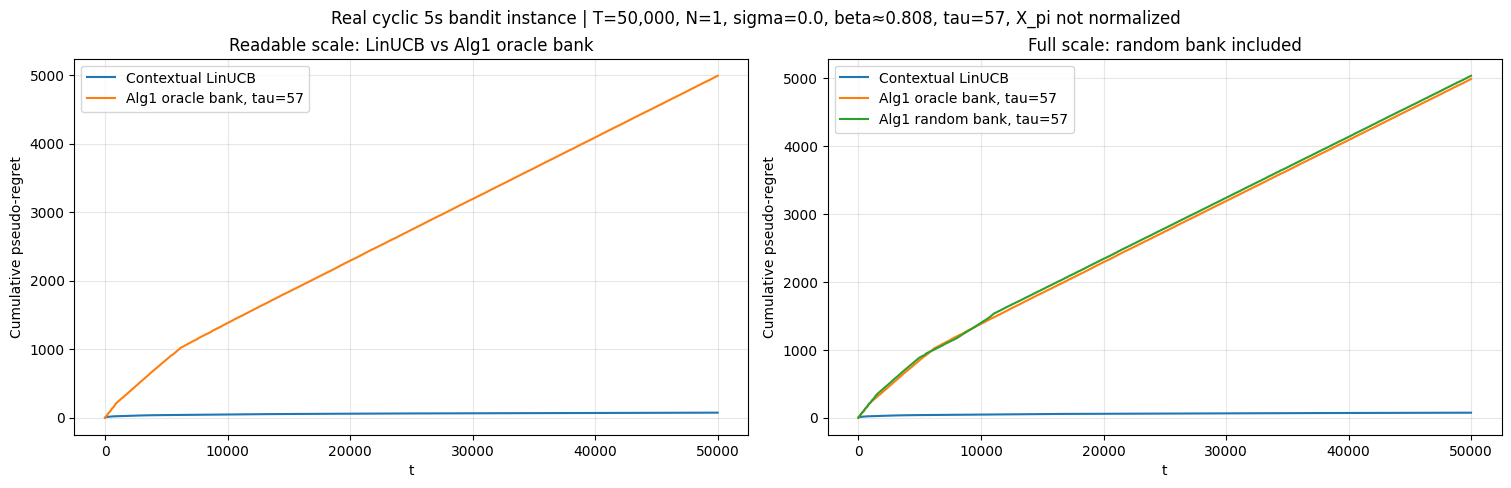

In [5]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm


# ============================================================
# Config
# ============================================================

inst = instance_to_use  # should be cyclic_instance_5s

T = min(50_000, inst.num_times)
d = inst.feature_dim

SIGMA = 0.0          # first run exact linearized rewards; add small noise later
N_RUNS = 1
ALG_SEED0 = 0
BANK_SEED = 123

M_RANDOM = 512       # random bank size; oracle bank will be M_RANDOM + 1
THETA_BATCH = 16     # for building g_pi(theta) without huge memory

# Use beta from cyclic instance metadata
beta_hat = inst.meta["beta_estimation"]["beta_hat_used"]
c_tau = 1.0
tau = int(math.ceil(c_tau * math.log(T) / max(1e-12, 1.0 - beta_hat)))

print(f"[info] T={T}, d={d}, beta_hat={beta_hat:.6f}, c_tau={c_tau}, tau={tau}")

# Contextual LinUCB / OFUL-ish baseline
lam_base = 1.0
alpha_base = 1.0

# LinUCB over surrogate set X_pi inside Algorithm 1
lam_alg1 = 100.0
alpha_alg1 = 1.0
bonus_cap = 2.5     # important: no cap first; set e.g. 2.5 only as ablation

# Unique cyclic period. The first period_len entries of inst are one unique 5s modular cycle.
period_len = int(inst.meta["period_len"])
X_period = np.stack([np.asarray(X, dtype=np.float64) for X in inst.X_by_t[:period_len]], axis=0)
theta_star = np.asarray(inst.theta_star, dtype=np.float64)

# Precompute true expected rewards for one period.
# Shape: (period_len, 129)
R_period = np.einsum("tkd,d->tk", X_period, theta_star)
best_R_period = R_period.max(axis=1)

print(f"[info] period_len={period_len}, X_period.shape={X_period.shape}")
print(f"[info] reward range over period: min={R_period.min():.4f}, max={R_period.max():.4f}, mean={R_period.mean():.4f}")
print(f"[info] theta_star norm={np.linalg.norm(theta_star):.4f}")


# ============================================================
# Helpers
# ============================================================

def normalize_vec(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return v / max(np.linalg.norm(v), eps)


def unit_vecs(rng, n, d):
    X = rng.normal(size=(n, d))
    X = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
    return X


def sherman_morrison(Vinv, x):
    x = np.asarray(x, dtype=np.float64).reshape(-1, 1)
    Vx = Vinv @ x
    denom = float(1.0 + x.T @ Vx)
    return Vinv - (Vx @ Vx.T) / max(1e-12, denom)


class LinUCBContextual:
    """
    Direct contextual LinUCB/OFUL-style baseline.
    At each t, observes X_t and selects one row of X_t.
    """
    def __init__(self, d, lam=1.0, alpha=1.0):
        self.Vinv = np.eye(d) / lam
        self.b = np.zeros(d)
        self.alpha = float(alpha)

    def select_index(self, X_t):
        theta_hat = self.Vinv @ self.b
        means = X_t @ theta_hat
        quad = np.einsum("ij,jk,ik->i", X_t, self.Vinv, X_t)
        scores = means + self.alpha * np.sqrt(np.maximum(0.0, quad))
        return int(np.argmax(scores))

    def update(self, x, r):
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += np.asarray(x, dtype=np.float64) * float(r)


class LinUCBOverFixedSet:
    """
    LinUCB over fixed surrogate action set X_pi.
    select_index returns bank index j.
    """
    def __init__(self, X, lam=100.0, alpha=1.0, bonus_cap=None):
        self.X = np.asarray(X, dtype=np.float64)
        d = self.X.shape[1]
        self.Vinv = np.eye(d) / lam
        self.b = np.zeros(d)
        self.alpha = float(alpha)
        self.bonus_cap = bonus_cap

    def select_index(self):
        theta_hat = self.Vinv @ self.b
        means = self.X @ theta_hat
        quad = np.einsum("ij,jk,ik->i", self.X, self.Vinv, self.X)
        bonus = self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.bonus_cap is not None:
            bonus = np.minimum(bonus, float(self.bonus_cap))

        return int(np.argmax(means + bonus))

    def update(self, x, r):
        x = np.asarray(x, dtype=np.float64).reshape(-1)
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += x * float(r)


def build_empirical_g_pi_bank(X_period, theta_bank, batch_size=16):
    """
    Builds X_pi[j] = empirical average over one period of:
        argmax_a <a, theta_bank[j]>

    IMPORTANT: does NOT normalize X_pi rows.
    """
    X_period = np.asarray(X_period, dtype=np.float64)
    theta_bank = np.asarray(theta_bank, dtype=np.float64)

    N, K, d = X_period.shape
    M = theta_bank.shape[0]

    X_pi = np.zeros((M, d), dtype=np.float64)

    for start in tqdm(range(0, M, batch_size), desc="Building X_pi"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]  # (B, d)
        B = TH.shape[0]

        # scores[t, k, b] = <X_period[t,k], TH[b]>
        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)  # (N, B)

        # selected[t,b,d] = X_period[t, idx[t,b], :]
        selected = X_period[np.arange(N)[:, None], idx]  # (N, B, d)
        X_pi[start:end] = selected.mean(axis=0)

    return X_pi


def bank_floor_regret(X_period, R_period, best_R_period, theta_bank, batch_size=16):
    """
    Computes the best possible average per-round regret achievable by the bank:
        min_j E_t[max_i r_t(i) - r_t(argmax_i <X_t[i], theta_j>)]
    """
    X_period = np.asarray(X_period, dtype=np.float64)
    theta_bank = np.asarray(theta_bank, dtype=np.float64)

    M = theta_bank.shape[0]
    avg_regrets = np.zeros(M, dtype=np.float64)

    for start in tqdm(range(0, M, batch_size), desc="Bank floor"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]
        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)  # (N, B)

        chosen_rewards = np.take_along_axis(
            R_period[:, :, None],
            idx[:, None, :],
            axis=1,
        )[:, 0, :]  # (N, B)

        regrets = best_R_period[:, None] - chosen_rewards
        avg_regrets[start:end] = regrets.mean(axis=0)

    best_j = int(np.argmin(avg_regrets))
    return {
        "best_index": best_j,
        "best_avg_regret": float(avg_regrets[best_j]),
        "median_avg_regret": float(np.median(avg_regrets)),
        "mean_avg_regret": float(np.mean(avg_regrets)),
        "avg_regrets": avg_regrets,
    }


# ============================================================
# Build theta banks
# ============================================================

rng_bank = np.random.default_rng(BANK_SEED)

theta_star_dir = normalize_vec(theta_star)
theta_random = unit_vecs(rng_bank, M_RANDOM, d)

theta_bank_random = theta_random.copy()
theta_bank_oracle = np.vstack([theta_star_dir[None, :], theta_random])

print(f"[info] random bank shape: {theta_bank_random.shape}")
print(f"[info] oracle bank shape: {theta_bank_oracle.shape}  (first vector is theta_star direction)")

cos_random = theta_bank_random @ theta_star_dir
cos_oracle = theta_bank_oracle @ theta_star_dir

print(f"[bank] random max cosine with theta_star: {cos_random.max():.4f}")
print(f"[bank] oracle max cosine with theta_star: {cos_oracle.max():.4f}")


# ============================================================
# Build X_pi for both banks; no normalization
# ============================================================

X_pi_random = build_empirical_g_pi_bank(
    X_period,
    theta_bank_random,
    batch_size=THETA_BATCH,
)

X_pi_oracle = build_empirical_g_pi_bank(
    X_period,
    theta_bank_oracle,
    batch_size=THETA_BATCH,
)

print("[info] X_pi built.")
print(f"X_pi_random shape: {X_pi_random.shape}, norms: min={np.linalg.norm(X_pi_random, axis=1).min():.3f}, max={np.linalg.norm(X_pi_random, axis=1).max():.3f}")
print(f"X_pi_oracle shape: {X_pi_oracle.shape}, norms: min={np.linalg.norm(X_pi_oracle, axis=1).min():.3f}, max={np.linalg.norm(X_pi_oracle, axis=1).max():.3f}")


# ============================================================
# Bank approximation diagnostics
# ============================================================

floor_random = bank_floor_regret(
    X_period,
    R_period,
    best_R_period,
    theta_bank_random,
    batch_size=THETA_BATCH,
)

floor_oracle = bank_floor_regret(
    X_period,
    R_period,
    best_R_period,
    theta_bank_oracle,
    batch_size=THETA_BATCH,
)

bank_diag_df = pd.DataFrame([
    {
        "bank": "oracle",
        "M": len(theta_bank_oracle),
        "max_cos_theta_star": cos_oracle.max(),
        "best_avg_regret_floor": floor_oracle["best_avg_regret"],
        "median_avg_regret": floor_oracle["median_avg_regret"],
        "mean_avg_regret": floor_oracle["mean_avg_regret"],
        "best_index": floor_oracle["best_index"],
    },
    {
        "bank": "random",
        "M": len(theta_bank_random),
        "max_cos_theta_star": cos_random.max(),
        "best_avg_regret_floor": floor_random["best_avg_regret"],
        "median_avg_regret": floor_random["median_avg_regret"],
        "mean_avg_regret": floor_random["mean_avg_regret"],
        "best_index": floor_random["best_index"],
    },
])

display(bank_diag_df.round(6))


# ============================================================
# Single Monte Carlo run
# ============================================================

def run_once_real_instance(alg_seed):
    rng = np.random.default_rng(alg_seed)

    # Direct contextual LinUCB
    lin = LinUCBContextual(d, lam=lam_base, alpha=alpha_base)

    # Algorithm 1 with oracle bank
    alg1_oracle = LinUCBOverFixedSet(
        X_pi_oracle,
        lam=lam_alg1,
        alpha=alpha_alg1,
        bonus_cap=bonus_cap,
    )

    # Algorithm 1 with random bank
    alg1_random = LinUCBOverFixedSet(
        X_pi_random,
        lam=lam_alg1,
        alpha=alpha_alg1,
        bonus_cap=bonus_cap,
    )

    # Delay buffers
    delay_len = max(1, tau + 1)

    xbuf_oracle = np.zeros((delay_len, d), dtype=np.float64)
    rbuf_oracle = np.zeros(delay_len, dtype=np.float64)

    xbuf_random = np.zeros((delay_len, d), dtype=np.float64)
    rbuf_random = np.zeros(delay_len, dtype=np.float64)

    cum_lin = np.zeros(T, dtype=np.float64)
    cum_alg1_oracle = np.zeros(T, dtype=np.float64)
    cum_alg1_random = np.zeros(T, dtype=np.float64)

    c_lin = 0.0
    c_oracle = 0.0
    c_random = 0.0

    for t in tqdm(range(T), desc=f"run seed={alg_seed}", leave=False):
        p = t % period_len

        X_t = X_period[p]
        mu_t = R_period[p]
        best_mu = best_R_period[p]

        # -------------------------
        # Contextual LinUCB
        # -------------------------
        i_lin = lin.select_index(X_t)
        r_lin_obs = float(mu_t[i_lin] + rng.normal(0.0, SIGMA))
        lin.update(X_t[i_lin], r_lin_obs)

        c_lin += float(best_mu - mu_t[i_lin])
        cum_lin[t] = c_lin

        # -------------------------
        # Algorithm 1: oracle bank
        # -------------------------
        if t < tau:
            j_oracle = int(rng.integers(len(theta_bank_oracle)))
        else:
            j_oracle = alg1_oracle.select_index()

        th_oracle = theta_bank_oracle[j_oracle]
        x_proxy_oracle = X_pi_oracle[j_oracle]

        i_oracle = int(np.argmax(X_t @ th_oracle))
        r_oracle_obs = float(mu_t[i_oracle] + rng.normal(0.0, SIGMA))

        slot = t % delay_len
        xbuf_oracle[slot] = x_proxy_oracle
        rbuf_oracle[slot] = r_oracle_obs

        if t >= tau:
            old_slot = (t - tau) % delay_len
            alg1_oracle.update(xbuf_oracle[old_slot], rbuf_oracle[old_slot])

        c_oracle += float(best_mu - mu_t[i_oracle])
        cum_alg1_oracle[t] = c_oracle

        # -------------------------
        # Algorithm 1: random bank
        # -------------------------
        if t < tau:
            j_random = int(rng.integers(len(theta_bank_random)))
        else:
            j_random = alg1_random.select_index()

        th_random = theta_bank_random[j_random]
        x_proxy_random = X_pi_random[j_random]

        i_random = int(np.argmax(X_t @ th_random))
        r_random_obs = float(mu_t[i_random] + rng.normal(0.0, SIGMA))

        xbuf_random[slot] = x_proxy_random
        rbuf_random[slot] = r_random_obs

        if t >= tau:
            old_slot = (t - tau) % delay_len
            alg1_random.update(xbuf_random[old_slot], rbuf_random[old_slot])

        c_random += float(best_mu - mu_t[i_random])
        cum_alg1_random[t] = c_random

    return cum_lin, cum_alg1_oracle, cum_alg1_random


# ============================================================
# Monte Carlo
# ============================================================

lin_mat = np.zeros((N_RUNS, T), dtype=np.float64)
oracle_mat = np.zeros((N_RUNS, T), dtype=np.float64)
random_mat = np.zeros((N_RUNS, T), dtype=np.float64)

for run in range(N_RUNS):
    seed = ALG_SEED0 + run
    print(f"Run {run + 1}/{N_RUNS} | seed={seed}")
    lin_mat[run], oracle_mat[run], random_mat[run] = run_once_real_instance(seed)

mean_lin = lin_mat.mean(axis=0)
mean_oracle = oracle_mat.mean(axis=0)
mean_random = random_mat.mean(axis=0)

se_lin = lin_mat.std(axis=0, ddof=1) / np.sqrt(N_RUNS) if N_RUNS > 1 else np.zeros(T)
se_oracle = oracle_mat.std(axis=0, ddof=1) / np.sqrt(N_RUNS) if N_RUNS > 1 else np.zeros(T)
se_random = random_mat.std(axis=0, ddof=1) / np.sqrt(N_RUNS) if N_RUNS > 1 else np.zeros(T)

summary_df = pd.DataFrame([
    {
        "method": "Contextual LinUCB",
        "final_mean": mean_lin[-1],
        "final_se": se_lin[-1],
    },
    {
        "method": "Alg1 oracle bank",
        "final_mean": mean_oracle[-1],
        "final_se": se_oracle[-1],
    },
    {
        "method": "Alg1 random bank",
        "final_mean": mean_random[-1],
        "final_se": se_random[-1],
    },
])

display(summary_df.round(4))


# ============================================================
# Plot: left readable scale, right full scale
# ============================================================

plot_step = max(1, T // 3000)
idx = np.arange(0, T, plot_step)
t_axis = idx + 1

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)

# Left: fair/readable comparison
ax = axes[0]
ax.plot(t_axis, mean_lin[idx], label="Contextual LinUCB")
ax.fill_between(
    t_axis,
    np.maximum(0.0, mean_lin[idx] - se_lin[idx]),
    mean_lin[idx] + se_lin[idx],
    alpha=0.2,
)

ax.plot(t_axis, mean_oracle[idx], label=f"Alg1 oracle bank, tau={tau}")
ax.fill_between(
    t_axis,
    np.maximum(0.0, mean_oracle[idx] - se_oracle[idx]),
    mean_oracle[idx] + se_oracle[idx],
    alpha=0.2,
)

ax.set_title("Readable scale: LinUCB vs Alg1 oracle bank")
ax.set_xlabel("t")
ax.set_ylabel("Cumulative pseudo-regret")
ax.grid(True, alpha=0.3)
ax.legend()

# Right: full scale including random bank
ax = axes[1]
ax.plot(t_axis, mean_lin[idx], label="Contextual LinUCB")
ax.plot(t_axis, mean_oracle[idx], label=f"Alg1 oracle bank, tau={tau}")
ax.plot(t_axis, mean_random[idx], label=f"Alg1 random bank, tau={tau}")

ax.fill_between(
    t_axis,
    np.maximum(0.0, mean_random[idx] - se_random[idx]),
    mean_random[idx] + se_random[idx],
    alpha=0.15,
)

ax.set_title("Full scale: random bank included")
ax.set_xlabel("t")
ax.set_ylabel("Cumulative pseudo-regret")
ax.grid(True, alpha=0.3)
ax.legend()

fig.suptitle(
    f"Real cyclic 5s bandit instance | T={T:,}, N={N_RUNS}, "
    f"sigma={SIGMA}, beta≈{beta_hat:.3f}, tau={tau}, "
    f"X_pi not normalized",
    y=1.05,
)

plt.show()

T=50000, d=25, period_len=7208, beta=0.8075, tau=57
reward range: [0.0987, 1.0369], mean=0.4916
theta_star norm = 1.2993
oracle bank M=513
max cos with theta_star = 1.000000; index=0


Building X_pi:   0%|          | 0/33 [00:00<?, ?it/s]

Bank floor:   0%|          | 0/33 [00:00<?, ?it/s]

,j,cos_to_theta_star,Xpi_norm,fixed_theta_avg_regret
0,0,1.000000,1.610606,0.000000
496,496,0.191692,1.872652,0.089893
488,488,0.374491,1.683908,0.091123
61,61,0.596574,1.546773,0.096759
372,372,0.020167,1.655507,0.098755
105,105,0.366372,1.727595,0.103365
378,378,0.079691,1.875725,0.104216
131,131,0.451016,1.867981,0.111349
382,382,0.025279,1.850433,0.114623
71,71,0.099224,1.740202,0.114914


theta_star arm floor regret j=0: 0.00000000
best bank floor regret: 0.00000000 at j=0
median bank floor regret: 0.279735


Running debug:   0%|          | 0/50000 [00:00<?, ?it/s]

C:\Users\kaanb\AppData\Local\Temp\ipykernel_37196\439033029.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  denom = float(1.0 + x.T @ Vx)


,method,final_cum_regret,avg_regret
0,Contextual LinUCB,72.921949,0.001458
1,Alg1 random warmup,216.535227,0.004331
2,Alg1 sweep warmup,205.208796,0.004104
3,Always theta_star direction,0.000000,0.000000


,j,count,freq,cos_to_star,bank_floor,Xpi_norm,method
0,0,48729,0.97458,1.000000,0.000000,1.610606,random_warmup
1,400,237,0.00474,0.124846,0.176002,1.670019,random_warmup
2,246,170,0.00340,0.179046,0.128222,1.687114,random_warmup
3,96,158,0.00316,-0.067951,0.164180,1.695187,random_warmup
4,11,91,0.00182,0.168323,0.152467,1.681393,random_warmup
5,99,77,0.00154,0.100917,0.137315,1.808754,random_warmup
6,353,63,0.00126,0.151677,0.138638,1.711195,random_warmup
7,23,55,0.00110,-0.195464,0.249946,1.466318,random_warmup
8,105,54,0.00108,0.366372,0.103365,1.727595,random_warmup
9,362,53,0.00106,0.325214,0.279397,1.593746,random_warmup


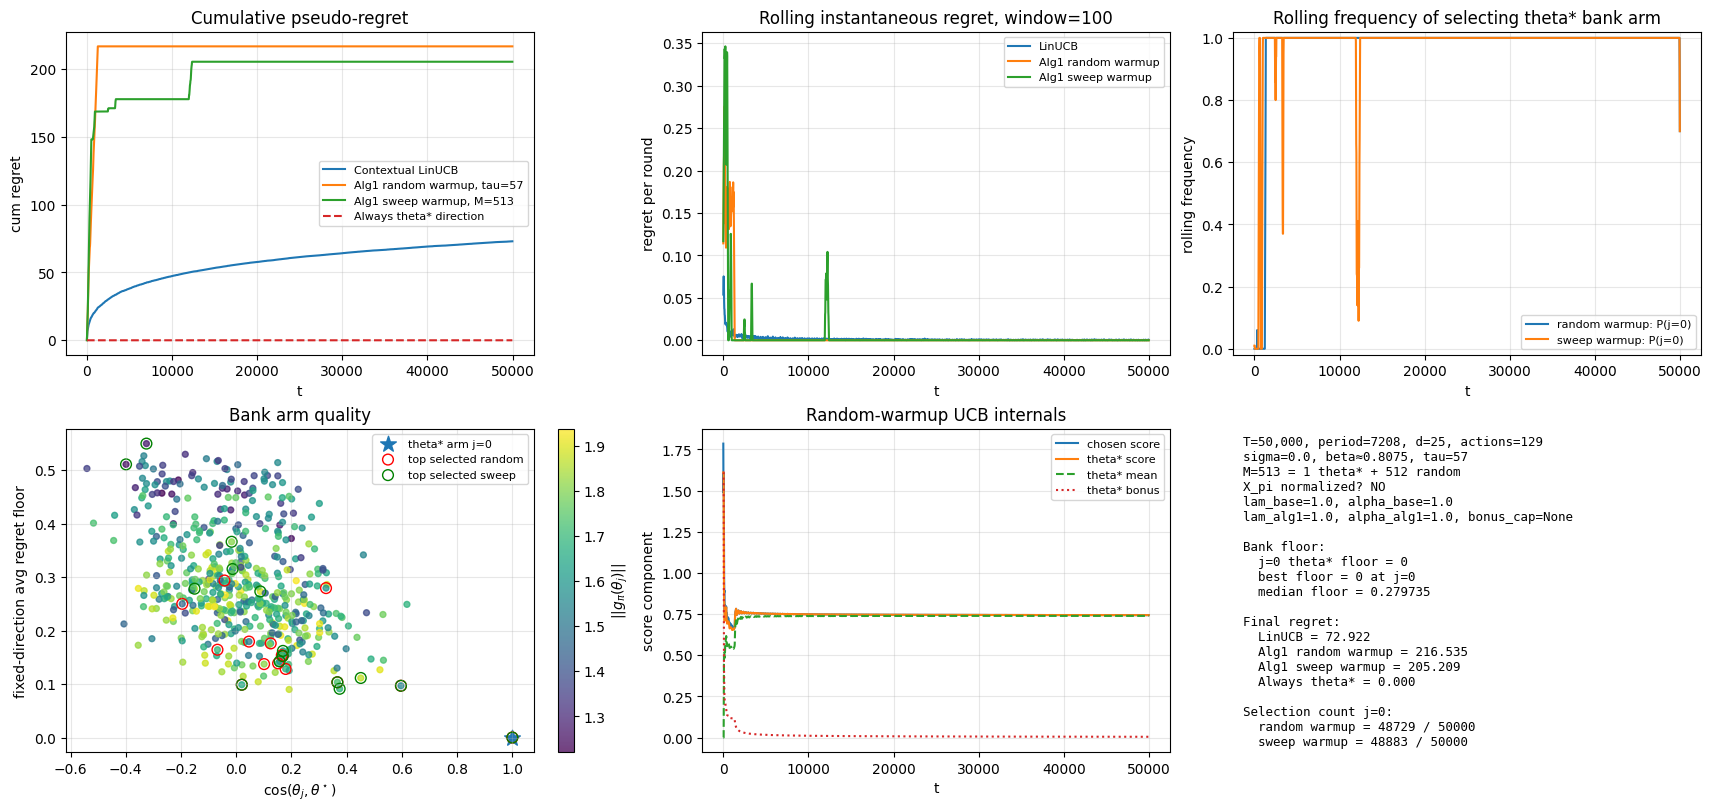

In [7]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ============================================================
# Config
# ============================================================

inst = instance_to_use          # cyclic_instance_5s
T = min(50_000, inst.num_times)
d = inst.feature_dim

SIGMA = 0.0                     # debug exact linearized setting first
SEED = 0
BANK_SEED = 123

M_RANDOM = 512                  # oracle bank has M_RANDOM + 1, with theta_star at index 0
THETA_BATCH = 16

beta_hat = inst.meta["beta_estimation"]["beta_hat_used"]
c_tau = 1.0
tau = int(math.ceil(c_tau * math.log(T) / max(1e-12, 1.0 - beta_hat)))

lam_base = 1.0
alpha_base = 1.0

lam_alg1 = 1.0
alpha_alg1 = 1.0
bonus_cap = None                # keep None for faithful non-normalized X_pi first

period_len = int(inst.meta["period_len"])
X_period = np.stack([np.asarray(X, dtype=np.float64) for X in inst.X_by_t[:period_len]], axis=0)
theta_star = np.asarray(inst.theta_star, dtype=np.float64)

R_period = np.einsum("tkd,d->tk", X_period, theta_star, optimize=True)
best_R_period = R_period.max(axis=1)
best_action_period = R_period.argmax(axis=1)

print(f"T={T}, d={d}, period_len={period_len}, beta={beta_hat:.4f}, tau={tau}")
print(f"reward range: [{R_period.min():.4f}, {R_period.max():.4f}], mean={R_period.mean():.4f}")
print(f"theta_star norm = {np.linalg.norm(theta_star):.4f}")


# ============================================================
# Helpers
# ============================================================

def normalize_vec(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return v / max(np.linalg.norm(v), eps)

def unit_vecs(rng, n, d):
    X = rng.normal(size=(n, d))
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)

def sherman_morrison(Vinv, x):
    x = np.asarray(x, dtype=np.float64).reshape(-1, 1)
    Vx = Vinv @ x
    denom = float(1.0 + x.T @ Vx)
    return Vinv - (Vx @ Vx.T) / max(1e-12, denom)

class LinUCBContextual:
    def __init__(self, d, lam=1.0, alpha=1.0):
        self.Vinv = np.eye(d) / lam
        self.b = np.zeros(d)
        self.alpha = float(alpha)

    def select_index(self, X_t):
        theta_hat = self.Vinv @ self.b
        means = X_t @ theta_hat
        quad = np.einsum("ij,jk,ik->i", X_t, self.Vinv, X_t, optimize=True)
        scores = means + self.alpha * np.sqrt(np.maximum(0.0, quad))
        return int(np.argmax(scores))

    def update(self, x, r):
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += np.asarray(x, dtype=np.float64) * float(r)

class LinUCBOverFixedSet:
    def __init__(self, X, lam=100.0, alpha=1.0, bonus_cap=None):
        self.X = np.asarray(X, dtype=np.float64)
        self.Vinv = np.eye(self.X.shape[1]) / lam
        self.b = np.zeros(self.X.shape[1])
        self.alpha = float(alpha)
        self.bonus_cap = bonus_cap

    def score_all(self):
        theta_hat = self.Vinv @ self.b
        means = self.X @ theta_hat
        quad = np.einsum("ij,jk,ik->i", self.X, self.Vinv, self.X, optimize=True)
        bonus = self.alpha * np.sqrt(np.maximum(0.0, quad))
        if self.bonus_cap is not None:
            bonus = np.minimum(bonus, float(self.bonus_cap))
        return means + bonus, means, bonus

    def select_index(self):
        scores, _, _ = self.score_all()
        return int(np.argmax(scores))

    def update(self, x, r):
        x = np.asarray(x, dtype=np.float64).reshape(-1)
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += x * float(r)

def build_empirical_g_pi_bank(X_period, theta_bank, batch_size=16):
    """
    X_pi[j] = empirical E_{A~pi}[argmax_a <a, theta_j>].
    No normalization.
    """
    X_period = np.asarray(X_period, dtype=np.float64)
    theta_bank = np.asarray(theta_bank, dtype=np.float64)

    N, K, d = X_period.shape
    M = theta_bank.shape[0]
    X_pi = np.zeros((M, d), dtype=np.float64)

    for start in tqdm(range(0, M, batch_size), desc="Building X_pi"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)
        selected = X_period[np.arange(N)[:, None], idx]
        X_pi[start:end] = selected.mean(axis=0)

    return X_pi

def bank_floor_regret(X_period, R_period, best_R_period, theta_bank, batch_size=16):
    """
    Average regret of each fixed theta direction if used forever.
    """
    M = theta_bank.shape[0]
    avg_regrets = np.zeros(M)

    for start in tqdm(range(0, M, batch_size), desc="Bank floor"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)

        chosen_rewards = np.take_along_axis(
            R_period[:, :, None],
            idx[:, None, :],
            axis=1,
        )[:, 0, :]

        avg_regrets[start:end] = (best_R_period[:, None] - chosen_rewards).mean(axis=0)

    return avg_regrets

def rolling_mean(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="same")


# ============================================================
# Oracle bank: theta_star direction + random directions
# ============================================================

rng_bank = np.random.default_rng(BANK_SEED)
theta_star_dir = normalize_vec(theta_star)
theta_random = unit_vecs(rng_bank, M_RANDOM, d)

theta_bank = np.vstack([theta_star_dir[None, :], theta_random])
M = len(theta_bank)

cos_to_star = theta_bank @ theta_star_dir

print(f"oracle bank M={M}")
print(f"max cos with theta_star = {cos_to_star.max():.6f}; index={int(np.argmax(cos_to_star))}")

X_pi = build_empirical_g_pi_bank(X_period, theta_bank, batch_size=THETA_BATCH)
X_pi_norms = np.linalg.norm(X_pi, axis=1)

bank_floor = bank_floor_regret(X_period, R_period, best_R_period, theta_bank, batch_size=THETA_BATCH)

bank_diag = pd.DataFrame({
    "j": np.arange(M),
    "cos_to_theta_star": cos_to_star,
    "Xpi_norm": X_pi_norms,
    "fixed_theta_avg_regret": bank_floor,
}).sort_values("fixed_theta_avg_regret")

display(bank_diag.head(15).round(6))

print(f"theta_star arm floor regret j=0: {bank_floor[0]:.8f}")
print(f"best bank floor regret: {bank_floor.min():.8f} at j={int(bank_floor.argmin())}")
print(f"median bank floor regret: {np.median(bank_floor):.6f}")


# ============================================================
# Run diagnostic algorithms
# ============================================================

def run_alg1_oracle_bank_debug(seed=0):
    rng = np.random.default_rng(seed)

    lin = LinUCBContextual(d, lam=lam_base, alpha=alpha_base)

    alg_random_warm = LinUCBOverFixedSet(X_pi, lam=lam_alg1, alpha=alpha_alg1, bonus_cap=bonus_cap)
    alg_sweep_warm = LinUCBOverFixedSet(X_pi, lam=lam_alg1, alpha=alpha_alg1, bonus_cap=bonus_cap)

    delay_len = max(1, tau + 1)

    xbuf_random = np.zeros((delay_len, d))
    rbuf_random = np.zeros(delay_len)

    xbuf_sweep = np.zeros((delay_len, d))
    rbuf_sweep = np.zeros(delay_len)

    regret_lin = np.zeros(T)
    regret_alg_random = np.zeros(T)
    regret_alg_sweep = np.zeros(T)
    regret_star_direction = np.zeros(T)

    chosen_j_random = np.zeros(T, dtype=int)
    chosen_j_sweep = np.zeros(T, dtype=int)

    selected_regret_random = np.zeros(T)
    selected_regret_sweep = np.zeros(T)

    star_score_random = np.zeros(T)
    chosen_score_random = np.zeros(T)
    star_mean_random = np.zeros(T)
    star_bonus_random = np.zeros(T)

    c_lin = 0.0
    c_random = 0.0
    c_sweep = 0.0
    c_star = 0.0

    # For finite bank: sweep all arms once, then UCB.
    sweep_len = M

    for t in tqdm(range(T), desc="Running debug"):
        p = t % period_len

        X_t = X_period[p]
        mu_t = R_period[p]
        best_mu = best_R_period[p]

        # -------------------------
        # Contextual LinUCB
        # -------------------------
        i_lin = lin.select_index(X_t)
        r_lin = float(mu_t[i_lin] + rng.normal(0.0, SIGMA))
        lin.update(X_t[i_lin], r_lin)

        inst_reg_lin = float(best_mu - mu_t[i_lin])
        c_lin += inst_reg_lin
        regret_lin[t] = c_lin

        # -------------------------
        # Always theta_star direction sanity
        # -------------------------
        i_star = int(np.argmax(X_t @ theta_bank[0]))
        inst_reg_star = float(best_mu - mu_t[i_star])
        c_star += inst_reg_star
        regret_star_direction[t] = c_star

        # -------------------------
        # Alg1 A: paper-style random warm start t < tau
        # -------------------------
        if t < tau:
            j = int(rng.integers(M))
        else:
            j = alg_random_warm.select_index()

        scores, means, bonus = alg_random_warm.score_all()
        star_score_random[t] = scores[0]
        chosen_score_random[t] = scores[j]
        star_mean_random[t] = means[0]
        star_bonus_random[t] = bonus[0]

        th = theta_bank[j]
        x_proxy = X_pi[j]

        i = int(np.argmax(X_t @ th))
        r_obs = float(mu_t[i] + rng.normal(0.0, SIGMA))

        slot = t % delay_len
        xbuf_random[slot] = x_proxy
        rbuf_random[slot] = r_obs

        if t >= tau:
            old = (t - tau) % delay_len
            alg_random_warm.update(xbuf_random[old], rbuf_random[old])

        inst_reg = float(best_mu - mu_t[i])
        c_random += inst_reg
        regret_alg_random[t] = c_random
        selected_regret_random[t] = inst_reg
        chosen_j_random[t] = j

        # -------------------------
        # Alg1 B: finite-bank sweep warm start
        # -------------------------
        if t < sweep_len:
            j2 = t % M
        else:
            j2 = alg_sweep_warm.select_index()

        th2 = theta_bank[j2]
        x_proxy2 = X_pi[j2]

        i2 = int(np.argmax(X_t @ th2))
        r_obs2 = float(mu_t[i2] + rng.normal(0.0, SIGMA))

        xbuf_sweep[slot] = x_proxy2
        rbuf_sweep[slot] = r_obs2

        if t >= tau:
            old = (t - tau) % delay_len
            alg_sweep_warm.update(xbuf_sweep[old], rbuf_sweep[old])

        inst_reg2 = float(best_mu - mu_t[i2])
        c_sweep += inst_reg2
        regret_alg_sweep[t] = c_sweep
        selected_regret_sweep[t] = inst_reg2
        chosen_j_sweep[t] = j2

    return {
        "cum_lin": regret_lin,
        "cum_alg_random_warm": regret_alg_random,
        "cum_alg_sweep_warm": regret_alg_sweep,
        "cum_star_direction": regret_star_direction,
        "chosen_j_random": chosen_j_random,
        "chosen_j_sweep": chosen_j_sweep,
        "inst_reg_random": selected_regret_random,
        "inst_reg_sweep": selected_regret_sweep,
        "star_score_random": star_score_random,
        "chosen_score_random": chosen_score_random,
        "star_mean_random": star_mean_random,
        "star_bonus_random": star_bonus_random,
    }

out = run_alg1_oracle_bank_debug(SEED)


# ============================================================
# Summary tables
# ============================================================

summary = pd.DataFrame([
    {"method": "Contextual LinUCB", "final_cum_regret": out["cum_lin"][-1], "avg_regret": out["cum_lin"][-1] / T},
    {"method": "Alg1 random warmup", "final_cum_regret": out["cum_alg_random_warm"][-1], "avg_regret": out["cum_alg_random_warm"][-1] / T},
    {"method": "Alg1 sweep warmup", "final_cum_regret": out["cum_alg_sweep_warm"][-1], "avg_regret": out["cum_alg_sweep_warm"][-1] / T},
    {"method": "Always theta_star direction", "final_cum_regret": out["cum_star_direction"][-1], "avg_regret": out["cum_star_direction"][-1] / T},
])
display(summary.round(6))

def top_selected_table(chosen_j, name, topn=15):
    vals, counts = np.unique(chosen_j, return_counts=True)
    df = pd.DataFrame({"j": vals, "count": counts})
    df["freq"] = df["count"] / len(chosen_j)
    df["cos_to_star"] = cos_to_star[df["j"].to_numpy()]
    df["bank_floor"] = bank_floor[df["j"].to_numpy()]
    df["Xpi_norm"] = X_pi_norms[df["j"].to_numpy()]
    df["method"] = name
    return df.sort_values("count", ascending=False).head(topn)

selected_diag = pd.concat([
    top_selected_table(out["chosen_j_random"], "random_warmup"),
    top_selected_table(out["chosen_j_sweep"], "sweep_warmup"),
], ignore_index=True)

display(selected_diag.round(6))


# ============================================================
# Dense plots
# ============================================================

plot_step = max(1, T // 2500)
idx = np.arange(0, T, plot_step)
t_axis = idx + 1

w = max(50, T // 500)

star_selected_random_roll = rolling_mean((out["chosen_j_random"] == 0).astype(float), w)
star_selected_sweep_roll = rolling_mean((out["chosen_j_sweep"] == 0).astype(float), w)

fig, axes = plt.subplots(2, 3, figsize=(17, 8), constrained_layout=True)

# 1. Cumulative regret readable
ax = axes[0, 0]
ax.plot(t_axis, out["cum_lin"][idx], label="Contextual LinUCB")
ax.plot(t_axis, out["cum_alg_random_warm"][idx], label=f"Alg1 random warmup, tau={tau}")
ax.plot(t_axis, out["cum_alg_sweep_warm"][idx], label=f"Alg1 sweep warmup, M={M}")
ax.plot(t_axis, out["cum_star_direction"][idx], "--", label="Always theta* direction")
ax.set_title("Cumulative pseudo-regret")
ax.set_xlabel("t")
ax.set_ylabel("cum regret")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 2. Rolling instantaneous regret
ax = axes[0, 1]
ax.plot(t_axis, rolling_mean(np.diff(np.r_[0, out["cum_lin"]]), w)[idx], label="LinUCB")
ax.plot(t_axis, rolling_mean(out["inst_reg_random"], w)[idx], label="Alg1 random warmup")
ax.plot(t_axis, rolling_mean(out["inst_reg_sweep"], w)[idx], label="Alg1 sweep warmup")
ax.set_title(f"Rolling instantaneous regret, window={w}")
ax.set_xlabel("t")
ax.set_ylabel("regret per round")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 3. Does Alg1 select theta_star arm?
ax = axes[0, 2]
ax.plot(t_axis, star_selected_random_roll[idx], label="random warmup: P(j=0)")
ax.plot(t_axis, star_selected_sweep_roll[idx], label="sweep warmup: P(j=0)")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Rolling frequency of selecting theta* bank arm")
ax.set_xlabel("t")
ax.set_ylabel("rolling frequency")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 4. Bank geometry: floor vs cosine
ax = axes[1, 0]
sc = ax.scatter(
    cos_to_star,
    bank_floor,
    c=X_pi_norms,
    s=18,
    alpha=0.75,
)
ax.scatter([cos_to_star[0]], [bank_floor[0]], s=140, marker="*", label="theta* arm j=0")
top_rand = selected_diag[selected_diag["method"] == "random_warmup"]["j"].to_numpy(dtype=int)
top_sweep = selected_diag[selected_diag["method"] == "sweep_warmup"]["j"].to_numpy(dtype=int)
ax.scatter(cos_to_star[top_rand], bank_floor[top_rand], s=60, facecolors="none", edgecolors="red", label="top selected random")
ax.scatter(cos_to_star[top_sweep], bank_floor[top_sweep], s=60, facecolors="none", edgecolors="green", label="top selected sweep")
ax.set_title("Bank arm quality")
ax.set_xlabel(r"cos($\theta_j,\theta^\star$)")
ax.set_ylabel("fixed-direction avg regret floor")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$||g_\pi(\theta_j)||$")

# 5. UCB score diagnostics for random warmup
ax = axes[1, 1]
ax.plot(t_axis, out["chosen_score_random"][idx], label="chosen score")
ax.plot(t_axis, out["star_score_random"][idx], label="theta* score")
ax.plot(t_axis, out["star_mean_random"][idx], "--", label="theta* mean")
ax.plot(t_axis, out["star_bonus_random"][idx], ":", label="theta* bonus")
ax.set_title("Random-warmup UCB internals")
ax.set_xlabel("t")
ax.set_ylabel("score component")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 6. Text card
ax = axes[1, 2]
ax.axis("off")
text = (
    f"T={T:,}, period={period_len}, d={d}, actions=129\n"
    f"sigma={SIGMA}, beta≈{beta_hat:.4f}, tau={tau}\n"
    f"M={M} = 1 theta* + {M_RANDOM} random\n"
    f"X_pi normalized? NO\n"
    f"lam_base={lam_base}, alpha_base={alpha_base}\n"
    f"lam_alg1={lam_alg1}, alpha_alg1={alpha_alg1}, bonus_cap={bonus_cap}\n\n"
    f"Bank floor:\n"
    f"  j=0 theta* floor = {bank_floor[0]:.6g}\n"
    f"  best floor = {bank_floor.min():.6g} at j={int(bank_floor.argmin())}\n"
    f"  median floor = {np.median(bank_floor):.6g}\n\n"
    f"Final regret:\n"
    f"  LinUCB = {out['cum_lin'][-1]:.3f}\n"
    f"  Alg1 random warmup = {out['cum_alg_random_warm'][-1]:.3f}\n"
    f"  Alg1 sweep warmup = {out['cum_alg_sweep_warm'][-1]:.3f}\n"
    f"  Always theta* = {out['cum_star_direction'][-1]:.3f}\n\n"
    f"Selection count j=0:\n"
    f"  random warmup = {(out['chosen_j_random'] == 0).sum()} / {T}\n"
    f"  sweep warmup = {(out['chosen_j_sweep'] == 0).sum()} / {T}"
)
ax.text(0.02, 0.98, text, va="top", ha="left", family="monospace", fontsize=9)

plt.show()

T=50000, d=25, period_len=7208, beta=0.8075, tau=57
reward range: [0.0987, 1.0369], mean=0.4916
theta_star norm = 1.2993
oracle bank M=513
max cos with theta_star = 1.000000; index=0


Building X_pi:   0%|          | 0/33 [00:00<?, ?it/s]

Bank floor:   0%|          | 0/33 [00:00<?, ?it/s]

,j,cos_to_theta_star,Xpi_norm_normalized,Xpi_norm_raw,fixed_theta_avg_regret
0,0,1.000000,1.0,1.610606,0.000000
496,496,0.191692,1.0,1.872652,0.089893
488,488,0.374491,1.0,1.683908,0.091123
61,61,0.596574,1.0,1.546773,0.096759
372,372,0.020167,1.0,1.655507,0.098755
105,105,0.366372,1.0,1.727595,0.103365
378,378,0.079691,1.0,1.875725,0.104216
131,131,0.451016,1.0,1.867981,0.111349
382,382,0.025279,1.0,1.850433,0.114623
71,71,0.099224,1.0,1.740202,0.114914


theta_star arm floor regret j=0: 0.00000000
best bank floor regret: 0.00000000 at j=0
median bank floor regret: 0.279735


Running normalized-Xpi Alg1 debug:   0%|          | 0/50000 [00:00<?, ?it/s]

C:\Users\kaanb\AppData\Local\Temp\ipykernel_37196\561743887.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  denom = float(1.0 + x.T @ Vx)


,method,final_cum_regret,avg_regret
0,Contextual LinUCB,72.921949,0.001458
1,"Alg1 oracle bank, normalized X_pi, LinUCB from...",176.214124,0.003524
2,Always theta_star direction,0.000000,0.000000


,j,count,freq,cos_to_star,bank_floor,Xpi_norm_raw,Xpi_norm_normalized
0,0,48799,0.97598,1.000000,0.000000,1.610606,1.0
18,105,305,0.00610,0.366372,0.103365,1.727595,1.0
78,488,169,0.00338,0.374491,0.091123,1.683908,1.0
12,61,138,0.00276,0.596574,0.096759,1.546773,1.0
36,210,72,0.00144,0.262723,0.154807,1.591140,1.0
32,177,71,0.00142,0.488193,0.146775,1.670377,1.0
21,114,63,0.00126,0.187156,0.184805,1.682662,1.0
2,11,61,0.00122,0.168323,0.152467,1.681393,1.0
17,96,59,0.00118,-0.067951,0.164180,1.695187,1.0
61,378,58,0.00116,0.079691,0.104216,1.875725,1.0


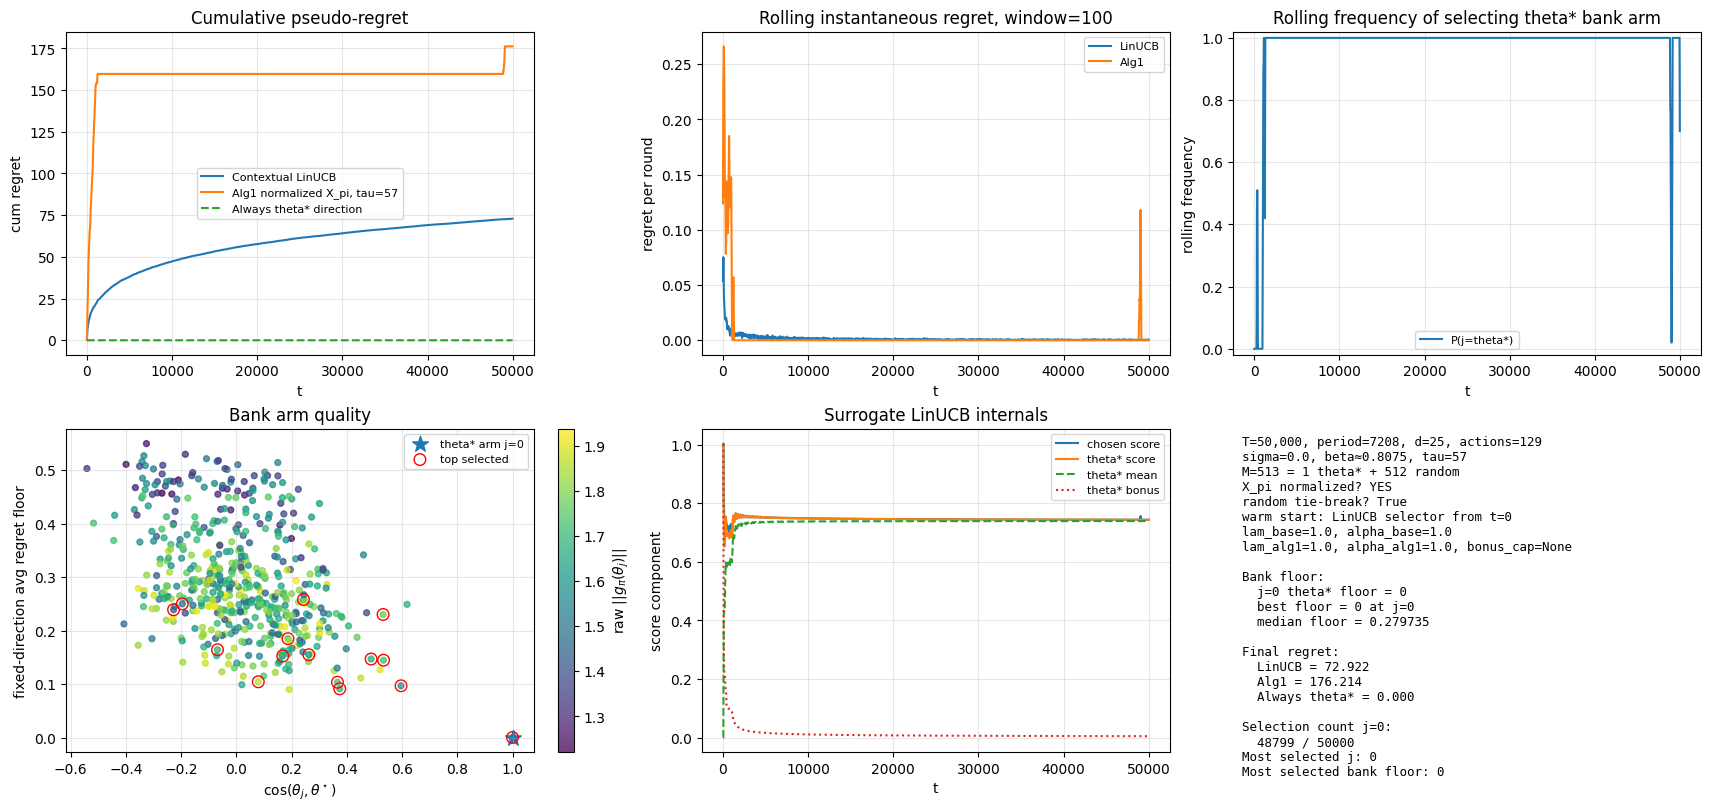

In [9]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ============================================================
# Config
# ============================================================

inst = instance_to_use
T = min(50_000, inst.num_times)
d = inst.feature_dim

SIGMA = 0.0
SEED = 0
BANK_SEED = 123

M_RANDOM = 512
THETA_BATCH = 16

beta_hat = inst.meta["beta_estimation"]["beta_hat_used"]
c_tau = 1.0
tau = int(math.ceil(c_tau * math.log(T) / max(1e-12, 1.0 - beta_hat)))

lam_base = 1.0
alpha_base = 1.0

lam_alg1 = 1.0
alpha_alg1 = 1.0
bonus_cap = None

RANDOM_TIE_BREAK = True

period_len = int(inst.meta["period_len"])
X_period = np.stack([np.asarray(X, dtype=np.float64) for X in inst.X_by_t[:period_len]], axis=0)
theta_star = np.asarray(inst.theta_star, dtype=np.float64)

R_period = np.einsum("tkd,d->tk", X_period, theta_star, optimize=True)
best_R_period = R_period.max(axis=1)
best_action_period = R_period.argmax(axis=1)

print(f"T={T}, d={d}, period_len={period_len}, beta={beta_hat:.4f}, tau={tau}")
print(f"reward range: [{R_period.min():.4f}, {R_period.max():.4f}], mean={R_period.mean():.4f}")
print(f"theta_star norm = {np.linalg.norm(theta_star):.4f}")


# ============================================================
# Helpers
# ============================================================

def normalize_vec(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return v / max(np.linalg.norm(v), eps)


def normalize_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=np.float64)
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)


def unit_vecs(rng, n, d):
    X = rng.normal(size=(n, d))
    return normalize_rows(X)


def sherman_morrison(Vinv, x):
    x = np.asarray(x, dtype=np.float64).reshape(-1, 1)
    Vx = Vinv @ x
    denom = float(1.0 + x.T @ Vx)
    return Vinv - (Vx @ Vx.T) / max(1e-12, denom)


def argmax_with_random_tie(scores, rng, tol=1e-12):
    scores = np.asarray(scores, dtype=np.float64)
    mx = np.max(scores)
    candidates = np.flatnonzero(scores >= mx - tol)
    return int(rng.choice(candidates))


class LinUCBContextual:
    def __init__(self, d, lam=1.0, alpha=1.0, rng=None, random_tie_break=True):
        self.Vinv = np.eye(d) / lam
        self.b = np.zeros(d)
        self.alpha = float(alpha)
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.random_tie_break = random_tie_break

    def select_index(self, X_t):
        theta_hat = self.Vinv @ self.b
        means = X_t @ theta_hat
        quad = np.einsum("ij,jk,ik->i", X_t, self.Vinv, X_t, optimize=True)
        scores = means + self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.random_tie_break:
            return argmax_with_random_tie(scores, self.rng)
        return int(np.argmax(scores))

    def update(self, x, r):
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += np.asarray(x, dtype=np.float64) * float(r)


class LinUCBOverFixedSet:
    def __init__(self, X, lam=100.0, alpha=1.0, bonus_cap=None, rng=None, random_tie_break=True):
        self.X = np.asarray(X, dtype=np.float64)
        self.Vinv = np.eye(self.X.shape[1]) / lam
        self.b = np.zeros(self.X.shape[1])
        self.alpha = float(alpha)
        self.bonus_cap = bonus_cap
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.random_tie_break = random_tie_break

    def score_all(self):
        theta_hat = self.Vinv @ self.b
        means = self.X @ theta_hat
        quad = np.einsum("ij,jk,ik->i", self.X, self.Vinv, self.X, optimize=True)
        bonus = self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.bonus_cap is not None:
            bonus = np.minimum(bonus, float(self.bonus_cap))

        return means + bonus, means, bonus

    def select_index(self):
        scores, _, _ = self.score_all()
        if self.random_tie_break:
            return argmax_with_random_tie(scores, self.rng)
        return int(np.argmax(scores))

    def update(self, x, r):
        x = np.asarray(x, dtype=np.float64).reshape(-1)
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += x * float(r)


def build_empirical_g_pi_bank(X_period, theta_bank, batch_size=16, normalize_Xpi=True):
    """
    X_pi[j] = empirical E_{A~pi}[argmax_a <a, theta_j>].
    If normalize_Xpi=True, row-normalize X_pi, matching the original synthetic code.
    """
    X_period = np.asarray(X_period, dtype=np.float64)
    theta_bank = np.asarray(theta_bank, dtype=np.float64)

    N, K, d = X_period.shape
    M = theta_bank.shape[0]
    X_pi_raw = np.zeros((M, d), dtype=np.float64)

    for start in tqdm(range(0, M, batch_size), desc="Building X_pi"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)
        selected = X_period[np.arange(N)[:, None], idx]
        X_pi_raw[start:end] = selected.mean(axis=0)

    if normalize_Xpi:
        return normalize_rows(X_pi_raw), X_pi_raw

    return X_pi_raw, X_pi_raw


def bank_floor_regret(X_period, R_period, best_R_period, theta_bank, batch_size=16):
    """
    Average regret of each fixed theta direction if used forever.
    This depends on theta_bank, not X_pi normalization.
    """
    M = theta_bank.shape[0]
    avg_regrets = np.zeros(M)

    for start in tqdm(range(0, M, batch_size), desc="Bank floor"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)

        chosen_rewards = np.take_along_axis(
            R_period[:, :, None],
            idx[:, None, :],
            axis=1,
        )[:, 0, :]

        avg_regrets[start:end] = (best_R_period[:, None] - chosen_rewards).mean(axis=0)

    return avg_regrets


def rolling_mean(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="same")


# ============================================================
# Oracle bank: theta_star direction + random directions
# ============================================================

rng_bank = np.random.default_rng(BANK_SEED)

theta_star_dir = normalize_vec(theta_star)
theta_random = unit_vecs(rng_bank, M_RANDOM, d)

theta_bank = np.vstack([theta_star_dir[None, :], theta_random])
M = len(theta_bank)

cos_to_star = theta_bank @ theta_star_dir

print(f"oracle bank M={M}")
print(f"max cos with theta_star = {cos_to_star.max():.6f}; index={int(np.argmax(cos_to_star))}")

X_pi, X_pi_raw = build_empirical_g_pi_bank(
    X_period,
    theta_bank,
    batch_size=THETA_BATCH,
    normalize_Xpi=True,
)

X_pi_norms = np.linalg.norm(X_pi, axis=1)
X_pi_raw_norms = np.linalg.norm(X_pi_raw, axis=1)

bank_floor = bank_floor_regret(
    X_period,
    R_period,
    best_R_period,
    theta_bank,
    batch_size=THETA_BATCH,
)

bank_diag = pd.DataFrame({
    "j": np.arange(M),
    "cos_to_theta_star": cos_to_star,
    "Xpi_norm_normalized": X_pi_norms,
    "Xpi_norm_raw": X_pi_raw_norms,
    "fixed_theta_avg_regret": bank_floor,
}).sort_values("fixed_theta_avg_regret")

display(bank_diag.head(15).round(6))

print(f"theta_star arm floor regret j=0: {bank_floor[0]:.8f}")
print(f"best bank floor regret: {bank_floor.min():.8f} at j={int(bank_floor.argmin())}")
print(f"median bank floor regret: {np.median(bank_floor):.6f}")


# ============================================================
# Run diagnostic algorithms
# ============================================================

def run_alg1_oracle_bank_debug(seed=0):
    rng = np.random.default_rng(seed)

    lin = LinUCBContextual(
        d,
        lam=lam_base,
        alpha=alpha_base,
        rng=np.random.default_rng(seed + 10),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    # Main variant: Alg1 always uses LinUCB selector, even for t < tau.
    alg1 = LinUCBOverFixedSet(
        X_pi,
        lam=lam_alg1,
        alpha=alpha_alg1,
        bonus_cap=bonus_cap,
        rng=np.random.default_rng(seed + 20),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    delay_len = max(1, tau + 1)
    xbuf = np.zeros((delay_len, d))
    rbuf = np.zeros(delay_len)

    cum_lin = np.zeros(T)
    cum_alg1 = np.zeros(T)
    cum_star_direction = np.zeros(T)

    chosen_j = np.zeros(T, dtype=int)
    inst_reg_alg1 = np.zeros(T)

    star_score = np.zeros(T)
    chosen_score = np.zeros(T)
    star_mean = np.zeros(T)
    star_bonus = np.zeros(T)

    chosen_mean = np.zeros(T)
    chosen_bonus = np.zeros(T)

    c_lin = 0.0
    c_alg1 = 0.0
    c_star = 0.0

    for t in tqdm(range(T), desc="Running normalized-Xpi Alg1 debug"):
        p = t % period_len

        X_t = X_period[p]
        mu_t = R_period[p]
        best_mu = best_R_period[p]

        # -------------------------
        # Contextual LinUCB baseline
        # -------------------------
        i_lin = lin.select_index(X_t)
        r_lin = float(mu_t[i_lin] + rng.normal(0.0, SIGMA))
        lin.update(X_t[i_lin], r_lin)

        c_lin += float(best_mu - mu_t[i_lin])
        cum_lin[t] = c_lin

        # -------------------------
        # Always theta_star direction sanity
        # -------------------------
        i_star = int(np.argmax(X_t @ theta_bank[0]))
        c_star += float(best_mu - mu_t[i_star])
        cum_star_direction[t] = c_star

        # -------------------------
        # Alg1: LinUCB selector from t=0, delayed updates
        # -------------------------
        scores, means, bonus = alg1.score_all()
        j = alg1.select_index()

        star_score[t] = scores[0]
        chosen_score[t] = scores[j]
        star_mean[t] = means[0]
        star_bonus[t] = bonus[0]
        chosen_mean[t] = means[j]
        chosen_bonus[t] = bonus[j]

        th = theta_bank[j]
        x_proxy = X_pi[j]

        i = int(np.argmax(X_t @ th))
        r_obs = float(mu_t[i] + rng.normal(0.0, SIGMA))

        slot = t % delay_len
        xbuf[slot] = x_proxy
        rbuf[slot] = r_obs

        if t >= tau:
            old = (t - tau) % delay_len
            alg1.update(xbuf[old], rbuf[old])

        inst_reg = float(best_mu - mu_t[i])
        c_alg1 += inst_reg
        cum_alg1[t] = c_alg1

        chosen_j[t] = j
        inst_reg_alg1[t] = inst_reg

    return {
        "cum_lin": cum_lin,
        "cum_alg1": cum_alg1,
        "cum_star_direction": cum_star_direction,
        "chosen_j": chosen_j,
        "inst_reg_alg1": inst_reg_alg1,
        "star_score": star_score,
        "chosen_score": chosen_score,
        "star_mean": star_mean,
        "star_bonus": star_bonus,
        "chosen_mean": chosen_mean,
        "chosen_bonus": chosen_bonus,
    }


out = run_alg1_oracle_bank_debug(SEED)


# ============================================================
# Summary tables
# ============================================================

summary = pd.DataFrame([
    {
        "method": "Contextual LinUCB",
        "final_cum_regret": out["cum_lin"][-1],
        "avg_regret": out["cum_lin"][-1] / T,
    },
    {
        "method": "Alg1 oracle bank, normalized X_pi, LinUCB from t=0",
        "final_cum_regret": out["cum_alg1"][-1],
        "avg_regret": out["cum_alg1"][-1] / T,
    },
    {
        "method": "Always theta_star direction",
        "final_cum_regret": out["cum_star_direction"][-1],
        "avg_regret": out["cum_star_direction"][-1] / T,
    },
])
display(summary.round(6))


vals, counts = np.unique(out["chosen_j"], return_counts=True)
selected_diag = pd.DataFrame({"j": vals, "count": counts})
selected_diag["freq"] = selected_diag["count"] / T
selected_diag["cos_to_star"] = cos_to_star[selected_diag["j"].to_numpy()]
selected_diag["bank_floor"] = bank_floor[selected_diag["j"].to_numpy()]
selected_diag["Xpi_norm_raw"] = X_pi_raw_norms[selected_diag["j"].to_numpy()]
selected_diag["Xpi_norm_normalized"] = X_pi_norms[selected_diag["j"].to_numpy()]
selected_diag = selected_diag.sort_values("count", ascending=False)

display(selected_diag.head(20).round(6))


# ============================================================
# Dense plots
# ============================================================

plot_step = max(1, T // 2500)
idx = np.arange(0, T, plot_step)
t_axis = idx + 1

w = max(50, T // 500)

star_selected_roll = rolling_mean((out["chosen_j"] == 0).astype(float), w)
inst_reg_lin = np.diff(np.r_[0, out["cum_lin"]])

fig, axes = plt.subplots(2, 3, figsize=(17, 8), constrained_layout=True)

# 1. Cumulative regret
ax = axes[0, 0]
ax.plot(t_axis, out["cum_lin"][idx], label="Contextual LinUCB")
ax.plot(t_axis, out["cum_alg1"][idx], label=f"Alg1 normalized X_pi, tau={tau}")
ax.plot(t_axis, out["cum_star_direction"][idx], "--", label="Always theta* direction")
ax.set_title("Cumulative pseudo-regret")
ax.set_xlabel("t")
ax.set_ylabel("cum regret")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 2. Rolling instantaneous regret
ax = axes[0, 1]
ax.plot(t_axis, rolling_mean(inst_reg_lin, w)[idx], label="LinUCB")
ax.plot(t_axis, rolling_mean(out["inst_reg_alg1"], w)[idx], label="Alg1")
ax.set_title(f"Rolling instantaneous regret, window={w}")
ax.set_xlabel("t")
ax.set_ylabel("regret per round")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 3. Frequency of selecting theta_star arm
ax = axes[0, 2]
ax.plot(t_axis, star_selected_roll[idx], label="P(j=theta*)")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Rolling frequency of selecting theta* bank arm")
ax.set_xlabel("t")
ax.set_ylabel("rolling frequency")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 4. Bank arm quality
ax = axes[1, 0]
sc = ax.scatter(
    cos_to_star,
    bank_floor,
    c=X_pi_raw_norms,
    s=18,
    alpha=0.75,
)
ax.scatter([cos_to_star[0]], [bank_floor[0]], s=140, marker="*", label="theta* arm j=0")

top_selected = selected_diag.head(15)["j"].to_numpy(dtype=int)
ax.scatter(
    cos_to_star[top_selected],
    bank_floor[top_selected],
    s=70,
    facecolors="none",
    edgecolors="red",
    label="top selected",
)
ax.set_title("Bank arm quality")
ax.set_xlabel(r"cos($\theta_j,\theta^\star$)")
ax.set_ylabel("fixed-direction avg regret floor")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"raw $||g_\pi(\theta_j)||$")

# 5. UCB internals
ax = axes[1, 1]
ax.plot(t_axis, out["chosen_score"][idx], label="chosen score")
ax.plot(t_axis, out["star_score"][idx], label="theta* score")
ax.plot(t_axis, out["star_mean"][idx], "--", label="theta* mean")
ax.plot(t_axis, out["star_bonus"][idx], ":", label="theta* bonus")
ax.set_title("Surrogate LinUCB internals")
ax.set_xlabel("t")
ax.set_ylabel("score component")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 6. Text card
ax = axes[1, 2]
ax.axis("off")
text = (
    f"T={T:,}, period={period_len}, d={d}, actions=129\n"
    f"sigma={SIGMA}, beta≈{beta_hat:.4f}, tau={tau}\n"
    f"M={M} = 1 theta* + {M_RANDOM} random\n"
    f"X_pi normalized? YES\n"
    f"random tie-break? {RANDOM_TIE_BREAK}\n"
    f"warm start: LinUCB selector from t=0\n"
    f"lam_base={lam_base}, alpha_base={alpha_base}\n"
    f"lam_alg1={lam_alg1}, alpha_alg1={alpha_alg1}, bonus_cap={bonus_cap}\n\n"
    f"Bank floor:\n"
    f"  j=0 theta* floor = {bank_floor[0]:.6g}\n"
    f"  best floor = {bank_floor.min():.6g} at j={int(bank_floor.argmin())}\n"
    f"  median floor = {np.median(bank_floor):.6g}\n\n"
    f"Final regret:\n"
    f"  LinUCB = {out['cum_lin'][-1]:.3f}\n"
    f"  Alg1 = {out['cum_alg1'][-1]:.3f}\n"
    f"  Always theta* = {out['cum_star_direction'][-1]:.3f}\n\n"
    f"Selection count j=0:\n"
    f"  {(out['chosen_j'] == 0).sum()} / {T}\n"
    f"Most selected j: {int(selected_diag.iloc[0]['j'])}\n"
    f"Most selected bank floor: {selected_diag.iloc[0]['bank_floor']:.6g}"
)
ax.text(0.02, 0.98, text, va="top", ha="left", family="monospace", fontsize=9)

plt.show()

T=50000, d=25, period_len=7208, beta=0.8075, tau=57
reward range: [0.0987, 1.0369], mean=0.4916
theta_star norm = 1.2993
oracle bank M=513
max cos with theta_star = 1.000000; index=0


Building X_pi:   0%|          | 0/33 [00:00<?, ?it/s]

Bank floor:   0%|          | 0/33 [00:00<?, ?it/s]

,j,cos_to_theta_star,Xpi_norm_normalized,Xpi_norm_raw,fixed_theta_avg_regret
0,0,1.000000,1.0,1.610606,0.000000
496,496,0.191692,1.0,1.872652,0.089893
488,488,0.374491,1.0,1.683908,0.091123
61,61,0.596574,1.0,1.546773,0.096759
372,372,0.020167,1.0,1.655507,0.098755
105,105,0.366372,1.0,1.727595,0.103365
378,378,0.079691,1.0,1.875725,0.104216
131,131,0.451016,1.0,1.867981,0.111349
382,382,0.025279,1.0,1.850433,0.114623
71,71,0.099224,1.0,1.740202,0.114914


theta_star arm floor regret j=0: 0.00000000
best bank floor regret: 0.00000000 at j=0
median bank floor regret: 0.279735


Running Alg1: immediate warmup then delayed:   0%|          | 0/50000 [00:00<?, ?it/s]

C:\Users\kaanb\AppData\Local\Temp\ipykernel_37196\3636394212.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  denom = float(1.0 + x.T @ Vx)


,method,final_cum_regret,avg_regret
0,Contextual LinUCB,72.921949,0.001458
1,"Alg1 oracle bank, normalized X_pi, immediate w...",129.341316,0.002587
2,Always theta_star direction,0.000000,0.000000


,j,count,freq,cos_to_star,bank_floor,Xpi_norm_raw,Xpi_norm_normalized
0,0,49107,0.98214,1.000000,0.000000,1.610606,1.0
35,372,250,0.00500,0.020167,0.098755,1.655507,1.0
12,113,189,0.00378,0.189853,0.136689,1.704858,1.0
13,136,63,0.00126,0.261356,0.142241,1.792388,1.0
53,508,63,0.00126,0.230779,0.175083,1.589983,1.0
16,143,61,0.00122,-0.144184,0.236266,1.909484,1.0
9,73,58,0.00116,0.029825,0.177854,1.665297,1.0
8,61,43,0.00086,0.596574,0.096759,1.546773,1.0
49,488,36,0.00072,0.374491,0.091123,1.683908,1.0
30,316,25,0.00050,0.191768,0.125091,1.644844,1.0


,tau,warmup_j0_count,warmup_unique_arms,main_j0_count,main_unique_arms,updates_total
0,57,0,38,49107,20,49943


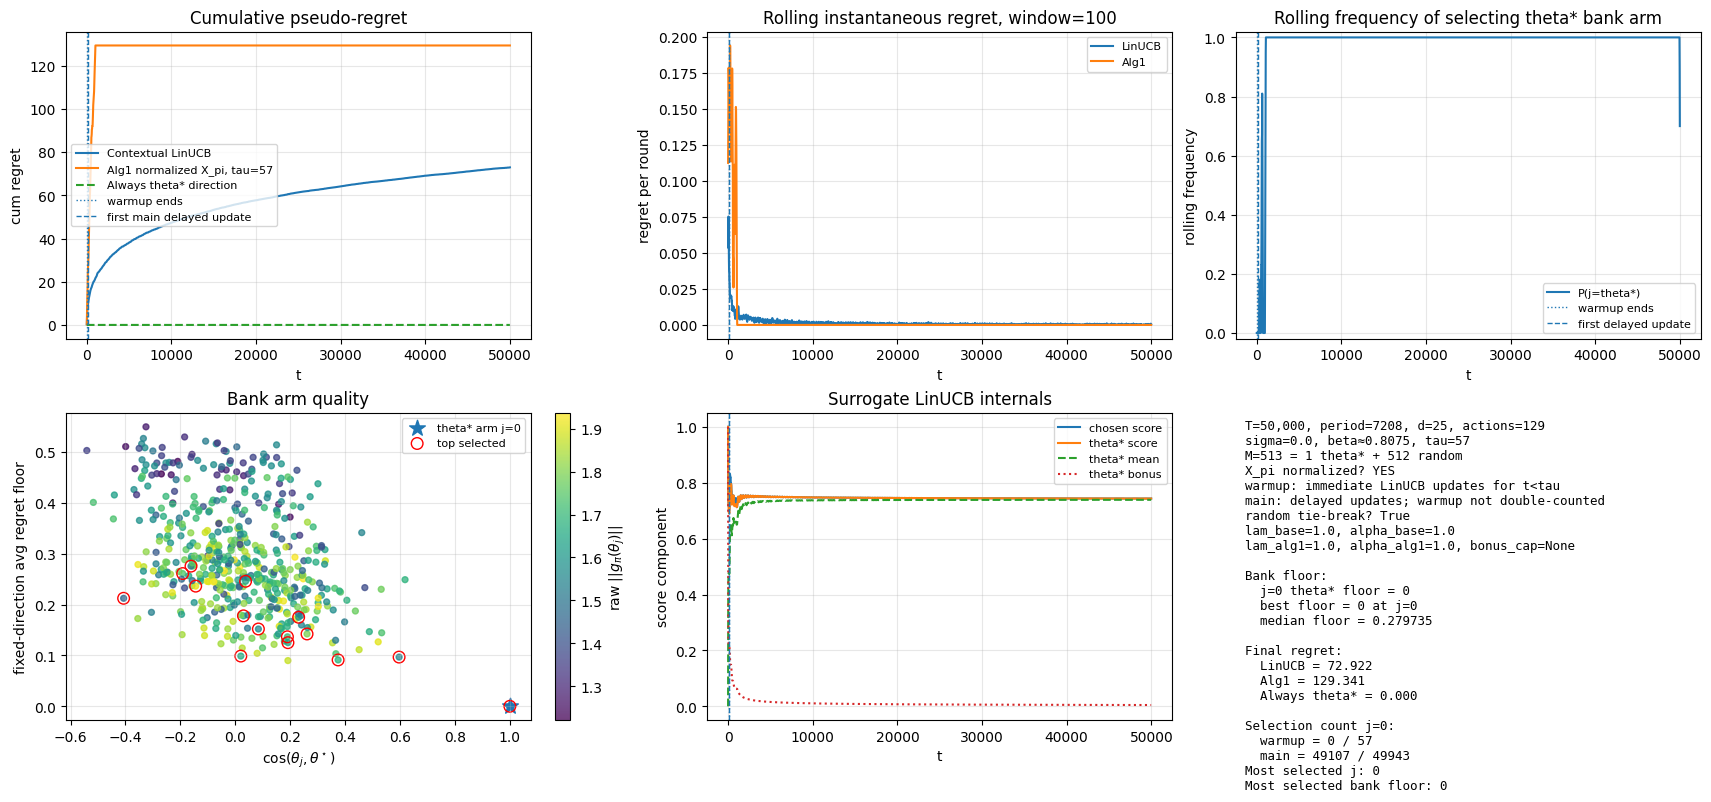

In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ============================================================
# Config
# ============================================================

inst = instance_to_use
T = min(50_000, inst.num_times)
d = inst.feature_dim

SIGMA = 0.0
SEED = 0
BANK_SEED = 123

M_RANDOM = 512
THETA_BATCH = 16

beta_hat = inst.meta["beta_estimation"]["beta_hat_used"]
c_tau = 1.0
tau = int(math.ceil(c_tau * math.log(T) / max(1e-12, 1.0 - beta_hat)))

lam_base = 1.0
alpha_base = 1.0

# Changed from 100 -> 1
lam_alg1 = 1.0
alpha_alg1 = 1.0
bonus_cap = None

RANDOM_TIE_BREAK = True

period_len = int(inst.meta["period_len"])
X_period = np.stack([np.asarray(X, dtype=np.float64) for X in inst.X_by_t[:period_len]], axis=0)
theta_star = np.asarray(inst.theta_star, dtype=np.float64)

R_period = np.einsum("tkd,d->tk", X_period, theta_star, optimize=True)
best_R_period = R_period.max(axis=1)

print(f"T={T}, d={d}, period_len={period_len}, beta={beta_hat:.4f}, tau={tau}")
print(f"reward range: [{R_period.min():.4f}, {R_period.max():.4f}], mean={R_period.mean():.4f}")
print(f"theta_star norm = {np.linalg.norm(theta_star):.4f}")


# ============================================================
# Helpers
# ============================================================

def normalize_vec(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return v / max(np.linalg.norm(v), eps)


def normalize_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=np.float64)
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)


def unit_vecs(rng, n, d):
    X = rng.normal(size=(n, d))
    return normalize_rows(X)


def sherman_morrison(Vinv, x):
    x = np.asarray(x, dtype=np.float64).reshape(-1, 1)
    Vx = Vinv @ x
    denom = float(1.0 + x.T @ Vx)
    return Vinv - (Vx @ Vx.T) / max(1e-12, denom)


def argmax_with_random_tie(scores, rng, tol=1e-12):
    scores = np.asarray(scores, dtype=np.float64)
    mx = np.max(scores)
    candidates = np.flatnonzero(scores >= mx - tol)
    return int(rng.choice(candidates))


class LinUCBContextual:
    def __init__(self, d, lam=1.0, alpha=1.0, rng=None, random_tie_break=True):
        self.Vinv = np.eye(d) / lam
        self.b = np.zeros(d)
        self.alpha = float(alpha)
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.random_tie_break = random_tie_break

    def select_index(self, X_t):
        theta_hat = self.Vinv @ self.b
        means = X_t @ theta_hat
        quad = np.einsum("ij,jk,ik->i", X_t, self.Vinv, X_t, optimize=True)
        scores = means + self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.random_tie_break:
            return argmax_with_random_tie(scores, self.rng)
        return int(np.argmax(scores))

    def update(self, x, r):
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += np.asarray(x, dtype=np.float64) * float(r)


class LinUCBOverFixedSet:
    def __init__(self, X, lam=1.0, alpha=1.0, bonus_cap=None, rng=None, random_tie_break=True):
        self.X = np.asarray(X, dtype=np.float64)
        self.Vinv = np.eye(self.X.shape[1]) / lam
        self.b = np.zeros(self.X.shape[1])
        self.alpha = float(alpha)
        self.bonus_cap = bonus_cap
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.random_tie_break = random_tie_break

    def score_all(self):
        theta_hat = self.Vinv @ self.b
        means = self.X @ theta_hat
        quad = np.einsum("ij,jk,ik->i", self.X, self.Vinv, self.X, optimize=True)
        bonus = self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.bonus_cap is not None:
            bonus = np.minimum(bonus, float(self.bonus_cap))

        return means + bonus, means, bonus

    def select_index(self):
        scores, _, _ = self.score_all()

        if self.random_tie_break:
            return argmax_with_random_tie(scores, self.rng)
        return int(np.argmax(scores))

    def update(self, x, r):
        x = np.asarray(x, dtype=np.float64).reshape(-1)
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += x * float(r)


def build_empirical_g_pi_bank(X_period, theta_bank, batch_size=16, normalize_Xpi=True):
    """
    X_pi[j] = empirical E_{A~pi}[argmax_a <a, theta_j>].
    If normalize_Xpi=True, row-normalize X_pi, matching the synthetic code.
    """
    X_period = np.asarray(X_period, dtype=np.float64)
    theta_bank = np.asarray(theta_bank, dtype=np.float64)

    N, K, d = X_period.shape
    M = theta_bank.shape[0]
    X_pi_raw = np.zeros((M, d), dtype=np.float64)

    for start in tqdm(range(0, M, batch_size), desc="Building X_pi"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)
        selected = X_period[np.arange(N)[:, None], idx]
        X_pi_raw[start:end] = selected.mean(axis=0)

    if normalize_Xpi:
        return normalize_rows(X_pi_raw), X_pi_raw

    return X_pi_raw, X_pi_raw


def bank_floor_regret(X_period, R_period, best_R_period, theta_bank, batch_size=16):
    """
    Average regret of each fixed theta direction if used forever.
    """
    M = theta_bank.shape[0]
    avg_regrets = np.zeros(M)

    for start in tqdm(range(0, M, batch_size), desc="Bank floor"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)

        chosen_rewards = np.take_along_axis(
            R_period[:, :, None],
            idx[:, None, :],
            axis=1,
        )[:, 0, :]

        avg_regrets[start:end] = (best_R_period[:, None] - chosen_rewards).mean(axis=0)

    return avg_regrets


def rolling_mean(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="same")


# ============================================================
# Oracle bank: theta_star direction + random directions
# ============================================================

rng_bank = np.random.default_rng(BANK_SEED)

theta_star_dir = normalize_vec(theta_star)
theta_random = unit_vecs(rng_bank, M_RANDOM, d)

theta_bank = np.vstack([theta_star_dir[None, :], theta_random])
M = len(theta_bank)

cos_to_star = theta_bank @ theta_star_dir

print(f"oracle bank M={M}")
print(f"max cos with theta_star = {cos_to_star.max():.6f}; index={int(np.argmax(cos_to_star))}")

X_pi, X_pi_raw = build_empirical_g_pi_bank(
    X_period,
    theta_bank,
    batch_size=THETA_BATCH,
    normalize_Xpi=True,
)

X_pi_norms = np.linalg.norm(X_pi, axis=1)
X_pi_raw_norms = np.linalg.norm(X_pi_raw, axis=1)

bank_floor = bank_floor_regret(
    X_period,
    R_period,
    best_R_period,
    theta_bank,
    batch_size=THETA_BATCH,
)

bank_diag = pd.DataFrame({
    "j": np.arange(M),
    "cos_to_theta_star": cos_to_star,
    "Xpi_norm_normalized": X_pi_norms,
    "Xpi_norm_raw": X_pi_raw_norms,
    "fixed_theta_avg_regret": bank_floor,
}).sort_values("fixed_theta_avg_regret")

display(bank_diag.head(15).round(6))

print(f"theta_star arm floor regret j=0: {bank_floor[0]:.8f}")
print(f"best bank floor regret: {bank_floor.min():.8f} at j={int(bank_floor.argmin())}")
print(f"median bank floor regret: {np.median(bank_floor):.6f}")


# ============================================================
# Run diagnostic algorithms
# ============================================================

def run_alg1_immediate_warmup_then_delayed(seed=0):
    rng = np.random.default_rng(seed)

    lin = LinUCBContextual(
        d,
        lam=lam_base,
        alpha=alpha_base,
        rng=np.random.default_rng(seed + 10),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    alg1 = LinUCBOverFixedSet(
        X_pi,
        lam=lam_alg1,
        alpha=alpha_alg1,
        bonus_cap=bonus_cap,
        rng=np.random.default_rng(seed + 20),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    # Separate main-phase delayed buffer.
    # Warmup samples are already used immediately and are NOT delayed again.
    delay_len = max(1, tau + 1)
    xbuf = np.zeros((delay_len, d))
    rbuf = np.zeros(delay_len)
    filled_main_sample = np.zeros(delay_len, dtype=bool)

    cum_lin = np.zeros(T)
    cum_alg1 = np.zeros(T)
    cum_star_direction = np.zeros(T)

    chosen_j = np.zeros(T, dtype=int)
    inst_reg_alg1 = np.zeros(T)

    star_score = np.zeros(T)
    chosen_score = np.zeros(T)
    star_mean = np.zeros(T)
    star_bonus = np.zeros(T)

    chosen_mean = np.zeros(T)
    chosen_bonus = np.zeros(T)

    updated_now = np.zeros(T, dtype=bool)
    phase = np.empty(T, dtype=object)

    c_lin = 0.0
    c_alg1 = 0.0
    c_star = 0.0

    for t in tqdm(range(T), desc="Running Alg1: immediate warmup then delayed"):
        p = t % period_len

        X_t = X_period[p]
        mu_t = R_period[p]
        best_mu = best_R_period[p]

        # -------------------------
        # Contextual LinUCB baseline
        # -------------------------
        i_lin = lin.select_index(X_t)
        r_lin = float(mu_t[i_lin] + rng.normal(0.0, SIGMA))
        lin.update(X_t[i_lin], r_lin)

        c_lin += float(best_mu - mu_t[i_lin])
        cum_lin[t] = c_lin

        # -------------------------
        # Always theta_star direction sanity
        # -------------------------
        i_star = int(np.argmax(X_t @ theta_bank[0]))
        c_star += float(best_mu - mu_t[i_star])
        cum_star_direction[t] = c_star

        # -------------------------
        # Alg1 selection
        # -------------------------
        scores, means, bonus = alg1.score_all()
        j = alg1.select_index()

        star_score[t] = scores[0]
        chosen_score[t] = scores[j]
        star_mean[t] = means[0]
        star_bonus[t] = bonus[0]
        chosen_mean[t] = means[j]
        chosen_bonus[t] = bonus[j]

        th = theta_bank[j]
        x_proxy = X_pi[j]

        i = int(np.argmax(X_t @ th))
        r_obs = float(mu_t[i] + rng.normal(0.0, SIGMA))

        # -------------------------
        # Warmup: immediate update
        # -------------------------
        if t < tau:
            phase[t] = "warmup_immediate"
            alg1.update(x_proxy, r_obs)
            updated_now[t] = True

        # -------------------------
        # Main phase: delayed update only
        # -------------------------
        else:
            phase[t] = "main_delayed"

            slot = t % delay_len
            xbuf[slot] = x_proxy
            rbuf[slot] = r_obs
            filled_main_sample[slot] = True

            old_t = t - tau
            old_slot = old_t % delay_len

            # Only update from old_slot if that sample belongs to main phase.
            # This avoids double-counting warmup samples.
            if old_t >= tau and filled_main_sample[old_slot]:
                alg1.update(xbuf[old_slot], rbuf[old_slot])
                updated_now[t] = True

        inst_reg = float(best_mu - mu_t[i])
        c_alg1 += inst_reg
        cum_alg1[t] = c_alg1

        chosen_j[t] = j
        inst_reg_alg1[t] = inst_reg

    return {
        "cum_lin": cum_lin,
        "cum_alg1": cum_alg1,
        "cum_star_direction": cum_star_direction,
        "chosen_j": chosen_j,
        "inst_reg_alg1": inst_reg_alg1,
        "star_score": star_score,
        "chosen_score": chosen_score,
        "star_mean": star_mean,
        "star_bonus": star_bonus,
        "chosen_mean": chosen_mean,
        "chosen_bonus": chosen_bonus,
        "updated_now": updated_now,
        "phase": phase,
    }


out = run_alg1_immediate_warmup_then_delayed(SEED)


# ============================================================
# Summary tables
# ============================================================

summary = pd.DataFrame([
    {
        "method": "Contextual LinUCB",
        "final_cum_regret": out["cum_lin"][-1],
        "avg_regret": out["cum_lin"][-1] / T,
    },
    {
        "method": "Alg1 oracle bank, normalized X_pi, immediate warmup",
        "final_cum_regret": out["cum_alg1"][-1],
        "avg_regret": out["cum_alg1"][-1] / T,
    },
    {
        "method": "Always theta_star direction",
        "final_cum_regret": out["cum_star_direction"][-1],
        "avg_regret": out["cum_star_direction"][-1] / T,
    },
])

display(summary.round(6))


vals, counts = np.unique(out["chosen_j"], return_counts=True)
selected_diag = pd.DataFrame({"j": vals, "count": counts})
selected_diag["freq"] = selected_diag["count"] / T
selected_diag["cos_to_star"] = cos_to_star[selected_diag["j"].to_numpy()]
selected_diag["bank_floor"] = bank_floor[selected_diag["j"].to_numpy()]
selected_diag["Xpi_norm_raw"] = X_pi_raw_norms[selected_diag["j"].to_numpy()]
selected_diag["Xpi_norm_normalized"] = X_pi_norms[selected_diag["j"].to_numpy()]
selected_diag = selected_diag.sort_values("count", ascending=False)

display(selected_diag.head(20).round(6))


# Warmup-specific diagnostic
warmup_selected = out["chosen_j"][:tau]
main_selected = out["chosen_j"][tau:]

warmup_diag = pd.DataFrame([{
    "tau": tau,
    "warmup_j0_count": int(np.sum(warmup_selected == 0)),
    "warmup_unique_arms": int(len(np.unique(warmup_selected))),
    "main_j0_count": int(np.sum(main_selected == 0)),
    "main_unique_arms": int(len(np.unique(main_selected))),
    "updates_total": int(np.sum(out["updated_now"])),
}])

display(warmup_diag)


# ============================================================
# Dense plots
# ============================================================

plot_step = max(1, T // 2500)
idx = np.arange(0, T, plot_step)
t_axis = idx + 1

w = max(50, T // 500)

star_selected_roll = rolling_mean((out["chosen_j"] == 0).astype(float), w)
inst_reg_lin = np.diff(np.r_[0, out["cum_lin"]])

fig, axes = plt.subplots(2, 3, figsize=(17, 8), constrained_layout=True)

# 1. Cumulative regret
ax = axes[0, 0]
ax.plot(t_axis, out["cum_lin"][idx], label="Contextual LinUCB")
ax.plot(t_axis, out["cum_alg1"][idx], label=f"Alg1 normalized X_pi, tau={tau}")
ax.plot(t_axis, out["cum_star_direction"][idx], "--", label="Always theta* direction")
ax.axvline(tau, linestyle=":", linewidth=1, label="warmup ends")
ax.axvline(2 * tau, linestyle="--", linewidth=1, label="first main delayed update")
ax.set_title("Cumulative pseudo-regret")
ax.set_xlabel("t")
ax.set_ylabel("cum regret")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 2. Rolling instantaneous regret
ax = axes[0, 1]
ax.plot(t_axis, rolling_mean(inst_reg_lin, w)[idx], label="LinUCB")
ax.plot(t_axis, rolling_mean(out["inst_reg_alg1"], w)[idx], label="Alg1")
ax.axvline(tau, linestyle=":", linewidth=1)
ax.axvline(2 * tau, linestyle="--", linewidth=1)
ax.set_title(f"Rolling instantaneous regret, window={w}")
ax.set_xlabel("t")
ax.set_ylabel("regret per round")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 3. Frequency of selecting theta_star arm
ax = axes[0, 2]
ax.plot(t_axis, star_selected_roll[idx], label="P(j=theta*)")
ax.axvline(tau, linestyle=":", linewidth=1, label="warmup ends")
ax.axvline(2 * tau, linestyle="--", linewidth=1, label="first delayed update")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Rolling frequency of selecting theta* bank arm")
ax.set_xlabel("t")
ax.set_ylabel("rolling frequency")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 4. Bank arm quality
ax = axes[1, 0]
sc = ax.scatter(
    cos_to_star,
    bank_floor,
    c=X_pi_raw_norms,
    s=18,
    alpha=0.75,
)
ax.scatter([cos_to_star[0]], [bank_floor[0]], s=140, marker="*", label="theta* arm j=0")

top_selected = selected_diag.head(15)["j"].to_numpy(dtype=int)
ax.scatter(
    cos_to_star[top_selected],
    bank_floor[top_selected],
    s=70,
    facecolors="none",
    edgecolors="red",
    label="top selected",
)
ax.set_title("Bank arm quality")
ax.set_xlabel(r"cos($\theta_j,\theta^\star$)")
ax.set_ylabel("fixed-direction avg regret floor")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"raw $||g_\pi(\theta_j)||$")

# 5. UCB internals
ax = axes[1, 1]
ax.plot(t_axis, out["chosen_score"][idx], label="chosen score")
ax.plot(t_axis, out["star_score"][idx], label="theta* score")
ax.plot(t_axis, out["star_mean"][idx], "--", label="theta* mean")
ax.plot(t_axis, out["star_bonus"][idx], ":", label="theta* bonus")
ax.axvline(tau, linestyle=":", linewidth=1)
ax.axvline(2 * tau, linestyle="--", linewidth=1)
ax.set_title("Surrogate LinUCB internals")
ax.set_xlabel("t")
ax.set_ylabel("score component")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 6. Text card
ax = axes[1, 2]
ax.axis("off")
text = (
    f"T={T:,}, period={period_len}, d={d}, actions=129\n"
    f"sigma={SIGMA}, beta≈{beta_hat:.4f}, tau={tau}\n"
    f"M={M} = 1 theta* + {M_RANDOM} random\n"
    f"X_pi normalized? YES\n"
    f"warmup: immediate LinUCB updates for t<tau\n"
    f"main: delayed updates; warmup not double-counted\n"
    f"random tie-break? {RANDOM_TIE_BREAK}\n"
    f"lam_base={lam_base}, alpha_base={alpha_base}\n"
    f"lam_alg1={lam_alg1}, alpha_alg1={alpha_alg1}, bonus_cap={bonus_cap}\n\n"
    f"Bank floor:\n"
    f"  j=0 theta* floor = {bank_floor[0]:.6g}\n"
    f"  best floor = {bank_floor.min():.6g} at j={int(bank_floor.argmin())}\n"
    f"  median floor = {np.median(bank_floor):.6g}\n\n"
    f"Final regret:\n"
    f"  LinUCB = {out['cum_lin'][-1]:.3f}\n"
    f"  Alg1 = {out['cum_alg1'][-1]:.3f}\n"
    f"  Always theta* = {out['cum_star_direction'][-1]:.3f}\n\n"
    f"Selection count j=0:\n"
    f"  warmup = {int(np.sum(warmup_selected == 0))} / {tau}\n"
    f"  main = {int(np.sum(main_selected == 0))} / {len(main_selected)}\n"
    f"Most selected j: {int(selected_diag.iloc[0]['j'])}\n"
    f"Most selected bank floor: {selected_diag.iloc[0]['bank_floor']:.6g}"
)
ax.text(0.02, 0.98, text, va="top", ha="left", family="monospace", fontsize=9)

plt.show()

[info] T=200000, d=25, beta_hat=0.807548, c_tau=1.0, tau=64
[info] period_len=7208, X_period.shape=(7208, 129, 25)
[info] reward range: min=0.0987, max=1.0369, mean=0.4916
[info] theta_star norm=1.2993
[info] random bank shape: (128, 25)
[info] oracle bank shape: (129, 25)
[bank] random max cosine with theta_star: 0.5966
[bank] oracle max cosine with theta_star: 1.0000


Building X_pi:   0%|          | 0/8 [00:00<?, ?it/s]

Building X_pi:   0%|          | 0/9 [00:00<?, ?it/s]

[info] X_pi built and normalized.
X_pi_random raw norms: min=1.230, max=1.930
X_pi_oracle raw norms: min=1.230, max=1.930


Bank floor:   0%|          | 0/8 [00:00<?, ?it/s]

...

Alg1 oracle bank seed=0:   0%|          | 0/200000 [00:00<?, ?it/s]

Alg1 random bank seed=0:   0%|          | 0/200000 [00:00<?, ?it/s]

,method,final_mean,final_se,avg_regret
0,Contextual LinUCB,98.507548,0.0,0.000493
1,Alg1 oracle bank,184.229643,0.0,0.000921
2,Alg1 random bank,19547.030951,0.0,0.097735


[info] Saved trajectories: results_csv/real_cyclic5s_T200000_N1_alg1_normXpi_immediateWarmup.csv
[info] Saved summary: results_csv/real_cyclic5s_summary_T200000_N1_alg1_normXpi_immediateWarmup.csv


,algorithm,special_arm,special_arm_count_total,special_arm_count_warmup,special_arm_count_main,special_arm_frequency,floor_of_special_arm
0,Alg1 oracle bank,theta_star j=0,198944,0,198944,0.994720,0.000000
1,Alg1 random bank,best random j=60,197095,0,197095,0.985475,0.096759


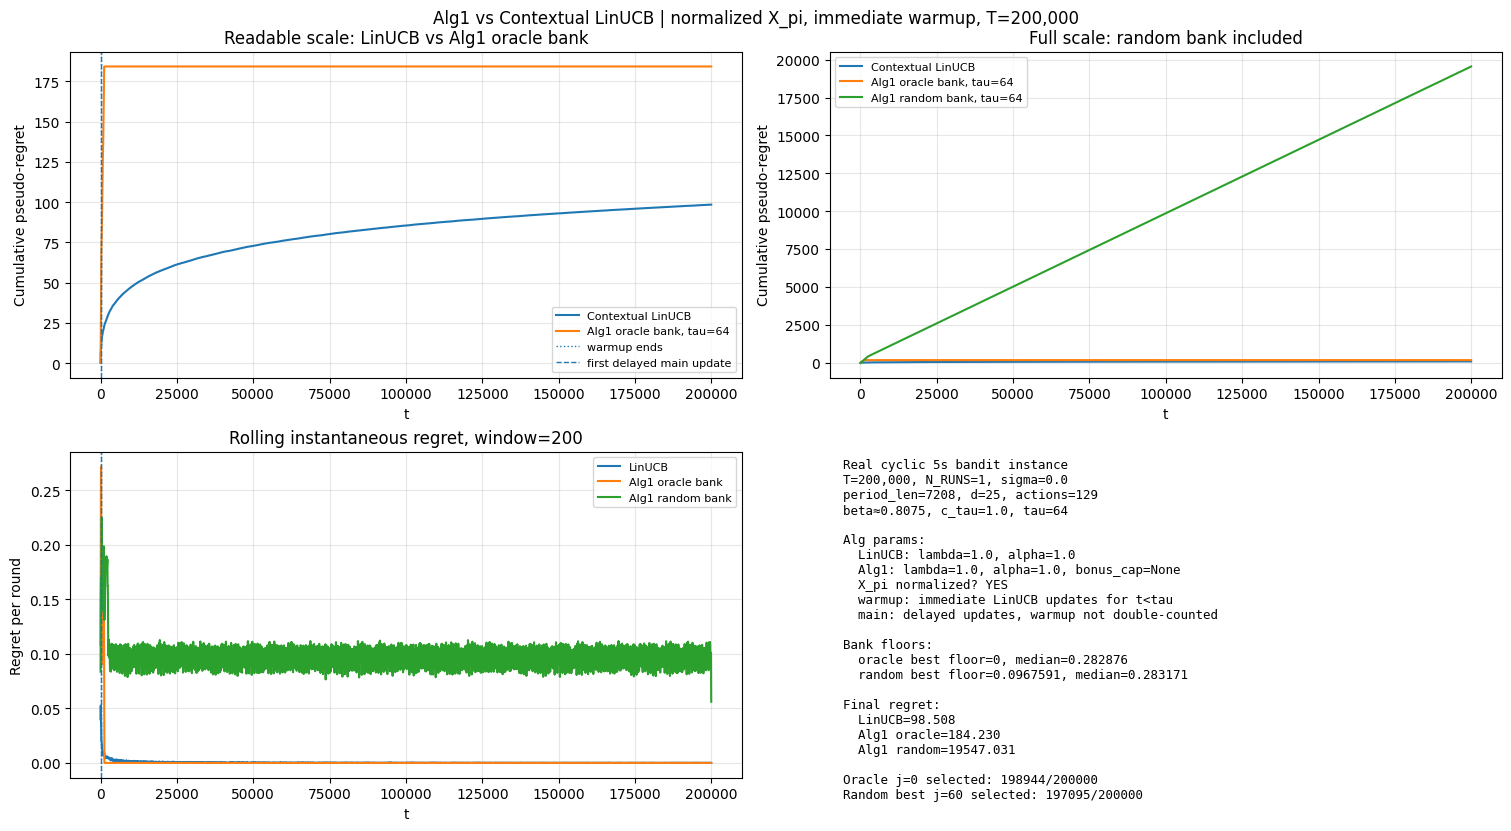

[info] Saved plot: result/real_cyclic5s_T200000_N1_alg1_normXpi_immediateWarmup.png


In [12]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm


# ============================================================
# Config
# ============================================================

inst = instance_to_use  # cyclic_instance_5s

T = min(200_000, inst.num_times)
d = inst.feature_dim

SIGMA = 0.0
N_RUNS = 1
ALG_SEED0 = 0
BANK_SEED = 123

M_RANDOM = 128
THETA_BATCH = 16

beta_hat = inst.meta["beta_estimation"]["beta_hat_used"]
c_tau = 1.0
tau = int(math.ceil(c_tau * math.log(T) / max(1e-12, 1.0 - beta_hat)))

print(f"[info] T={T}, d={d}, beta_hat={beta_hat:.6f}, c_tau={c_tau}, tau={tau}")

# Contextual LinUCB baseline
lam_base = 1.0
alpha_base = 1.0

# Algorithm 1 surrogate LinUCB
lam_alg1 = 1.0
alpha_alg1 = 1.0
bonus_cap = None

RANDOM_TIE_BREAK = True

period_len = int(inst.meta["period_len"])
X_period = np.stack([np.asarray(X, dtype=np.float64) for X in inst.X_by_t[:period_len]], axis=0)
theta_star = np.asarray(inst.theta_star, dtype=np.float64)

R_period = np.einsum("tkd,d->tk", X_period, theta_star, optimize=True)
best_R_period = R_period.max(axis=1)

print(f"[info] period_len={period_len}, X_period.shape={X_period.shape}")
print(f"[info] reward range: min={R_period.min():.4f}, max={R_period.max():.4f}, mean={R_period.mean():.4f}")
print(f"[info] theta_star norm={np.linalg.norm(theta_star):.4f}")

os.makedirs("results_csv", exist_ok=True)
os.makedirs("result", exist_ok=True)


# ============================================================
# Helpers
# ============================================================

def normalize_vec(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return v / max(np.linalg.norm(v), eps)


def normalize_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=np.float64)
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)


def unit_vecs(rng, n, d):
    X = rng.normal(size=(n, d))
    return normalize_rows(X)


def sherman_morrison(Vinv, x):
    x = np.asarray(x, dtype=np.float64).reshape(-1, 1)
    Vx = Vinv @ x
    denom = float(1.0 + x.T @ Vx)
    return Vinv - (Vx @ Vx.T) / max(1e-12, denom)


def argmax_with_random_tie(scores, rng, tol=1e-12):
    scores = np.asarray(scores, dtype=np.float64)
    mx = np.max(scores)
    candidates = np.flatnonzero(scores >= mx - tol)
    return int(rng.choice(candidates))


def rolling_mean(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="same")


class LinUCBContextual:
    def __init__(self, d, lam=1.0, alpha=1.0, rng=None, random_tie_break=True):
        self.Vinv = np.eye(d) / lam
        self.b = np.zeros(d)
        self.alpha = float(alpha)
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.random_tie_break = random_tie_break

    def select_index(self, X_t):
        theta_hat = self.Vinv @ self.b
        means = X_t @ theta_hat
        quad = np.einsum("ij,jk,ik->i", X_t, self.Vinv, X_t, optimize=True)
        scores = means + self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.random_tie_break:
            return argmax_with_random_tie(scores, self.rng)
        return int(np.argmax(scores))

    def update(self, x, r):
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += np.asarray(x, dtype=np.float64) * float(r)


class LinUCBOverFixedSet:
    def __init__(self, X, lam=1.0, alpha=1.0, bonus_cap=None, rng=None, random_tie_break=True):
        self.X = np.asarray(X, dtype=np.float64)
        self.Vinv = np.eye(self.X.shape[1]) / lam
        self.b = np.zeros(self.X.shape[1])
        self.alpha = float(alpha)
        self.bonus_cap = bonus_cap
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.random_tie_break = random_tie_break

    def score_all(self):
        theta_hat = self.Vinv @ self.b
        means = self.X @ theta_hat
        quad = np.einsum("ij,jk,ik->i", self.X, self.Vinv, self.X, optimize=True)
        bonus = self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.bonus_cap is not None:
            bonus = np.minimum(bonus, float(self.bonus_cap))

        return means + bonus, means, bonus

    def select_index(self):
        scores, _, _ = self.score_all()

        if self.random_tie_break:
            return argmax_with_random_tie(scores, self.rng)
        return int(np.argmax(scores))

    def update(self, x, r):
        x = np.asarray(x, dtype=np.float64).reshape(-1)
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += x * float(r)


def build_empirical_g_pi_bank(X_period, theta_bank, batch_size=16, normalize_Xpi=True):
    """
    X_pi[j] = empirical E_{A~pi}[argmax_a <a, theta_j>].
    Here we normalize X_pi rows, matching the synthetic implementation.
    """
    X_period = np.asarray(X_period, dtype=np.float64)
    theta_bank = np.asarray(theta_bank, dtype=np.float64)

    N, K, d = X_period.shape
    M = theta_bank.shape[0]
    X_pi_raw = np.zeros((M, d), dtype=np.float64)

    for start in tqdm(range(0, M, batch_size), desc="Building X_pi"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)
        selected = X_period[np.arange(N)[:, None], idx]
        X_pi_raw[start:end] = selected.mean(axis=0)

    if normalize_Xpi:
        return normalize_rows(X_pi_raw), X_pi_raw

    return X_pi_raw, X_pi_raw


def bank_floor_regret(X_period, R_period, best_R_period, theta_bank, batch_size=16):
    M = theta_bank.shape[0]
    avg_regrets = np.zeros(M)

    for start in tqdm(range(0, M, batch_size), desc="Bank floor"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)

        chosen_rewards = np.take_along_axis(
            R_period[:, :, None],
            idx[:, None, :],
            axis=1,
        )[:, 0, :]

        avg_regrets[start:end] = (best_R_period[:, None] - chosen_rewards).mean(axis=0)

    best_j = int(np.argmin(avg_regrets))
    return {
        "best_index": best_j,
        "best_avg_regret": float(avg_regrets[best_j]),
        "median_avg_regret": float(np.median(avg_regrets)),
        "mean_avg_regret": float(np.mean(avg_regrets)),
        "avg_regrets": avg_regrets,
    }


# ============================================================
# Build theta banks
# ============================================================

rng_bank = np.random.default_rng(BANK_SEED)

theta_star_dir = normalize_vec(theta_star)
theta_random = unit_vecs(rng_bank, M_RANDOM, d)

theta_bank_random = theta_random.copy()
theta_bank_oracle = np.vstack([theta_star_dir[None, :], theta_random])

cos_random = theta_bank_random @ theta_star_dir
cos_oracle = theta_bank_oracle @ theta_star_dir

print(f"[info] random bank shape: {theta_bank_random.shape}")
print(f"[info] oracle bank shape: {theta_bank_oracle.shape}")
print(f"[bank] random max cosine with theta_star: {cos_random.max():.4f}")
print(f"[bank] oracle max cosine with theta_star: {cos_oracle.max():.4f}")


# ============================================================
# Build normalized X_pi for both banks
# ============================================================

X_pi_random, X_pi_random_raw = build_empirical_g_pi_bank(
    X_period,
    theta_bank_random,
    batch_size=THETA_BATCH,
    normalize_Xpi=True,
)

X_pi_oracle, X_pi_oracle_raw = build_empirical_g_pi_bank(
    X_period,
    theta_bank_oracle,
    batch_size=THETA_BATCH,
    normalize_Xpi=True,
)

print("[info] X_pi built and normalized.")
print(
    f"X_pi_random raw norms: "
    f"min={np.linalg.norm(X_pi_random_raw, axis=1).min():.3f}, "
    f"max={np.linalg.norm(X_pi_random_raw, axis=1).max():.3f}"
)
print(
    f"X_pi_oracle raw norms: "
    f"min={np.linalg.norm(X_pi_oracle_raw, axis=1).min():.3f}, "
    f"max={np.linalg.norm(X_pi_oracle_raw, axis=1).max():.3f}"
)


# ============================================================
# Bank approximation diagnostics
# ============================================================

floor_random = bank_floor_regret(
    X_period,
    R_period,
    best_R_period,
    theta_bank_random,
    batch_size=THETA_BATCH,
)

floor_oracle = bank_floor_regret(
    X_period,
    R_period,
    best_R_period,
    theta_bank_oracle,
    batch_size=THETA_BATCH,
)

bank_diag_df = pd.DataFrame([
    {
        "bank": "oracle",
        "M": len(theta_bank_oracle),
        "max_cos_theta_star": cos_oracle.max(),
        "best_avg_regret_floor": floor_oracle["best_avg_regret"],
        "median_avg_regret": floor_oracle["median_avg_regret"],
        "mean_avg_regret": floor_oracle["mean_avg_regret"],
        "best_index": floor_oracle["best_index"],
    },
    {
        "bank": "random",
        "M": len(theta_bank_random),
        "max_cos_theta_star": cos_random.max(),
        "best_avg_regret_floor": floor_random["best_avg_regret"],
        "median_avg_regret": floor_random["median_avg_regret"],
        "mean_avg_regret": floor_random["mean_avg_regret"],
        "best_index": floor_random["best_index"],
    },
])

display(bank_diag_df.round(6))


# ============================================================
# Single run: LinUCB + Alg1 oracle bank + Alg1 random bank
# ============================================================

def run_alg1_immediate_warmup_then_delayed(
    alg1,
    theta_bank,
    X_pi,
    seed,
    label,
):
    rng = np.random.default_rng(seed)

    delay_len = max(1, tau + 1)
    xbuf = np.zeros((delay_len, d))
    rbuf = np.zeros(delay_len)
    filled_main_sample = np.zeros(delay_len, dtype=bool)

    cum_regret = np.zeros(T, dtype=np.float64)
    inst_regret = np.zeros(T, dtype=np.float64)
    chosen_j = np.zeros(T, dtype=int)

    c = 0.0

    for t in tqdm(range(T), desc=label, leave=False):
        p = t % period_len

        X_t = X_period[p]
        mu_t = R_period[p]
        best_mu = best_R_period[p]

        j = alg1.select_index()

        th = theta_bank[j]
        x_proxy = X_pi[j]

        i = int(np.argmax(X_t @ th))
        r_obs = float(mu_t[i] + rng.normal(0.0, SIGMA))

        if t < tau:
            # Immediate warmup update. Not put into delayed main buffer.
            alg1.update(x_proxy, r_obs)
        else:
            # Main phase: delayed update from main-phase samples only.
            slot = t % delay_len
            xbuf[slot] = x_proxy
            rbuf[slot] = r_obs
            filled_main_sample[slot] = True

            old_t = t - tau
            old_slot = old_t % delay_len

            if old_t >= tau and filled_main_sample[old_slot]:
                alg1.update(xbuf[old_slot], rbuf[old_slot])

        reg = float(best_mu - mu_t[i])
        c += reg

        inst_regret[t] = reg
        cum_regret[t] = c
        chosen_j[t] = j

    return cum_regret, inst_regret, chosen_j


def run_once_real_instance(alg_seed):
    rng = np.random.default_rng(alg_seed)

    lin = LinUCBContextual(
        d,
        lam=lam_base,
        alpha=alpha_base,
        rng=np.random.default_rng(alg_seed + 10),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    alg1_oracle = LinUCBOverFixedSet(
        X_pi_oracle,
        lam=lam_alg1,
        alpha=alpha_alg1,
        bonus_cap=bonus_cap,
        rng=np.random.default_rng(alg_seed + 20),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    alg1_random = LinUCBOverFixedSet(
        X_pi_random,
        lam=lam_alg1,
        alpha=alpha_alg1,
        bonus_cap=bonus_cap,
        rng=np.random.default_rng(alg_seed + 30),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    cum_lin = np.zeros(T, dtype=np.float64)
    inst_lin = np.zeros(T, dtype=np.float64)

    c_lin = 0.0

    for t in tqdm(range(T), desc=f"Contextual LinUCB seed={alg_seed}", leave=False):
        p = t % period_len

        X_t = X_period[p]
        mu_t = R_period[p]
        best_mu = best_R_period[p]

        i_lin = lin.select_index(X_t)
        r_lin_obs = float(mu_t[i_lin] + rng.normal(0.0, SIGMA))
        lin.update(X_t[i_lin], r_lin_obs)

        reg = float(best_mu - mu_t[i_lin])
        c_lin += reg

        inst_lin[t] = reg
        cum_lin[t] = c_lin

    cum_oracle, inst_oracle, chosen_oracle = run_alg1_immediate_warmup_then_delayed(
        alg1=alg1_oracle,
        theta_bank=theta_bank_oracle,
        X_pi=X_pi_oracle,
        seed=alg_seed + 100,
        label=f"Alg1 oracle bank seed={alg_seed}",
    )

    cum_random, inst_random, chosen_random = run_alg1_immediate_warmup_then_delayed(
        alg1=alg1_random,
        theta_bank=theta_bank_random,
        X_pi=X_pi_random,
        seed=alg_seed + 200,
        label=f"Alg1 random bank seed={alg_seed}",
    )

    return {
        "cum_lin": cum_lin,
        "cum_oracle": cum_oracle,
        "cum_random": cum_random,
        "inst_lin": inst_lin,
        "inst_oracle": inst_oracle,
        "inst_random": inst_random,
        "chosen_oracle": chosen_oracle,
        "chosen_random": chosen_random,
    }


# ============================================================
# Run
# ============================================================

all_runs = []

for run in range(N_RUNS):
    seed = ALG_SEED0 + run
    print(f"Run {run + 1}/{N_RUNS} | seed={seed}")
    all_runs.append(run_once_real_instance(seed))

lin_mat = np.stack([r["cum_lin"] for r in all_runs], axis=0)
oracle_mat = np.stack([r["cum_oracle"] for r in all_runs], axis=0)
random_mat = np.stack([r["cum_random"] for r in all_runs], axis=0)

mean_lin = lin_mat.mean(axis=0)
mean_oracle = oracle_mat.mean(axis=0)
mean_random = random_mat.mean(axis=0)

se_lin = lin_mat.std(axis=0, ddof=1) / np.sqrt(N_RUNS) if N_RUNS > 1 else np.zeros(T)
se_oracle = oracle_mat.std(axis=0, ddof=1) / np.sqrt(N_RUNS) if N_RUNS > 1 else np.zeros(T)
se_random = random_mat.std(axis=0, ddof=1) / np.sqrt(N_RUNS) if N_RUNS > 1 else np.zeros(T)

summary_df = pd.DataFrame([
    {
        "method": "Contextual LinUCB",
        "final_mean": mean_lin[-1],
        "final_se": se_lin[-1],
        "avg_regret": mean_lin[-1] / T,
    },
    {
        "method": "Alg1 oracle bank",
        "final_mean": mean_oracle[-1],
        "final_se": se_oracle[-1],
        "avg_regret": mean_oracle[-1] / T,
    },
    {
        "method": "Alg1 random bank",
        "final_mean": mean_random[-1],
        "final_se": se_random[-1],
        "avg_regret": mean_random[-1] / T,
    },
])

display(summary_df.round(6))


# ============================================================
# Save trajectories and summary
# ============================================================

traj_path = f"results_csv/real_cyclic5s_T{T}_N{N_RUNS}_alg1_normXpi_immediateWarmup.csv"
summary_path = f"results_csv/real_cyclic5s_summary_T{T}_N{N_RUNS}_alg1_normXpi_immediateWarmup.csv"

df_traj = pd.DataFrame({
    "t": np.arange(1, T + 1),
    "cum_regret_linucb": mean_lin,
    "cum_regret_alg1_oracle_bank": mean_oracle,
    "cum_regret_alg1_random_bank": mean_random,
})

df_traj.to_csv(traj_path, index=False)
summary_df.to_csv(summary_path, index=False)

print(f"[info] Saved trajectories: {traj_path}")
print(f"[info] Saved summary: {summary_path}")


# ============================================================
# Diagnostics for chosen arms
# ============================================================

chosen_oracle = all_runs[0]["chosen_oracle"]
chosen_random = all_runs[0]["chosen_random"]

oracle_j0_count = int(np.sum(chosen_oracle == 0))
oracle_j0_warm = int(np.sum(chosen_oracle[:tau] == 0))
oracle_j0_main = int(np.sum(chosen_oracle[tau:] == 0))

random_best_j = int(floor_random["best_index"])
random_best_count = int(np.sum(chosen_random == random_best_j))

selected_diag_df = pd.DataFrame([
    {
        "algorithm": "Alg1 oracle bank",
        "special_arm": "theta_star j=0",
        "special_arm_count_total": oracle_j0_count,
        "special_arm_count_warmup": oracle_j0_warm,
        "special_arm_count_main": oracle_j0_main,
        "special_arm_frequency": oracle_j0_count / T,
        "floor_of_special_arm": floor_oracle["avg_regrets"][0],
    },
    {
        "algorithm": "Alg1 random bank",
        "special_arm": f"best random j={random_best_j}",
        "special_arm_count_total": random_best_count,
        "special_arm_count_warmup": int(np.sum(chosen_random[:tau] == random_best_j)),
        "special_arm_count_main": int(np.sum(chosen_random[tau:] == random_best_j)),
        "special_arm_frequency": random_best_count / T,
        "floor_of_special_arm": floor_random["avg_regrets"][random_best_j],
    },
])

display(selected_diag_df.round(6))


# ============================================================
# Plot: left readable scale, right full scale including random bank
# ============================================================

plot_step = max(1, T // 3000)
idx = np.arange(0, T, plot_step)
t_axis = idx + 1

w = max(100, T // 1000)

inst_lin = all_runs[0]["inst_lin"]
inst_oracle = all_runs[0]["inst_oracle"]
inst_random = all_runs[0]["inst_random"]

fig, axes = plt.subplots(2, 2, figsize=(15, 8), constrained_layout=True)

# Left top: LinUCB vs oracle bank
ax = axes[0, 0]
ax.plot(t_axis, mean_lin[idx], label="Contextual LinUCB")
ax.plot(t_axis, mean_oracle[idx], label=f"Alg1 oracle bank, tau={tau}")
ax.fill_between(t_axis, np.maximum(0.0, mean_lin[idx] - se_lin[idx]), mean_lin[idx] + se_lin[idx], alpha=0.15)
ax.fill_between(t_axis, np.maximum(0.0, mean_oracle[idx] - se_oracle[idx]), mean_oracle[idx] + se_oracle[idx], alpha=0.15)
ax.axvline(tau, linestyle=":", linewidth=1, label="warmup ends")
ax.axvline(2 * tau, linestyle="--", linewidth=1, label="first delayed main update")
ax.set_title("Readable scale: LinUCB vs Alg1 oracle bank")
ax.set_xlabel("t")
ax.set_ylabel("Cumulative pseudo-regret")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Right top: full scale
ax = axes[0, 1]
ax.plot(t_axis, mean_lin[idx], label="Contextual LinUCB")
ax.plot(t_axis, mean_oracle[idx], label=f"Alg1 oracle bank, tau={tau}")
ax.plot(t_axis, mean_random[idx], label=f"Alg1 random bank, tau={tau}")
ax.set_title("Full scale: random bank included")
ax.set_xlabel("t")
ax.set_ylabel("Cumulative pseudo-regret")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Left bottom: rolling instantaneous regret
ax = axes[1, 0]
ax.plot(t_axis, rolling_mean(inst_lin, w)[idx], label="LinUCB")
ax.plot(t_axis, rolling_mean(inst_oracle, w)[idx], label="Alg1 oracle bank")
ax.plot(t_axis, rolling_mean(inst_random, w)[idx], label="Alg1 random bank")
ax.axvline(tau, linestyle=":", linewidth=1)
ax.axvline(2 * tau, linestyle="--", linewidth=1)
ax.set_title(f"Rolling instantaneous regret, window={w}")
ax.set_xlabel("t")
ax.set_ylabel("Regret per round")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Right bottom: text card
ax = axes[1, 1]
ax.axis("off")
text = (
    f"Real cyclic 5s bandit instance\n"
    f"T={T:,}, N_RUNS={N_RUNS}, sigma={SIGMA}\n"
    f"period_len={period_len}, d={d}, actions=129\n"
    f"beta≈{beta_hat:.4f}, c_tau={c_tau}, tau={tau}\n\n"
    f"Alg params:\n"
    f"  LinUCB: lambda={lam_base}, alpha={alpha_base}\n"
    f"  Alg1: lambda={lam_alg1}, alpha={alpha_alg1}, bonus_cap={bonus_cap}\n"
    f"  X_pi normalized? YES\n"
    f"  warmup: immediate LinUCB updates for t<tau\n"
    f"  main: delayed updates, warmup not double-counted\n\n"
    f"Bank floors:\n"
    f"  oracle best floor={floor_oracle['best_avg_regret']:.6g}, median={floor_oracle['median_avg_regret']:.6g}\n"
    f"  random best floor={floor_random['best_avg_regret']:.6g}, median={floor_random['median_avg_regret']:.6g}\n\n"
    f"Final regret:\n"
    f"  LinUCB={mean_lin[-1]:.3f}\n"
    f"  Alg1 oracle={mean_oracle[-1]:.3f}\n"
    f"  Alg1 random={mean_random[-1]:.3f}\n\n"
    f"Oracle j=0 selected: {oracle_j0_count}/{T}\n"
    f"Random best j={random_best_j} selected: {random_best_count}/{T}"
)
ax.text(0.02, 0.98, text, va="top", ha="left", family="monospace", fontsize=9)

fig.suptitle(
    f"Alg1 vs Contextual LinUCB | normalized X_pi, immediate warmup, T={T:,}",
    y=1.02,
)

plot_path = f"result/real_cyclic5s_T{T}_N{N_RUNS}_alg1_normXpi_immediateWarmup.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[info] Saved plot: {plot_path}")

[info] T=200000, d=25, period_len=7208
[info] beta_hat=0.807548, c_tau=1.0, tau=64
[info] reward range: min=0.0987, max=1.0369, mean=0.4916
[info] theta_star norm=1.2993
[cache] d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\cache\oracle_bank_normXpi_Mrandom512_seed123_period7208_d25_theta4538309.npz
[cache] not found; building oracle bank


Building X_pi:   0%|          | 0/33 [00:00<?, ?it/s]

Bank floor:   0%|          | 0/33 [00:00<?, ?it/s]

[cache] saved to d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\cache\oracle_bank_normXpi_Mrandom512_seed123_period7208_d25_theta4538309.npz


,j,cos_to_theta_star,Xpi_norm,Xpi_raw_norm,fixed_theta_avg_regret
0,0,1.000000,1.0,1.610606,0.000000
496,496,0.191692,1.0,1.872652,0.089893
488,488,0.374491,1.0,1.683908,0.091123
61,61,0.596574,1.0,1.546773,0.096759
372,372,0.020167,1.0,1.655507,0.098755
105,105,0.366372,1.0,1.727595,0.103365
378,378,0.079691,1.0,1.875725,0.104216
131,131,0.451016,1.0,1.867981,0.111349
382,382,0.025279,1.0,1.850433,0.114623
71,71,0.099224,1.0,1.740202,0.114914


...

Alg1 oracle bank seed=4:   0%|          | 0/200000 [00:00<?, ?it/s]

,method,runs,final_mean,final_se,avg_regret
0,Contextual LinUCB,1,98.507548,0.000000,0.000493
1,Alg1 oracle bank,5,182.240162,16.335133,0.000911


,j,count,freq,cos_to_star,bank_floor,Xpi_raw_norm
0,0,199173,0.995865,1.000000,0.000000,1.610606
44,488,273,0.001365,0.374491,0.091123,1.683908
5,37,70,0.000350,0.437385,0.187363,1.769370
1,2,69,0.000345,-0.191571,0.260991,1.736116
17,163,68,0.000340,-0.041410,0.193038,1.830375
34,372,66,0.000330,0.020167,0.098755,1.655507
19,196,41,0.000205,0.201661,0.166804,1.508418
2,11,41,0.000205,0.168323,0.152467,1.681393
47,496,36,0.000180,0.191692,0.089893,1.872652
25,295,35,0.000175,0.398104,0.165964,1.525601


,run,j0_total,j0_warmup,j0_main,j0_freq
0,0,199173,0,199173,0.995865
1,1,198604,0,198604,0.993020
2,2,198981,0,198981,0.994905
3,3,198328,0,198328,0.991640
4,4,198549,0,198549,0.992745


[info] Saved trajectories: results_csv/real_cyclic5s_T200000_baseline1_alg15_oracleOnly_normXpi.csv
[info] Saved summary: results_csv/real_cyclic5s_summary_T200000_baseline1_alg15_oracleOnly_normXpi.csv


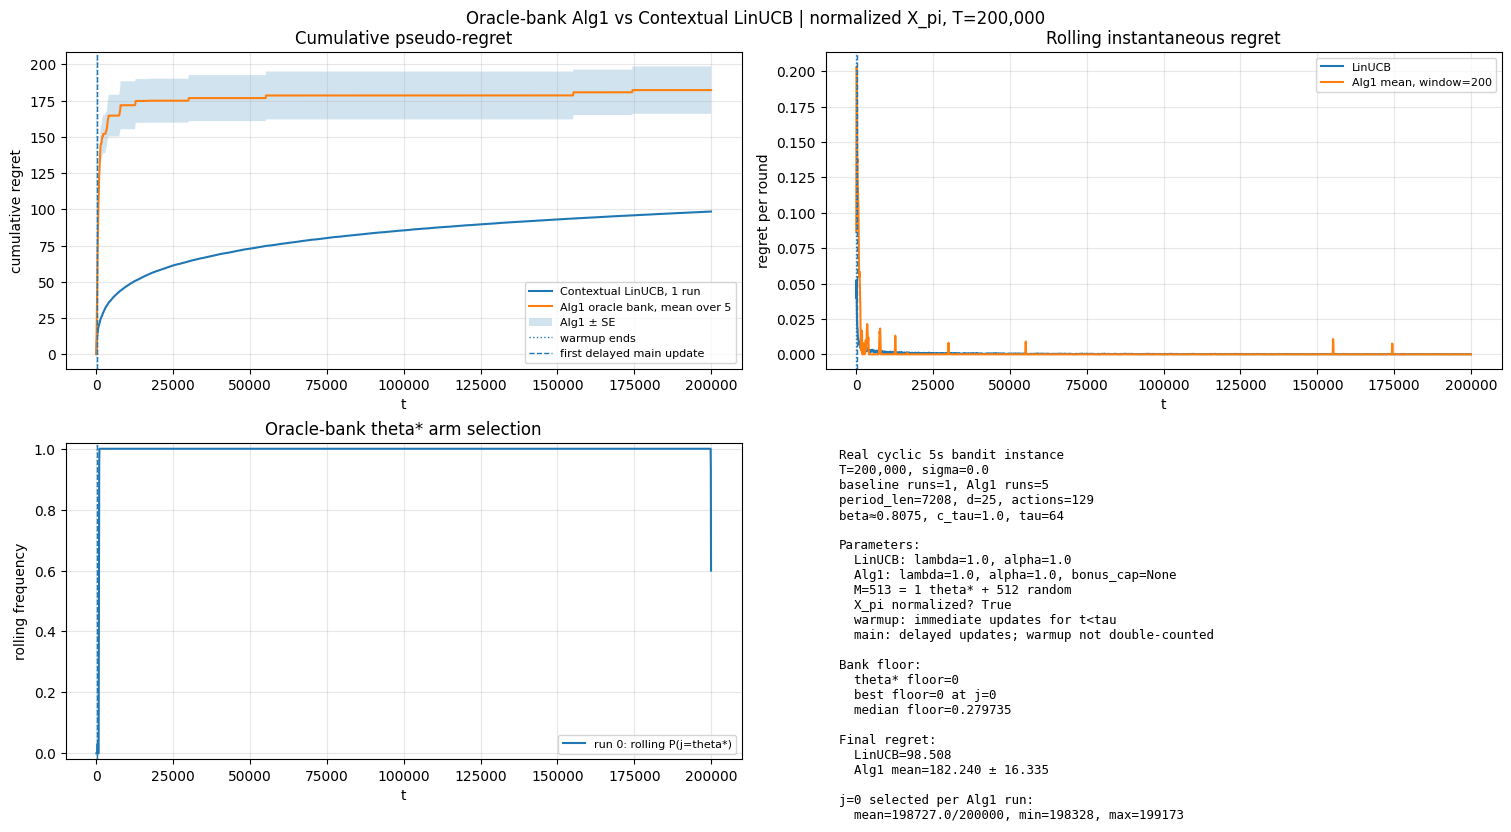

[info] Saved plot: result/real_cyclic5s_T200000_baseline1_alg15_oracleOnly_normXpi.png


In [13]:
import os
import math
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ============================================================
# Config
# ============================================================

inst = instance_to_use  # cyclic_instance_5s

T = min(200_000, inst.num_times)
d = inst.feature_dim

SIGMA = 0.0

N_BASELINE_RUNS = 1
N_ALG1_RUNS = 5

ALG_SEED0 = 0
BANK_SEED = 123

M_RANDOM = 512
THETA_BATCH = 16

beta_hat = inst.meta["beta_estimation"]["beta_hat_used"]
c_tau = 1.0
tau = int(math.ceil(c_tau * math.log(T) / max(1e-12, 1.0 - beta_hat)))

lam_base = 1.0
alpha_base = 1.0

lam_alg1 = 1.0
alpha_alg1 = 1.0
bonus_cap = None

RANDOM_TIE_BREAK = True
NORMALIZE_XPI = True

period_len = int(inst.meta["period_len"])
X_period = np.stack([np.asarray(X, dtype=np.float64) for X in inst.X_by_t[:period_len]], axis=0)
theta_star = np.asarray(inst.theta_star, dtype=np.float64)

R_period = np.einsum("tkd,d->tk", X_period, theta_star, optimize=True)
best_R_period = R_period.max(axis=1)

print(f"[info] T={T}, d={d}, period_len={period_len}")
print(f"[info] beta_hat={beta_hat:.6f}, c_tau={c_tau}, tau={tau}")
print(f"[info] reward range: min={R_period.min():.4f}, max={R_period.max():.4f}, mean={R_period.mean():.4f}")
print(f"[info] theta_star norm={np.linalg.norm(theta_star):.4f}")

os.makedirs("results_csv", exist_ok=True)
os.makedirs("result", exist_ok=True)

try:
    cache_dir = Path(REPO_ROOT) / "results" / "cache"
except NameError:
    cache_dir = Path("results") / "cache"

cache_dir.mkdir(parents=True, exist_ok=True)

theta_checksum = int(abs(np.sum(np.round(theta_star, 8)) * 1e8)) % 10_000_000
cache_path = cache_dir / (
    f"oracle_bank_normXpi_Mrandom{M_RANDOM}_seed{BANK_SEED}_"
    f"period{period_len}_d{d}_theta{theta_checksum}.npz"
)

print(f"[cache] {cache_path}")


# ============================================================
# Helpers
# ============================================================

def normalize_vec(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return v / max(np.linalg.norm(v), eps)


def normalize_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=np.float64)
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)


def unit_vecs(rng, n, d):
    X = rng.normal(size=(n, d))
    return normalize_rows(X)


def sherman_morrison(Vinv, x):
    x = np.asarray(x, dtype=np.float64).reshape(-1, 1)
    Vx = Vinv @ x
    denom = float(1.0 + x.T @ Vx)
    return Vinv - (Vx @ Vx.T) / max(1e-12, denom)


def argmax_with_random_tie(scores, rng, tol=1e-12):
    scores = np.asarray(scores, dtype=np.float64)
    mx = np.max(scores)
    candidates = np.flatnonzero(scores >= mx - tol)
    return int(rng.choice(candidates))


def rolling_mean(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="same")


class LinUCBContextual:
    def __init__(self, d, lam=1.0, alpha=1.0, rng=None, random_tie_break=True):
        self.Vinv = np.eye(d) / lam
        self.b = np.zeros(d)
        self.alpha = float(alpha)
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.random_tie_break = random_tie_break

    def select_index(self, X_t):
        theta_hat = self.Vinv @ self.b
        means = X_t @ theta_hat
        quad = np.einsum("ij,jk,ik->i", X_t, self.Vinv, X_t, optimize=True)
        scores = means + self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.random_tie_break:
            return argmax_with_random_tie(scores, self.rng)
        return int(np.argmax(scores))

    def update(self, x, r):
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += np.asarray(x, dtype=np.float64) * float(r)


class LinUCBOverFixedSet:
    def __init__(self, X, lam=1.0, alpha=1.0, bonus_cap=None, rng=None, random_tie_break=True):
        self.X = np.asarray(X, dtype=np.float64)
        self.Vinv = np.eye(self.X.shape[1]) / lam
        self.b = np.zeros(self.X.shape[1])
        self.alpha = float(alpha)
        self.bonus_cap = bonus_cap
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.random_tie_break = random_tie_break

    def score_all(self):
        theta_hat = self.Vinv @ self.b
        means = self.X @ theta_hat
        quad = np.einsum("ij,jk,ik->i", self.X, self.Vinv, self.X, optimize=True)
        bonus = self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.bonus_cap is not None:
            bonus = np.minimum(bonus, float(self.bonus_cap))

        return means + bonus, means, bonus

    def select_index(self):
        scores, _, _ = self.score_all()

        if self.random_tie_break:
            return argmax_with_random_tie(scores, self.rng)
        return int(np.argmax(scores))

    def update(self, x, r):
        x = np.asarray(x, dtype=np.float64).reshape(-1)
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += x * float(r)


def build_empirical_g_pi_bank(X_period, theta_bank, batch_size=16, normalize_Xpi=True):
    """
    X_pi[j] = empirical E_{A~pi}[argmax_a <a, theta_j>].
    If normalize_Xpi=True, row-normalize X_pi, matching the synthetic implementation.
    """
    X_period = np.asarray(X_period, dtype=np.float64)
    theta_bank = np.asarray(theta_bank, dtype=np.float64)

    N, K, d = X_period.shape
    M = theta_bank.shape[0]
    X_pi_raw = np.zeros((M, d), dtype=np.float64)

    for start in tqdm(range(0, M, batch_size), desc="Building X_pi"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)
        selected = X_period[np.arange(N)[:, None], idx]
        X_pi_raw[start:end] = selected.mean(axis=0)

    if normalize_Xpi:
        return normalize_rows(X_pi_raw), X_pi_raw

    return X_pi_raw, X_pi_raw


def bank_floor_regret(X_period, R_period, best_R_period, theta_bank, batch_size=16):
    """
    fixed_theta_avg_regret[j] =
        E_t[max_i r_t(i) - r_t(argmax_i <X_t[i], theta_j>)].
    """
    M = theta_bank.shape[0]
    avg_regrets = np.zeros(M)

    for start in tqdm(range(0, M, batch_size), desc="Bank floor"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)

        chosen_rewards = np.take_along_axis(
            R_period[:, :, None],
            idx[:, None, :],
            axis=1,
        )[:, 0, :]

        avg_regrets[start:end] = (best_R_period[:, None] - chosen_rewards).mean(axis=0)

    return avg_regrets


# ============================================================
# Cached oracle bank: theta_star direction + random directions
# ============================================================

def build_or_load_oracle_bank_cache():
    if cache_path.exists():
        print("[cache] loading oracle bank / X_pi / bank_floor")
        data = np.load(cache_path, allow_pickle=True)

        theta_bank = data["theta_bank"]
        X_pi = data["X_pi"]
        X_pi_raw = data["X_pi_raw"]
        bank_floor = data["bank_floor"]
        cos_to_star = data["cos_to_star"]

        return theta_bank, X_pi, X_pi_raw, bank_floor, cos_to_star

    print("[cache] not found; building oracle bank")

    rng_bank = np.random.default_rng(BANK_SEED)

    theta_star_dir = normalize_vec(theta_star)
    theta_random = unit_vecs(rng_bank, M_RANDOM, d)
    theta_bank = np.vstack([theta_star_dir[None, :], theta_random])

    cos_to_star = theta_bank @ theta_star_dir

    X_pi, X_pi_raw = build_empirical_g_pi_bank(
        X_period,
        theta_bank,
        batch_size=THETA_BATCH,
        normalize_Xpi=NORMALIZE_XPI,
    )

    bank_floor = bank_floor_regret(
        X_period,
        R_period,
        best_R_period,
        theta_bank,
        batch_size=THETA_BATCH,
    )

    np.savez_compressed(
        cache_path,
        theta_bank=theta_bank,
        X_pi=X_pi,
        X_pi_raw=X_pi_raw,
        bank_floor=bank_floor,
        cos_to_star=cos_to_star,
        M_RANDOM=np.array(M_RANDOM),
        BANK_SEED=np.array(BANK_SEED),
        period_len=np.array(period_len),
        d=np.array(d),
        normalize_Xpi=np.array(NORMALIZE_XPI),
        theta_checksum=np.array(theta_checksum),
    )

    print(f"[cache] saved to {cache_path}")
    return theta_bank, X_pi, X_pi_raw, bank_floor, cos_to_star


theta_bank_oracle, X_pi_oracle, X_pi_oracle_raw, bank_floor_oracle, cos_oracle = build_or_load_oracle_bank_cache()

M = len(theta_bank_oracle)
X_pi_raw_norms = np.linalg.norm(X_pi_oracle_raw, axis=1)
X_pi_norms = np.linalg.norm(X_pi_oracle, axis=1)

bank_diag_df = pd.DataFrame({
    "j": np.arange(M),
    "cos_to_theta_star": cos_oracle,
    "Xpi_norm": X_pi_norms,
    "Xpi_raw_norm": X_pi_raw_norms,
    "fixed_theta_avg_regret": bank_floor_oracle,
}).sort_values("fixed_theta_avg_regret")

display(bank_diag_df.head(15).round(6))

print(f"[bank] oracle bank shape: {theta_bank_oracle.shape}")
print(f"[bank] max cosine with theta_star: {cos_oracle.max():.6f}, index={int(np.argmax(cos_oracle))}")
print(f"[bank] theta_star arm floor regret j=0: {bank_floor_oracle[0]:.8f}")
print(f"[bank] best bank floor regret: {bank_floor_oracle.min():.8f} at j={int(bank_floor_oracle.argmin())}")
print(f"[bank] median bank floor regret: {np.median(bank_floor_oracle):.6f}")


# ============================================================
# Algorithms
# ============================================================

def run_contextual_linucb(seed):
    rng = np.random.default_rng(seed)

    lin = LinUCBContextual(
        d,
        lam=lam_base,
        alpha=alpha_base,
        rng=np.random.default_rng(seed + 10),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    cum_regret = np.zeros(T, dtype=np.float64)
    inst_regret = np.zeros(T, dtype=np.float64)

    c = 0.0

    for t in tqdm(range(T), desc=f"Contextual LinUCB seed={seed}", leave=False):
        p = t % period_len

        X_t = X_period[p]
        mu_t = R_period[p]
        best_mu = best_R_period[p]

        i = lin.select_index(X_t)
        r_obs = float(mu_t[i] + rng.normal(0.0, SIGMA))
        lin.update(X_t[i], r_obs)

        reg = float(best_mu - mu_t[i])
        c += reg

        inst_regret[t] = reg
        cum_regret[t] = c

    return cum_regret, inst_regret


def run_alg1_oracle_bank(seed):
    rng = np.random.default_rng(seed)

    alg1 = LinUCBOverFixedSet(
        X_pi_oracle,
        lam=lam_alg1,
        alpha=alpha_alg1,
        bonus_cap=bonus_cap,
        rng=np.random.default_rng(seed + 20),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    delay_len = max(1, tau + 1)
    xbuf = np.zeros((delay_len, d))
    rbuf = np.zeros(delay_len)
    filled_main_sample = np.zeros(delay_len, dtype=bool)

    cum_regret = np.zeros(T, dtype=np.float64)
    inst_regret = np.zeros(T, dtype=np.float64)
    chosen_j = np.zeros(T, dtype=int)

    c = 0.0

    for t in tqdm(range(T), desc=f"Alg1 oracle bank seed={seed}", leave=False):
        p = t % period_len

        X_t = X_period[p]
        mu_t = R_period[p]
        best_mu = best_R_period[p]

        j = alg1.select_index()

        th = theta_bank_oracle[j]
        x_proxy = X_pi_oracle[j]

        i = int(np.argmax(X_t @ th))
        r_obs = float(mu_t[i] + rng.normal(0.0, SIGMA))

        if t < tau:
            # Immediate warmup update. Not inserted into delayed main buffer.
            alg1.update(x_proxy, r_obs)
        else:
            # Main phase: delayed updates only from main-phase samples.
            slot = t % delay_len
            xbuf[slot] = x_proxy
            rbuf[slot] = r_obs
            filled_main_sample[slot] = True

            old_t = t - tau
            old_slot = old_t % delay_len

            if old_t >= tau and filled_main_sample[old_slot]:
                alg1.update(xbuf[old_slot], rbuf[old_slot])

        reg = float(best_mu - mu_t[i])
        c += reg

        inst_regret[t] = reg
        cum_regret[t] = c
        chosen_j[t] = j

    return cum_regret, inst_regret, chosen_j


# ============================================================
# Run baseline once, Alg1 five times
# ============================================================

print("\n[run] baseline LinUCB once")
baseline_cum, baseline_inst = run_contextual_linucb(ALG_SEED0)

print(f"\n[run] Alg1 oracle bank {N_ALG1_RUNS} runs")
alg1_cum_mat = np.zeros((N_ALG1_RUNS, T), dtype=np.float64)
alg1_inst_mat = np.zeros((N_ALG1_RUNS, T), dtype=np.float64)
alg1_chosen = []

for run in range(N_ALG1_RUNS):
    seed = ALG_SEED0 + run
    cum, inst_reg, chosen_j = run_alg1_oracle_bank(seed)

    alg1_cum_mat[run] = cum
    alg1_inst_mat[run] = inst_reg
    alg1_chosen.append(chosen_j)

mean_alg1 = alg1_cum_mat.mean(axis=0)
se_alg1 = alg1_cum_mat.std(axis=0, ddof=1) / np.sqrt(N_ALG1_RUNS) if N_ALG1_RUNS > 1 else np.zeros(T)

mean_alg1_inst = alg1_inst_mat.mean(axis=0)
se_alg1_inst = alg1_inst_mat.std(axis=0, ddof=1) / np.sqrt(N_ALG1_RUNS) if N_ALG1_RUNS > 1 else np.zeros(T)

summary_df = pd.DataFrame([
    {
        "method": "Contextual LinUCB",
        "runs": N_BASELINE_RUNS,
        "final_mean": baseline_cum[-1],
        "final_se": 0.0,
        "avg_regret": baseline_cum[-1] / T,
    },
    {
        "method": "Alg1 oracle bank",
        "runs": N_ALG1_RUNS,
        "final_mean": mean_alg1[-1],
        "final_se": se_alg1[-1],
        "avg_regret": mean_alg1[-1] / T,
    },
])

display(summary_df.round(6))


# ============================================================
# Chosen-arm diagnostics
# ============================================================

chosen0 = alg1_chosen[0]

chosen_vals, chosen_counts = np.unique(chosen0, return_counts=True)
selected_diag = pd.DataFrame({
    "j": chosen_vals,
    "count": chosen_counts,
})
selected_diag["freq"] = selected_diag["count"] / T
selected_diag["cos_to_star"] = cos_oracle[selected_diag["j"].to_numpy()]
selected_diag["bank_floor"] = bank_floor_oracle[selected_diag["j"].to_numpy()]
selected_diag["Xpi_raw_norm"] = X_pi_raw_norms[selected_diag["j"].to_numpy()]
selected_diag = selected_diag.sort_values("count", ascending=False)

display(selected_diag.head(20).round(6))

j0_counts = [int(np.sum(ch == 0)) for ch in alg1_chosen]
j0_warm_counts = [int(np.sum(ch[:tau] == 0)) for ch in alg1_chosen]
j0_main_counts = [int(np.sum(ch[tau:] == 0)) for ch in alg1_chosen]

j0_diag_df = pd.DataFrame({
    "run": np.arange(N_ALG1_RUNS),
    "j0_total": j0_counts,
    "j0_warmup": j0_warm_counts,
    "j0_main": j0_main_counts,
    "j0_freq": np.asarray(j0_counts) / T,
})

display(j0_diag_df)


# ============================================================
# Save results
# ============================================================

traj_path = f"results_csv/real_cyclic5s_T{T}_baseline1_alg1{N_ALG1_RUNS}_oracleOnly_normXpi.csv"
summary_path = f"results_csv/real_cyclic5s_summary_T{T}_baseline1_alg1{N_ALG1_RUNS}_oracleOnly_normXpi.csv"

df_traj = pd.DataFrame({
    "t": np.arange(1, T + 1),
    "cum_regret_linucb_baseline": baseline_cum,
    "cum_regret_alg1_oracle_mean": mean_alg1,
    "cum_regret_alg1_oracle_se": se_alg1,
})

df_traj.to_csv(traj_path, index=False)
summary_df.to_csv(summary_path, index=False)

print(f"[info] Saved trajectories: {traj_path}")
print(f"[info] Saved summary: {summary_path}")


# ============================================================
# Plot
# ============================================================

plot_step = max(1, T // 3000)
idx = np.arange(0, T, plot_step)
t_axis = idx + 1

w = max(100, T // 1000)

baseline_roll = rolling_mean(baseline_inst, w)
alg1_roll = rolling_mean(mean_alg1_inst, w)

star_selected_roll = rolling_mean((chosen0 == 0).astype(float), w)

fig, axes = plt.subplots(2, 2, figsize=(15, 8), constrained_layout=True)

# Top-left: cumulative regret
ax = axes[0, 0]
ax.plot(t_axis, baseline_cum[idx], label="Contextual LinUCB, 1 run")
ax.plot(t_axis, mean_alg1[idx], label=f"Alg1 oracle bank, mean over {N_ALG1_RUNS}")
ax.fill_between(
    t_axis,
    np.maximum(0.0, mean_alg1[idx] - se_alg1[idx]),
    mean_alg1[idx] + se_alg1[idx],
    alpha=0.2,
    label="Alg1 ± SE",
)
ax.axvline(tau, linestyle=":", linewidth=1, label="warmup ends")
ax.axvline(2 * tau, linestyle="--", linewidth=1, label="first delayed main update")
ax.set_title("Cumulative pseudo-regret")
ax.set_xlabel("t")
ax.set_ylabel("cumulative regret")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Top-right: rolling instantaneous regret
ax = axes[0, 1]
ax.plot(t_axis, baseline_roll[idx], label="LinUCB")
ax.plot(t_axis, alg1_roll[idx], label=f"Alg1 mean, window={w}")
ax.axvline(tau, linestyle=":", linewidth=1)
ax.axvline(2 * tau, linestyle="--", linewidth=1)
ax.set_title("Rolling instantaneous regret")
ax.set_xlabel("t")
ax.set_ylabel("regret per round")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Bottom-left: j=0 selection frequency for first Alg1 run
ax = axes[1, 0]
ax.plot(t_axis, star_selected_roll[idx], label="run 0: rolling P(j=theta*)")
ax.axvline(tau, linestyle=":", linewidth=1)
ax.axvline(2 * tau, linestyle="--", linewidth=1)
ax.set_ylim(-0.02, 1.02)
ax.set_title("Oracle-bank theta* arm selection")
ax.set_xlabel("t")
ax.set_ylabel("rolling frequency")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Bottom-right: text card
ax = axes[1, 1]
ax.axis("off")
text = (
    f"Real cyclic 5s bandit instance\n"
    f"T={T:,}, sigma={SIGMA}\n"
    f"baseline runs={N_BASELINE_RUNS}, Alg1 runs={N_ALG1_RUNS}\n"
    f"period_len={period_len}, d={d}, actions=129\n"
    f"beta≈{beta_hat:.4f}, c_tau={c_tau}, tau={tau}\n\n"
    f"Parameters:\n"
    f"  LinUCB: lambda={lam_base}, alpha={alpha_base}\n"
    f"  Alg1: lambda={lam_alg1}, alpha={alpha_alg1}, bonus_cap={bonus_cap}\n"
    f"  M={M} = 1 theta* + {M_RANDOM} random\n"
    f"  X_pi normalized? {NORMALIZE_XPI}\n"
    f"  warmup: immediate updates for t<tau\n"
    f"  main: delayed updates; warmup not double-counted\n\n"
    f"Bank floor:\n"
    f"  theta* floor={bank_floor_oracle[0]:.6g}\n"
    f"  best floor={bank_floor_oracle.min():.6g} at j={int(bank_floor_oracle.argmin())}\n"
    f"  median floor={np.median(bank_floor_oracle):.6g}\n\n"
    f"Final regret:\n"
    f"  LinUCB={baseline_cum[-1]:.3f}\n"
    f"  Alg1 mean={mean_alg1[-1]:.3f} ± {se_alg1[-1]:.3f}\n\n"
    f"j=0 selected per Alg1 run:\n"
    f"  mean={np.mean(j0_counts):.1f}/{T}, min={np.min(j0_counts)}, max={np.max(j0_counts)}"
)
ax.text(0.02, 0.98, text, va="top", ha="left", family="monospace", fontsize=9)

fig.suptitle(
    f"Oracle-bank Alg1 vs Contextual LinUCB | normalized X_pi, T={T:,}",
    y=1.02,
)

plot_path = f"result/real_cyclic5s_T{T}_baseline1_alg1{N_ALG1_RUNS}_oracleOnly_normXpi.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[info] Saved plot: {plot_path}")

[info] T=200000, d=25, period_len=7208
[info] beta_hat=0.807548, c_tau=1.0, tau=64
[info] reward range: min=0.0987, max=1.0369, mean=0.4916
[info] theta_star norm=1.2993
[cache] d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\cache\oracle_bank_normXpi_Mrandom512_seed123_period7208_d25_theta4538309.npz
[cache] loading oracle bank / X_pi / bank_floor


,j,cos_to_theta_star,Xpi_norm,Xpi_raw_norm,fixed_theta_avg_regret
0,0,1.000000,1.0,1.610606,0.000000
496,496,0.191692,1.0,1.872652,0.089893
488,488,0.374491,1.0,1.683908,0.091123
61,61,0.596574,1.0,1.546773,0.096759
372,372,0.020167,1.0,1.655507,0.098755
105,105,0.366372,1.0,1.727595,0.103365
378,378,0.079691,1.0,1.875725,0.104216
131,131,0.451016,1.0,1.867981,0.111349
382,382,0.025279,1.0,1.850433,0.114623
71,71,0.099224,1.0,1.740202,0.114914


[bank] oracle bank shape: (513, 25)
[bank] max cosine with theta_star: 1.000000, index=0
[bank] theta_star arm floor regret j=0: 0.00000000
[bank] best bank floor regret: 0.00000000 at j=0
[bank] median bank floor regret: 0.279735

[run] baseline LinUCB once


Contextual LinUCB seed=0:   0%|          | 0/200000 [00:00<?, ?it/s]

C:\Users\kaanb\AppData\Local\Temp\ipykernel_37196\2526954415.py:99: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  denom = float(1.0 + x.T @ Vx)


...

Alg1 oracle bank seed=4:   0%|          | 0/200000 [00:00<?, ?it/s]

,method,runs,final_mean,final_se,avg_regret
0,Contextual LinUCB,1,519.989977,0.00000,0.002600
1,Alg1 oracle bank,5,400.492562,26.51838,0.002002


,j,count,freq,cos_to_star,bank_floor,Xpi_raw_norm
0,0,198132,0.990660,1.000000,0.000000,1.610606
2,6,301,0.001505,0.169143,0.161990,1.637363
58,505,170,0.000850,-0.195569,0.180813,1.620825
53,488,151,0.000755,0.374491,0.091123,1.683908
56,496,147,0.000735,0.191692,0.089893,1.872652
9,61,145,0.000725,0.596574,0.096759,1.546773
33,295,89,0.000445,0.398104,0.165964,1.525601
18,143,85,0.000425,-0.144184,0.236266,1.909484
16,131,66,0.000330,0.451016,0.111349,1.867981
14,117,65,0.000325,-0.020001,0.477598,1.574029


,run,j0_total,j0_warmup,j0_main,j0_freq
0,0,198132,0,198132,0.990660
1,1,197075,0,197075,0.985375
2,2,197222,0,197222,0.986110
3,3,196579,0,196579,0.982895
4,4,197545,0,197545,0.987725


[info] Saved trajectories: results_csv/real_cyclic5s_T200000_baseline1_alg15_oracleOnly_normXpi.csv
[info] Saved summary: results_csv/real_cyclic5s_summary_T200000_baseline1_alg15_oracleOnly_normXpi.csv


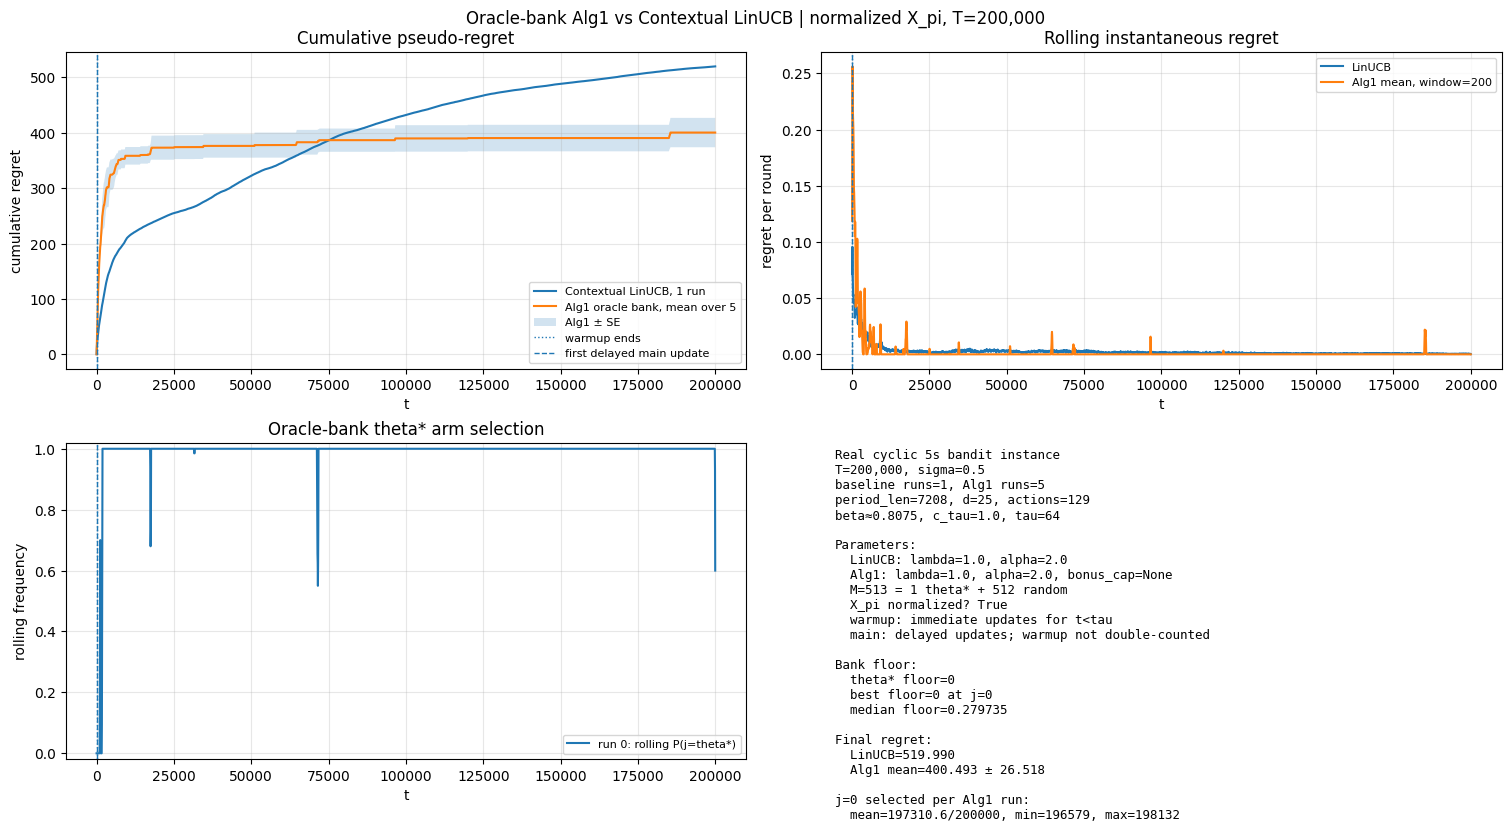

[info] Saved plot: result/real_cyclic5s_T200000_baseline1_alg15_oracleOnly_normXpi.png


In [ ]:
import os
import math
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ============================================================
# Config
# ============================================================

inst = instance_to_use  # cyclic_instance_5s

T = min(200_000, inst.num_times)
d = inst.feature_dim

SIGMA = 0.5

N_BASELINE_RUNS = 5
N_ALG1_RUNS = 5

ALG_SEED0 = 0
BANK_SEED = 123

M_RANDOM = 512
THETA_BATCH = 16

beta_hat = inst.meta["beta_estimation"]["beta_hat_used"]
c_tau = 1.0
tau = int(math.ceil(c_tau * math.log(T) / max(1e-12, 1.0 - beta_hat)))

lam_base = 1.0
alpha_base = 2.0

lam_alg1 = 1.0
alpha_alg1 = 2.0
bonus_cap = None

RANDOM_TIE_BREAK = True
NORMALIZE_XPI = True

period_len = int(inst.meta["period_len"])
X_period = np.stack([np.asarray(X, dtype=np.float64) for X in inst.X_by_t[:period_len]], axis=0)
theta_star = np.asarray(inst.theta_star, dtype=np.float64)

R_period = np.einsum("tkd,d->tk", X_period, theta_star, optimize=True)
best_R_period = R_period.max(axis=1)

print(f"[info] T={T}, d={d}, period_len={period_len}")
print(f"[info] beta_hat={beta_hat:.6f}, c_tau={c_tau}, tau={tau}")
print(f"[info] reward range: min={R_period.min():.4f}, max={R_period.max():.4f}, mean={R_period.mean():.4f}")
print(f"[info] theta_star norm={np.linalg.norm(theta_star):.4f}")

os.makedirs("results_csv", exist_ok=True)
os.makedirs("result", exist_ok=True)

try:
    cache_dir = Path(REPO_ROOT) / "results" / "cache"
except NameError:
    cache_dir = Path("results") / "cache"

cache_dir.mkdir(parents=True, exist_ok=True)

theta_checksum = int(abs(np.sum(np.round(theta_star, 8)) * 1e8)) % 10_000_000
cache_path = cache_dir / (
    f"oracle_bank_normXpi_Mrandom{M_RANDOM}_seed{BANK_SEED}_"
    f"period{period_len}_d{d}_theta{theta_checksum}.npz"
)

print(f"[cache] {cache_path}")


# ============================================================
# Helpers
# ============================================================

def normalize_vec(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return v / max(np.linalg.norm(v), eps)


def normalize_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=np.float64)
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)


def unit_vecs(rng, n, d):
    X = rng.normal(size=(n, d))
    return normalize_rows(X)


def sherman_morrison(Vinv, x):
    x = np.asarray(x, dtype=np.float64).reshape(-1, 1)
    Vx = Vinv @ x
    denom = float(1.0 + x.T @ Vx)
    return Vinv - (Vx @ Vx.T) / max(1e-12, denom)


def argmax_with_random_tie(scores, rng, tol=1e-12):
    scores = np.asarray(scores, dtype=np.float64)
    mx = np.max(scores)
    candidates = np.flatnonzero(scores >= mx - tol)
    return int(rng.choice(candidates))


def rolling_mean(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="same")


class LinUCBContextual:
    def __init__(self, d, lam=1.0, alpha=1.0, rng=None, random_tie_break=True):
        self.Vinv = np.eye(d) / lam
        self.b = np.zeros(d)
        self.alpha = float(alpha)
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.random_tie_break = random_tie_break

    def select_index(self, X_t):
        theta_hat = self.Vinv @ self.b
        means = X_t @ theta_hat
        quad = np.einsum("ij,jk,ik->i", X_t, self.Vinv, X_t, optimize=True)
        scores = means + self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.random_tie_break:
            return argmax_with_random_tie(scores, self.rng)
        return int(np.argmax(scores))

    def update(self, x, r):
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += np.asarray(x, dtype=np.float64) * float(r)


class LinUCBOverFixedSet:
    def __init__(self, X, lam=1.0, alpha=1.0, bonus_cap=None, rng=None, random_tie_break=True):
        self.X = np.asarray(X, dtype=np.float64)
        self.Vinv = np.eye(self.X.shape[1]) / lam
        self.b = np.zeros(self.X.shape[1])
        self.alpha = float(alpha)
        self.bonus_cap = bonus_cap
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.random_tie_break = random_tie_break

    def score_all(self):
        theta_hat = self.Vinv @ self.b
        means = self.X @ theta_hat
        quad = np.einsum("ij,jk,ik->i", self.X, self.Vinv, self.X, optimize=True)
        bonus = self.alpha * np.sqrt(np.maximum(0.0, quad))

        if self.bonus_cap is not None:
            bonus = np.minimum(bonus, float(self.bonus_cap))

        return means + bonus, means, bonus

    def select_index(self):
        scores, _, _ = self.score_all()

        if self.random_tie_break:
            return argmax_with_random_tie(scores, self.rng)
        return int(np.argmax(scores))

    def update(self, x, r):
        x = np.asarray(x, dtype=np.float64).reshape(-1)
        self.Vinv = sherman_morrison(self.Vinv, x)
        self.b += x * float(r)


def build_empirical_g_pi_bank(X_period, theta_bank, batch_size=16, normalize_Xpi=True):
    """
    X_pi[j] = empirical E_{A~pi}[argmax_a <a, theta_j>].
    If normalize_Xpi=True, row-normalize X_pi, matching the synthetic implementation.
    """
    X_period = np.asarray(X_period, dtype=np.float64)
    theta_bank = np.asarray(theta_bank, dtype=np.float64)

    N, K, d = X_period.shape
    M = theta_bank.shape[0]
    X_pi_raw = np.zeros((M, d), dtype=np.float64)

    for start in tqdm(range(0, M, batch_size), desc="Building X_pi"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)
        selected = X_period[np.arange(N)[:, None], idx]
        X_pi_raw[start:end] = selected.mean(axis=0)

    if normalize_Xpi:
        return normalize_rows(X_pi_raw), X_pi_raw

    return X_pi_raw, X_pi_raw


def bank_floor_regret(X_period, R_period, best_R_period, theta_bank, batch_size=16):
    """
    fixed_theta_avg_regret[j] =
        E_t[max_i r_t(i) - r_t(argmax_i <X_t[i], theta_j>)].
    """
    M = theta_bank.shape[0]
    avg_regrets = np.zeros(M)

    for start in tqdm(range(0, M, batch_size), desc="Bank floor"):
        end = min(M, start + batch_size)
        TH = theta_bank[start:end]

        scores = np.einsum("tkd,bd->tkb", X_period, TH, optimize=True)
        idx = np.argmax(scores, axis=1)

        chosen_rewards = np.take_along_axis(
            R_period[:, :, None],
            idx[:, None, :],
            axis=1,
        )[:, 0, :]

        avg_regrets[start:end] = (best_R_period[:, None] - chosen_rewards).mean(axis=0)

    return avg_regrets


# ============================================================
# Cached oracle bank: theta_star direction + random directions
# ============================================================

def build_or_load_oracle_bank_cache():
    if cache_path.exists():
        print("[cache] loading oracle bank / X_pi / bank_floor")
        data = np.load(cache_path, allow_pickle=True)

        theta_bank = data["theta_bank"]
        X_pi = data["X_pi"]
        X_pi_raw = data["X_pi_raw"]
        bank_floor = data["bank_floor"]
        cos_to_star = data["cos_to_star"]

        return theta_bank, X_pi, X_pi_raw, bank_floor, cos_to_star

    print("[cache] not found; building oracle bank")

    rng_bank = np.random.default_rng(BANK_SEED)

    theta_star_dir = normalize_vec(theta_star)
    theta_random = unit_vecs(rng_bank, M_RANDOM, d)
    theta_bank = np.vstack([theta_star_dir[None, :], theta_random])

    cos_to_star = theta_bank @ theta_star_dir

    X_pi, X_pi_raw = build_empirical_g_pi_bank(
        X_period,
        theta_bank,
        batch_size=THETA_BATCH,
        normalize_Xpi=NORMALIZE_XPI,
    )

    bank_floor = bank_floor_regret(
        X_period,
        R_period,
        best_R_period,
        theta_bank,
        batch_size=THETA_BATCH,
    )

    np.savez_compressed(
        cache_path,
        theta_bank=theta_bank,
        X_pi=X_pi,
        X_pi_raw=X_pi_raw,
        bank_floor=bank_floor,
        cos_to_star=cos_to_star,
        M_RANDOM=np.array(M_RANDOM),
        BANK_SEED=np.array(BANK_SEED),
        period_len=np.array(period_len),
        d=np.array(d),
        normalize_Xpi=np.array(NORMALIZE_XPI),
        theta_checksum=np.array(theta_checksum),
    )

    print(f"[cache] saved to {cache_path}")
    return theta_bank, X_pi, X_pi_raw, bank_floor, cos_to_star


theta_bank_oracle, X_pi_oracle, X_pi_oracle_raw, bank_floor_oracle, cos_oracle = build_or_load_oracle_bank_cache()

M = len(theta_bank_oracle)
X_pi_raw_norms = np.linalg.norm(X_pi_oracle_raw, axis=1)
X_pi_norms = np.linalg.norm(X_pi_oracle, axis=1)

bank_diag_df = pd.DataFrame({
    "j": np.arange(M),
    "cos_to_theta_star": cos_oracle,
    "Xpi_norm": X_pi_norms,
    "Xpi_raw_norm": X_pi_raw_norms,
    "fixed_theta_avg_regret": bank_floor_oracle,
}).sort_values("fixed_theta_avg_regret")

display(bank_diag_df.head(15).round(6))

print(f"[bank] oracle bank shape: {theta_bank_oracle.shape}")
print(f"[bank] max cosine with theta_star: {cos_oracle.max():.6f}, index={int(np.argmax(cos_oracle))}")
print(f"[bank] theta_star arm floor regret j=0: {bank_floor_oracle[0]:.8f}")
print(f"[bank] best bank floor regret: {bank_floor_oracle.min():.8f} at j={int(bank_floor_oracle.argmin())}")
print(f"[bank] median bank floor regret: {np.median(bank_floor_oracle):.6f}")


# ============================================================
# Algorithms
# ============================================================

def run_contextual_linucb(seed):
    rng = np.random.default_rng(seed)

    lin = LinUCBContextual(
        d,
        lam=lam_base,
        alpha=alpha_base,
        rng=np.random.default_rng(seed + 10),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    cum_regret = np.zeros(T, dtype=np.float64)
    inst_regret = np.zeros(T, dtype=np.float64)

    c = 0.0

    for t in tqdm(range(T), desc=f"Contextual LinUCB seed={seed}", leave=False):
        p = t % period_len

        X_t = X_period[p]
        mu_t = R_period[p]
        best_mu = best_R_period[p]

        i = lin.select_index(X_t)
        r_obs = float(mu_t[i] + rng.normal(0.0, SIGMA))
        lin.update(X_t[i], r_obs)

        reg = float(best_mu - mu_t[i])
        c += reg

        inst_regret[t] = reg
        cum_regret[t] = c

    return cum_regret, inst_regret


def run_alg1_oracle_bank(seed):
    rng = np.random.default_rng(seed)

    alg1 = LinUCBOverFixedSet(
        X_pi_oracle,
        lam=lam_alg1,
        alpha=alpha_alg1,
        bonus_cap=bonus_cap,
        rng=np.random.default_rng(seed + 20),
        random_tie_break=RANDOM_TIE_BREAK,
    )

    delay_len = max(1, tau + 1)
    xbuf = np.zeros((delay_len, d))
    rbuf = np.zeros(delay_len)
    filled_main_sample = np.zeros(delay_len, dtype=bool)

    cum_regret = np.zeros(T, dtype=np.float64)
    inst_regret = np.zeros(T, dtype=np.float64)
    chosen_j = np.zeros(T, dtype=int)

    c = 0.0

    for t in tqdm(range(T), desc=f"Alg1 oracle bank seed={seed}", leave=False):
        p = t % period_len

        X_t = X_period[p]
        mu_t = R_period[p]
        best_mu = best_R_period[p]

        j = alg1.select_index()

        th = theta_bank_oracle[j]
        x_proxy = X_pi_oracle[j]

        i = int(np.argmax(X_t @ th))
        r_obs = float(mu_t[i] + rng.normal(0.0, SIGMA))

        if t < tau:
            # Immediate warmup update. Not inserted into delayed main buffer.
            alg1.update(x_proxy, r_obs)
        else:
            # Main phase: delayed updates only from main-phase samples.
            slot = t % delay_len
            xbuf[slot] = x_proxy
            rbuf[slot] = r_obs
            filled_main_sample[slot] = True

            old_t = t - tau
            old_slot = old_t % delay_len

            if old_t >= tau and filled_main_sample[old_slot]:
                alg1.update(xbuf[old_slot], rbuf[old_slot])

        reg = float(best_mu - mu_t[i])
        c += reg

        inst_regret[t] = reg
        cum_regret[t] = c
        chosen_j[t] = j

    return cum_regret, inst_regret, chosen_j


# ============================================================
# Run baseline once, Alg1 five times
# ============================================================

print("\n[run] baseline LinUCB once")
baseline_cum, baseline_inst = run_contextual_linucb(ALG_SEED0)

print(f"\n[run] Alg1 oracle bank {N_ALG1_RUNS} runs")
alg1_cum_mat = np.zeros((N_ALG1_RUNS, T), dtype=np.float64)
alg1_inst_mat = np.zeros((N_ALG1_RUNS, T), dtype=np.float64)
alg1_chosen = []

for run in range(N_ALG1_RUNS):
    seed = ALG_SEED0 + run
    cum, inst_reg, chosen_j = run_alg1_oracle_bank(seed)

    alg1_cum_mat[run] = cum
    alg1_inst_mat[run] = inst_reg
    alg1_chosen.append(chosen_j)

mean_alg1 = alg1_cum_mat.mean(axis=0)
se_alg1 = alg1_cum_mat.std(axis=0, ddof=1) / np.sqrt(N_ALG1_RUNS) if N_ALG1_RUNS > 1 else np.zeros(T)

mean_alg1_inst = alg1_inst_mat.mean(axis=0)
se_alg1_inst = alg1_inst_mat.std(axis=0, ddof=1) / np.sqrt(N_ALG1_RUNS) if N_ALG1_RUNS > 1 else np.zeros(T)

summary_df = pd.DataFrame([
    {
        "method": "Contextual LinUCB",
        "runs": N_BASELINE_RUNS,
        "final_mean": baseline_cum[-1],
        "final_se": 0.0,
        "avg_regret": baseline_cum[-1] / T,
    },
    {
        "method": "Alg1 oracle bank",
        "runs": N_ALG1_RUNS,
        "final_mean": mean_alg1[-1],
        "final_se": se_alg1[-1],
        "avg_regret": mean_alg1[-1] / T,
    },
])

display(summary_df.round(6))


# ============================================================
# Chosen-arm diagnostics
# ============================================================

chosen0 = alg1_chosen[0]

chosen_vals, chosen_counts = np.unique(chosen0, return_counts=True)
selected_diag = pd.DataFrame({
    "j": chosen_vals,
    "count": chosen_counts,
})
selected_diag["freq"] = selected_diag["count"] / T
selected_diag["cos_to_star"] = cos_oracle[selected_diag["j"].to_numpy()]
selected_diag["bank_floor"] = bank_floor_oracle[selected_diag["j"].to_numpy()]
selected_diag["Xpi_raw_norm"] = X_pi_raw_norms[selected_diag["j"].to_numpy()]
selected_diag = selected_diag.sort_values("count", ascending=False)

display(selected_diag.head(20).round(6))

j0_counts = [int(np.sum(ch == 0)) for ch in alg1_chosen]
j0_warm_counts = [int(np.sum(ch[:tau] == 0)) for ch in alg1_chosen]
j0_main_counts = [int(np.sum(ch[tau:] == 0)) for ch in alg1_chosen]

j0_diag_df = pd.DataFrame({
    "run": np.arange(N_ALG1_RUNS),
    "j0_total": j0_counts,
    "j0_warmup": j0_warm_counts,
    "j0_main": j0_main_counts,
    "j0_freq": np.asarray(j0_counts) / T,
})

display(j0_diag_df)


# ============================================================
# Save results
# ============================================================

traj_path = f"results_csv/real_cyclic5s_T{T}_baseline1_alg1{N_ALG1_RUNS}_oracleOnly_normXpi.csv"
summary_path = f"results_csv/real_cyclic5s_summary_T{T}_baseline1_alg1{N_ALG1_RUNS}_oracleOnly_normXpi.csv"

df_traj = pd.DataFrame({
    "t": np.arange(1, T + 1),
    "cum_regret_linucb_baseline": baseline_cum,
    "cum_regret_alg1_oracle_mean": mean_alg1,
    "cum_regret_alg1_oracle_se": se_alg1,
})

df_traj.to_csv(traj_path, index=False)
summary_df.to_csv(summary_path, index=False)

print(f"[info] Saved trajectories: {traj_path}")
print(f"[info] Saved summary: {summary_path}")


# ============================================================
# Plot
# ============================================================

plot_step = max(1, T // 3000)
idx = np.arange(0, T, plot_step)
t_axis = idx + 1

w = max(100, T // 1000)

baseline_roll = rolling_mean(baseline_inst, w)
alg1_roll = rolling_mean(mean_alg1_inst, w)

star_selected_roll = rolling_mean((chosen0 == 0).astype(float), w)

fig, axes = plt.subplots(2, 2, figsize=(15, 8), constrained_layout=True)

# Top-left: cumulative regret
ax = axes[0, 0]
ax.plot(t_axis, baseline_cum[idx], label="Contextual LinUCB, 1 run")
ax.plot(t_axis, mean_alg1[idx], label=f"Alg1 oracle bank, mean over {N_ALG1_RUNS}")
ax.fill_between(
    t_axis,
    np.maximum(0.0, mean_alg1[idx] - se_alg1[idx]),
    mean_alg1[idx] + se_alg1[idx],
    alpha=0.2,
    label="Alg1 ± SE",
)
ax.axvline(tau, linestyle=":", linewidth=1, label="warmup ends")
ax.axvline(2 * tau, linestyle="--", linewidth=1, label="first delayed main update")
ax.set_title("Cumulative pseudo-regret")
ax.set_xlabel("t")
ax.set_ylabel("cumulative regret")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Top-right: rolling instantaneous regret
ax = axes[0, 1]
ax.plot(t_axis, baseline_roll[idx], label="LinUCB")
ax.plot(t_axis, alg1_roll[idx], label=f"Alg1 mean, window={w}")
ax.axvline(tau, linestyle=":", linewidth=1)
ax.axvline(2 * tau, linestyle="--", linewidth=1)
ax.set_title("Rolling instantaneous regret")
ax.set_xlabel("t")
ax.set_ylabel("regret per round")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Bottom-left: j=0 selection frequency for first Alg1 run
ax = axes[1, 0]
ax.plot(t_axis, star_selected_roll[idx], label="run 0: rolling P(j=theta*)")
ax.axvline(tau, linestyle=":", linewidth=1)
ax.axvline(2 * tau, linestyle="--", linewidth=1)
ax.set_ylim(-0.02, 1.02)
ax.set_title("Oracle-bank theta* arm selection")
ax.set_xlabel("t")
ax.set_ylabel("rolling frequency")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Bottom-right: text card
ax = axes[1, 1]
ax.axis("off")
text = (
    f"Real cyclic 5s bandit instance\n"
    f"T={T:,}, sigma={SIGMA}\n"
    f"baseline runs={N_BASELINE_RUNS}, Alg1 runs={N_ALG1_RUNS}\n"
    f"period_len={period_len}, d={d}, actions=129\n"
    f"beta≈{beta_hat:.4f}, c_tau={c_tau}, tau={tau}\n\n"
    f"Parameters:\n"
    f"  LinUCB: lambda={lam_base}, alpha={alpha_base}\n"
    f"  Alg1: lambda={lam_alg1}, alpha={alpha_alg1}, bonus_cap={bonus_cap}\n"
    f"  M={M} = 1 theta* + {M_RANDOM} random\n"
    f"  X_pi normalized? {NORMALIZE_XPI}\n"
    f"  warmup: immediate updates for t<tau\n"
    f"  main: delayed updates; warmup not double-counted\n\n"
    f"Bank floor:\n"
    f"  theta* floor={bank_floor_oracle[0]:.6g}\n"
    f"  best floor={bank_floor_oracle.min():.6g} at j={int(bank_floor_oracle.argmin())}\n"
    f"  median floor={np.median(bank_floor_oracle):.6g}\n\n"
    f"Final regret:\n"
    f"  LinUCB={baseline_cum[-1]:.3f}\n"
    f"  Alg1 mean={mean_alg1[-1]:.3f} ± {se_alg1[-1]:.3f}\n\n"
    f"j=0 selected per Alg1 run:\n"
    f"  mean={np.mean(j0_counts):.1f}/{T}, min={np.min(j0_counts)}, max={np.max(j0_counts)}"
)
ax.text(0.02, 0.98, text, va="top", ha="left", family="monospace", fontsize=9)

fig.suptitle(
    f"Oracle-bank Alg1 vs Contextual LinUCB | normalized X_pi, T={T:,}",
    y=1.02,
)

plot_path = f"result/real_cyclic5s_T{T}_baseline1_alg1{N_ALG1_RUNS}_oracleOnly_normXpi.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[info] Saved plot: {plot_path}")